In [ ]:
import json
import pandas as pd
from pathlib import Path

# Define CSV file path
csv_file = Path("data/top_25_news_stocks.csv")

# Check if CSV exists and load it
if csv_file.exists():
    top_25_df = pd.read_csv(csv_file)
    print("Loaded top 25 stocks from cache:\n")
else:
    # Generate top 25 stocks by news days from JSONL files
    data_dir = Path("data/text")
    news_days_count = {}

    for jsonl_file in sorted(data_dir.glob("*.jsonl")):
        ticker = jsonl_file.stem
        unique_dates = set()
        
        try:
            with open(jsonl_file, 'r', encoding='utf-8') as f:
                for line in f:
                    try:
                        article = json.loads(line)
                        if 'Date' in article:
                            date_str = article['Date'].split('T')[0]
                            unique_dates.add(date_str)
                    except (json.JSONDecodeError, KeyError):
                        continue
            
            if unique_dates:
                news_days_count[ticker] = len(unique_dates)
        except Exception as e:
            continue

    # Create DataFrame
    top_25 = sorted(news_days_count.items(), key=lambda x: x[1], reverse=True)[:25]
    top_25_df = pd.DataFrame(top_25, columns=['Ticker', 'News_Days'])
    top_25_df['Rank'] = range(1, len(top_25_df) + 1)
    top_25_df = top_25_df[['Rank', 'Ticker', 'News_Days']]
    
    # Save to CSV
    csv_file.parent.mkdir(parents=True, exist_ok=True)
    top_25_df.to_csv(csv_file, index=False)
    print("Calculated and saved top 25 stocks:\n")

print(top_25_df.to_string(index=False))
print(f"\nTotal stocks: {len(top_25_df)}")

Loaded top 25 stocks from cache:

 Rank Ticker  News_Days
    1     GE       3179
    2     KO       3011
    3    GLD       3007
    4  CMCSA       2985
    5      V       2950
    6    USO       2910
    7   COST       2886
    8   GILD       2849
    9    MRK       2756
   10    NKE       2736
   11    QQQ       2719
   12    COP       2689
   13   ABBV       2663
   14    XLF       2611
   15   BABA       2568
   16   AMGN       2521
   17      T       2496
   18    XLE       2476
   19    CRM       2464
   20   ORCL       2403
   21   QCOM       2376
   22    CAT       2375
   23    BHP       2369
   24    GSK       2358
   25    PEP       2351

Total stocks: 25


In [ ]:
import matplotlib.pyplot as plt
import json

# Plot all 25 stocks
all_25_tickers = top_25_df['Ticker'].values

fig, axes = plt.subplots(5, 5, figsize=(25, 20))
axes = axes.flatten()

for idx, ticker in enumerate(all_25_tickers):
    ax = axes[idx]
    
    # Load time series data
    ts_file = Path('data/time_series') / f'{ticker.lower()}.csv'
    if ts_file.exists():
        ts_df = pd.read_csv(ts_file)
        ts_df['Date'] = pd.to_datetime(ts_df['Date'], utc=True).dt.tz_localize(None)
        ts_df = ts_df.sort_values('Date')
        
        # Get news dates directly from JSONL file
        news_file = Path('data/text') / f'{ticker}.jsonl'
        unique_news_dates = set()
        
        if news_file.exists():
            try:
                with open(news_file, 'r', encoding='utf-8') as f:
                    for line in f:
                        try:
                            article = json.loads(line)
                            if 'Date' in article:
                                date_str = article['Date'].split('T')[0]
                                unique_news_dates.add(pd.to_datetime(date_str).date())
                        except (json.JSONDecodeError, KeyError):
                            continue
            except:
                pass
        
        ax.plot(ts_df['Date'], ts_df['Close'], linewidth=1, color='steelblue', label='Close Price')
        
        # Mark dates with news as red dots
        if unique_news_dates:
            ts_with_news = ts_df[ts_df['Date'].dt.date.isin(unique_news_dates)]
            ax.scatter(ts_with_news['Date'], ts_with_news['Close'], color='red', s=20, zorder=5, label='News Day', alpha=0.7)
        
        # Formatting
        ax.set_title(f'{ticker} ({len(unique_news_dates)} days)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Date', fontsize=7)
        ax.set_ylabel('Price', fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', labelsize=6)
        if idx % 5 == 0:
            ax.legend(fontsize=6)
    else:
        ax.text(0.5, 0.5, f'{ticker} data not found', ha='center', va='center', fontsize=10)
        ax.set_title(f'{ticker}')

plt.suptitle('Top 25 Stocks by News Days - Price and News Coverage', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
import os
from openai import OpenAI

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set")

client = OpenAI(api_key=api_key)

top_ticker = top_25_df.iloc[0]['Ticker']
print(f"Processing top ticker: {top_ticker}\n")

news_file = Path('data/text') / f'{top_ticker}.jsonl'

first_article = None
first_date = None

if news_file.exists():
    with open(news_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                article = json.loads(line)
                if 'Date' in article and 'Article' in article:
                    first_article = article['Article']
                    first_date = article['Date']
                    break
            except json.JSONDecodeError:
                continue

if first_article:
    print(f"Date: {first_date}")
    print(f"Article preview: {first_article[:200]}...\n")
    
    prompt = f"""You are a professional equity research analyzer.
Analyze this news for {top_ticker}.
Date: {first_date}
News:
{first_article[:5000]}

Provide 10 concise bullet points focused on {top_ticker}:
- business impact
- near-term catalysts
- risks
- earnings implications
- competitive positioning
- sentiment
- investment takeaway"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=500,
    )
    
    analysis = response.choices[0].message.content
    print("LLM Analysis:\n")
    print(analysis)
else:
    print(f"No articles found for {top_ticker}")

Processing top ticker: GE

Date: 2025-05-05
Article preview: Congress has continued to be busy trading, and we have been tracking all of their latest portfolio movements at Quiver.
Quiver's Congress Buys Strategy is an automated trading strategy that tracks the...

LLM Analysis:

### Analysis of GE Based on Congress Buys Strategy Update

- **Business Impact**: GE's inclusion in the Congress Buys Strategy suggests some level of confidence from lawmakers in the company's future performance, indicative of potential stability or growth.
  
- **Near-Term Catalysts**: The recent uptick in Congress members purchasing GE stocks (2 purchases totaling $51,000) may lead to increased interest from institutional and retail investors in a generally positive market sentiment.

- **Risks**: Limited purchases by Congress members may indicate a lack of widespread confidence or actionable growth within the company, raising questions about sustainability beyond speculative interest.

- **Earnings Implicat

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming daily_emb is already available in the environment
# Example: daily_emb = pd.DataFrame(...)

# 1. Preprocessing
# Identify embedding columns
emb_cols = [c for c in daily_emb.columns if c not in ['date', 'ticker', 'ret_fwd']]
D = len(emb_cols)

# Pivot returns (T x N)
returns_df = daily_emb.pivot(index='date', columns='ticker', values='ret_fwd')
dates = returns_df.index
tickers = returns_df.columns
T = len(dates)
N = len(tickers)

returns = returns_df.values

# Initialize and fill embedding tensor (T, N, D)
emb_tensor = np.full((T, N, D), np.nan)

# Create a mapping for ticker to integer index
ticker_to_idx = {t: i for i, t in enumerate(tickers)}
date_to_idx = {d: i for i, d in enumerate(dates)}

# Fill tensor
grouped = daily_emb.groupby(['date', 'ticker'])[emb_cols].first()
for (d, t), row in grouped.iterrows():
    if d in date_to_idx and t in ticker_to_idx:
        emb_tensor[date_to_idx[d], ticker_to_idx[t], :] = row.values

# Fill missing embeddings with cross-sectional mean per day
for t_idx in range(T):
    day_data = emb_tensor[t_idx]
    mask = np.isnan(day_data).any(axis=1)
    if not mask.all():
        mean_emb = np.nanmean(day_data[~mask], axis=0)
        day_data[mask] = mean_emb
    else:
        day_data[mask] = 0.0

# Normalize embeddings using train set statistics (assume first 70% is train)
train_idx = int(T * 0.7)
train_mean = np.nanmean(emb_tensor[:train_idx], axis=(0, 1))
train_std = np.nanstd(emb_tensor[:train_idx], axis=(0, 1))
train_std[train_std == 0] = 1.0

emb_tensor = (emb_tensor - train_mean) / train_std

# 2. Event detection from embeddings
drift = np.zeros((T, N))
for t_idx in range(1, T):
    diff = emb_tensor[t_idx] - emb_tensor[t_idx-1]
    drift[t_idx] = np.linalg.norm(diff, axis=1)

# Top 5% drift threshold
threshold = np.nanpercentile(drift[drift > 0], 95)
events = (drift > threshold).astype(float)

# 3. Hawkes-style intensity
alpha, beta = 0.5, 0.2
intensity = np.zeros((T, N))
for t_idx in range(1, T):
    intensity[t_idx] = intensity[t_idx-1] * np.exp(-beta) + alpha * events[t_idx]

# Cross-sectional normalization of intensity
for t_idx in range(T):
    row_sum = np.sum(intensity[t_idx])
    if row_sum > 0:
        intensity[t_idx] /= row_sum

# 4. Regime detection (simple)
market_return = np.nanmean(returns, axis=1)
# Rolling volatility (20-day std) using pandas for convenience
mkt_ret_series = pd.Series(market_return)
roll_vol = mkt_ret_series.rolling(20).std().fillna(method='bfill').values

vol_median = np.nanmedian(roll_vol)
regime = (roll_vol > vol_median).astype(float)

# 5. Numerical signal
# Momentum = sign(return[t-1])
momentum = np.zeros((T, N))
momentum[1:] = np.sign(returns[:-1])

# 6. Fusion
alpha_signal = np.zeros((T, N))
for t_idx in range(T):
    alpha_signal[t_idx] = intensity[t_idx] * momentum[t_idx] * regime[t_idx]

# 7. Portfolio construction
weights = alpha_signal.copy()

# Treat NaNs in returns as uninvestable for that day
weights[np.isnan(returns)] = 0.0

# Normalize cross-sectionally: sum(abs(weights)) = 1
for t_idx in range(T):
    row_abs_sum = np.sum(np.abs(weights[t_idx]))
    if row_abs_sum > 0:
        weights[t_idx] /= row_abs_sum

# 8. Backtest
# Returns: weights at t are applied to returns at t
# returns at t is ret_fwd from the perspective of data at t
portfolio_returns = np.zeros(T)
buy_hold_returns = np.zeros(T)

for t_idx in range(T - 1):
    # Strategy
    w = weights[t_idx]
    r = returns[t_idx]
    valid = ~np.isnan(r)
    portfolio_returns[t_idx] = np.sum(w[valid] * r[valid])
    
    # Buy & Hold (Equal weight)
    bh_w = np.ones(N) / N
    buy_hold_returns[t_idx] = np.sum(bh_w[valid] * r[valid])

# 9. Metrics
def calc_metrics(ret_array):
    tot_ret = np.prod(1 + ret_array) - 1
    ann_ret = (1 + tot_ret) ** (252 / T) - 1
    vol = np.std(ret_array) * np.sqrt(252)
    sharpe = ann_ret / vol if vol > 0 else 0
    return tot_ret, ann_ret, vol, sharpe

strat_tot, strat_ann, strat_vol, strat_sharpe = calc_metrics(portfolio_returns)
bh_tot, bh_ann, bh_vol, bh_sharpe = calc_metrics(buy_hold_returns)

print(f"Strategy -> Tot Ret: {strat_tot*100:.2f}%, Ann Ret: {strat_ann*100:.2f}%, Vol: {strat_vol*100:.2f}%, Sharpe: {strat_sharpe:.2f}")
print(f"Buy&Hold -> Tot Ret: {bh_tot*100:.2f}%, Ann Ret: {bh_ann*100:.2f}%, Vol: {bh_vol*100:.2f}%, Sharpe: {bh_sharpe:.2f}")
print(f"Outperformance: {(strat_tot - bh_tot)*100:.2f}%")

# 10. Plot
cum_strat = np.cumprod(1 + portfolio_returns)
cum_bh = np.cumprod(1 + buy_hold_returns)

plt.figure(figsize=(10, 6))
plt.plot(dates, cum_strat, label='Alpha Strategy')
plt.plot(dates, cum_bh, label='Buy & Hold (EW)')
plt.title('Cumulative Returns: Alpha Strategy vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

Loading articles for top 25 stocks...
Loaded 8023 articles

Embedding articles...


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has be

Embedding dimension: 384
  [128/8023]
  [256/8023]
  [384/8023]
  [512/8023]
  [640/8023]
  [768/8023]
  [896/8023]
  [1024/8023]
  [1152/8023]
  [1280/8023]
  [1408/8023]
  [1536/8023]
  [1664/8023]
  [1792/8023]
  [1920/8023]
  [2048/8023]
  [2176/8023]
  [2304/8023]
  [2432/8023]


KeyboardInterrupt: 

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

emb_path = Path("cache/text/top25_articles_2024_embeddings.npy")
meta_path = Path("cache/text/top25_articles_2024_metadata.csv")

if emb_path.exists() and meta_path.exists():
    x_text = np.load(emb_path)
    meta_df = pd.read_csv(meta_path)
elif "cluster_df" in globals() and "text_embedding" in cluster_df.columns:
    meta_df = cluster_df.drop(columns=["text_embedding"]).copy()
    x_text = np.vstack(cluster_df["text_embedding"].values)
else:
    raise ValueError("Embeddings not found")

if len(meta_df) != x_text.shape[0]:
    raise ValueError("Metadata and embeddings length mismatch")

meta_df["date"] = pd.to_datetime(meta_df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
meta_df = meta_df.dropna(subset=["date"]).reset_index(drop=True)

emb_df = pd.DataFrame(x_text)
emb_df["ticker"] = meta_df["ticker"].values
emb_df["date"] = meta_df["date"].values

daily_emb = emb_df.groupby(["ticker", "date"], as_index=False).mean()

tickers = top_25_df["Ticker"].tolist() if "top_25_df" in globals() else daily_emb["ticker"].unique().tolist()

price_frames = []
for ticker in tickers:
    ts_file = Path("data/time_series") / f"{ticker.lower()}.csv"
    if ts_file.exists():
        df = pd.read_csv(ts_file, usecols=["Date", "Close"])
        df["date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
        df["ticker"] = ticker
        price_frames.append(df[["date", "ticker", "Close"]])

if not price_frames:
    raise ValueError("No price data found")

prices = pd.concat(price_frames, ignore_index=True)
prices = prices.sort_values(["ticker", "date"])
prices["ret"] = prices.groupby("ticker")["Close"].pct_change()
prices["ret_fwd"] = prices.groupby("ticker")["Close"].pct_change().shift(-1)

daily_emb = daily_emb.merge(prices[["ticker", "date", "ret_fwd"]], on=["ticker", "date"], how="inner").dropna()

emb_cols = [c for c in daily_emb.columns if c not in ["ticker", "date", "ret_fwd"]]
X = daily_emb[emb_cols].to_numpy(dtype=float)
y = daily_emb["ret_fwd"].to_numpy(dtype=float)

if X.shape[0] < 10:
    raise ValueError("Not enough training samples for alpha model")

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1.0
Xn = (X - X_mean) / X_std

lam = 1e-2
A = Xn.T @ Xn + lam * np.eye(Xn.shape[1])
b = Xn.T @ y
beta = np.linalg.pinv(A) @ b

latest_emb = daily_emb.sort_values("date").groupby("ticker", as_index=False).tail(1)
X_latest = (latest_emb[emb_cols].to_numpy(dtype=float) - X_mean) / X_std
mu = X_latest @ beta
mu = pd.Series(mu, index=latest_emb["ticker"].values)

returns = prices.pivot(index="date", columns="ticker", values="ret").dropna(how="all")
common = [t for t in mu.index if t in returns.columns]
if len(common) < 2:
    raise ValueError("Not enough tickers with returns")

mu = mu.loc[common]
returns = returns[common].dropna(how="any")

if returns.shape[0] < 20:
    raise ValueError("Not enough return history")

cov = returns.tail(252).cov()
cov_np = cov.to_numpy()
cov_np = cov_np + np.eye(cov_np.shape[0]) * 1e-6
inv_cov = np.linalg.pinv(cov_np)

w = inv_cov @ mu.to_numpy()
w = np.maximum(w, 0)
if w.sum() == 0:
    w = np.ones_like(w) / len(w)
else:
    w = w / w.sum()

portfolio_weights = pd.Series(w, index=mu.index).sort_values(ascending=False)


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("=" * 80)
print("TAIL EVENT MODEL: EMBEDDINGS -> P(|r_{t+1}| > tau)")
print("=" * 80)

article_emb_df = pd.DataFrame(x_text).copy()
article_emb_df["ticker"] = meta_df["ticker"].values
article_emb_df["news_date"] = pd.to_datetime(meta_df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
article_emb_df = article_emb_df.dropna(subset=["news_date"]).reset_index(drop=True)

if article_emb_df.empty:
    raise ValueError("No news embeddings available for tail-event model")

aligned_parts = []
for ticker, news_g in article_emb_df.groupby("ticker"):
    price_g = prices.loc[prices["ticker"] == ticker, ["date", "ret_fwd"]].dropna().sort_values("date")
    if price_g.empty:
        continue

    news_g = news_g.sort_values("news_date").copy()
    news_g["date_key"] = news_g["news_date"]

    price_g = price_g.rename(columns={"date": "trade_date"}).copy()
    price_g["date_key"] = price_g["trade_date"]

    merged = pd.merge_asof(
        news_g,
        price_g[["date_key", "trade_date", "ret_fwd"]].sort_values("date_key"),
        on="date_key",
        direction="forward",
    )
    merged["ticker"] = ticker
    aligned_parts.append(merged)

if not aligned_parts:
    raise ValueError("Could not align news dates with trading dates")

tail_df = pd.concat(aligned_parts, ignore_index=True)
tail_df = tail_df.dropna(subset=["trade_date", "ret_fwd"]).sort_values(["trade_date", "ticker"]).reset_index(drop=True)

tau = float(tail_df["ret_fwd"].abs().quantile(0.80))
tail_df["tail_event"] = (tail_df["ret_fwd"].abs() > tau).astype(np.float32)

exclude_cols = {"ticker", "news_date", "date_key", "trade_date", "ret_fwd", "tail_event"}
emb_feature_cols_tail = [c for c in tail_df.columns if c not in exclude_cols]

X_tail = tail_df[emb_feature_cols_tail].to_numpy(dtype=np.float32)
y_tail = tail_df["tail_event"].to_numpy(dtype=np.float32)

if X_tail.shape[0] < 200:
    raise ValueError(f"Not enough aligned samples for tail-event model: {X_tail.shape[0]}")

split_idx = int(0.8 * len(tail_df))
if split_idx <= 0 or split_idx >= len(tail_df):
    raise ValueError("Invalid split for tail-event model")

X_tail_train = X_tail[:split_idx]
X_tail_test = X_tail[split_idx:]
y_tail_train = y_tail[:split_idx]
y_tail_test = y_tail[split_idx:]

X_tail_mean = X_tail_train.mean(axis=0)
X_tail_std = X_tail_train.std(axis=0)
X_tail_std[X_tail_std == 0] = 1.0

X_tail_train = (X_tail_train - X_tail_mean) / X_tail_std
X_tail_test = (X_tail_test - X_tail_mean) / X_tail_std

class SignalModel(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 32),
            nn.Tanh(),
        )
        self.head = nn.Sequential(
            nn.Linear(32, 16),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
        )

    def forward(self, e):
        z = self.encoder(e)
        return self.head(z).squeeze(-1)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ds = TensorDataset(torch.from_numpy(X_tail_train), torch.from_numpy(y_tail_train))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

tail_model = SignalModel(X_tail_train.shape[1]).to(device)
optimizer = torch.optim.Adam(tail_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

epochs = 50
for epoch in range(epochs):
    tail_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = tail_model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs} | loss={epoch_loss / len(train_ds):.6f}")

tail_model.eval()
with torch.no_grad():
    test_logits = tail_model(torch.from_numpy(X_tail_test).to(device))
    test_probs = torch.sigmoid(test_logits).cpu().numpy()

test_pred = (test_probs >= 0.5).astype(np.float32)
test_acc = float((test_pred == y_tail_test).mean())
positive_rate = float(y_tail_test.mean())
true_positive = float((test_pred * y_tail_test).sum())
precision = true_positive / max(float(test_pred.sum()), 1.0)
recall = true_positive / max(float(y_tail_test.sum()), 1.0)

print(f"\nAligned samples: {len(tail_df)}")
print(f"Tail threshold tau (80th pct of |ret_fwd|): {tau:.6f}")
print(f"Train/Test: {len(X_tail_train)}/{len(X_tail_test)}")
print(f"Test positive rate: {positive_rate:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test precision: {precision:.3f}")
print(f"Test recall: {recall:.3f}")

latest_news = tail_df.sort_values(["ticker", "news_date"]).groupby("ticker", as_index=False).tail(1).copy()
X_latest_tail = latest_news[emb_feature_cols_tail].to_numpy(dtype=np.float32)
X_latest_tail = (X_latest_tail - X_tail_mean) / X_tail_std

with torch.no_grad():
    latest_logits = tail_model(torch.from_numpy(X_latest_tail).to(device))
    latest_tail_probs = torch.sigmoid(latest_logits).cpu().numpy()

tail_event_scores = pd.Series(latest_tail_probs, index=latest_news["ticker"].values).sort_values(ascending=False)
print("\nTop tail-event probabilities by ticker:")
print(tail_event_scores.head(15).to_string())

if "mu" in globals():
    common_tail_tickers = [t for t in tail_event_scores.index if t in mu.index]
    if common_tail_tickers:
        mu_sign = np.sign(mu.loc[common_tail_tickers].to_numpy())
        tail_alpha_signed = pd.Series(
            tail_event_scores.loc[common_tail_tickers].to_numpy() * mu_sign,
            index=common_tail_tickers,
        ).sort_values(ascending=False)
        print("\nSigned tail alpha (probability * sign(mu)) top 15:")
        print(tail_alpha_signed.head(15).to_string())

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
tail_ckpt_path = checkpoint_dir / "tail_signal_model.pt"
torch.save(
    {
        "state_dict": tail_model.state_dict(),
        "emb_dim": int(X_tail_train.shape[1]),
        "feature_cols": [str(c) for c in emb_feature_cols_tail],
        "X_mean": X_tail_mean.astype(np.float32),
        "X_std": X_tail_std.astype(np.float32),
        "tau": tau,
    },
    tail_ckpt_path,
)

tail_aligned_path = Path("cache/text/top25_tail_aligned.csv")
tail_df[["ticker", "news_date", "trade_date", "ret_fwd", "tail_event"]].to_csv(tail_aligned_path, index=False)

print(f"\nSaved tail model checkpoint to: {tail_ckpt_path}")
print(f"Saved aligned tail dataset to: {tail_aligned_path}")

TAIL EVENT MODEL: EMBEDDINGS -> P(|r_{t+1}| > tau)


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 1/50 | loss=0.693893
Epoch 10/50 | loss=0.414562
Epoch 20/50 | loss=0.344654
Epoch 30/50 | loss=0.261326
Epoch 40/50 | loss=0.201277
Epoch 50/50 | loss=0.167214

Aligned samples: 7092
Tail threshold tau (80th pct of |ret_fwd|): 0.018386
Train/Test: 5673/1419
Test positive rate: 0.298
Test accuracy: 0.682
Test precision: 0.403
Test recall: 0.137

Top tail-event probabilities by ticker:
GSK     0.383568
BHP     0.258729
BABA    0.172458
GE      0.171071
AMGN    0.158966
COST    0.097920
USO     0.080959
V       0.074834
CAT     0.012776
T       0.005892
COP     0.004614
XLF     0.001408
GILD    0.000975
GLD     0.000548
XLE     0.000540

Signed tail alpha (probability * sign(mu)) top 15:
GSK     0.383568
BHP     0.258729
V       0.074834
COP     0.004614
GILD    0.000975
GLD     0.000548
ABBV   -0.000159
CRM    -0.000382
XLE    -0.000540
XLF    -0.001408
T      -0.005892
CAT    -0.012776
USO    -0.080959
COST   -0.097920
AMGN   -0.158966

Saved tail model checkpoint to: checkpoints

BLACK-LITTERMAN WITH EMBEDDING MODEL SIGNALS
Signal window: 2024-02-01 to 2025-03-27
Assets used: 17
Covariance window: 60 days
Risk aversion lambda: 0.1000
Train/Test rows: 231/58
Train end date for signals: 2024-12-31

Top 10 BL weights:
ABBV    0.111400
CRM     0.074456
GILD    0.070614
COST    0.056185
AMGN    0.054785
V       0.053942
GSK     0.053925
GLD     0.053826
BABA    0.053278
XLE     0.053210

Performance comparison:
                          Total Return  Annual Return  Annual Vol    Sharpe  Max Drawdown
Black-Litterman (Signal)      0.115218       0.614476    0.103137  5.957889     -0.029889
Buy & Hold Equal Weight       0.117866       0.631252    0.103462  6.101291     -0.033231

Cumulative outperformance (BL - Buy&Hold): -0.0026 (-0.26%)


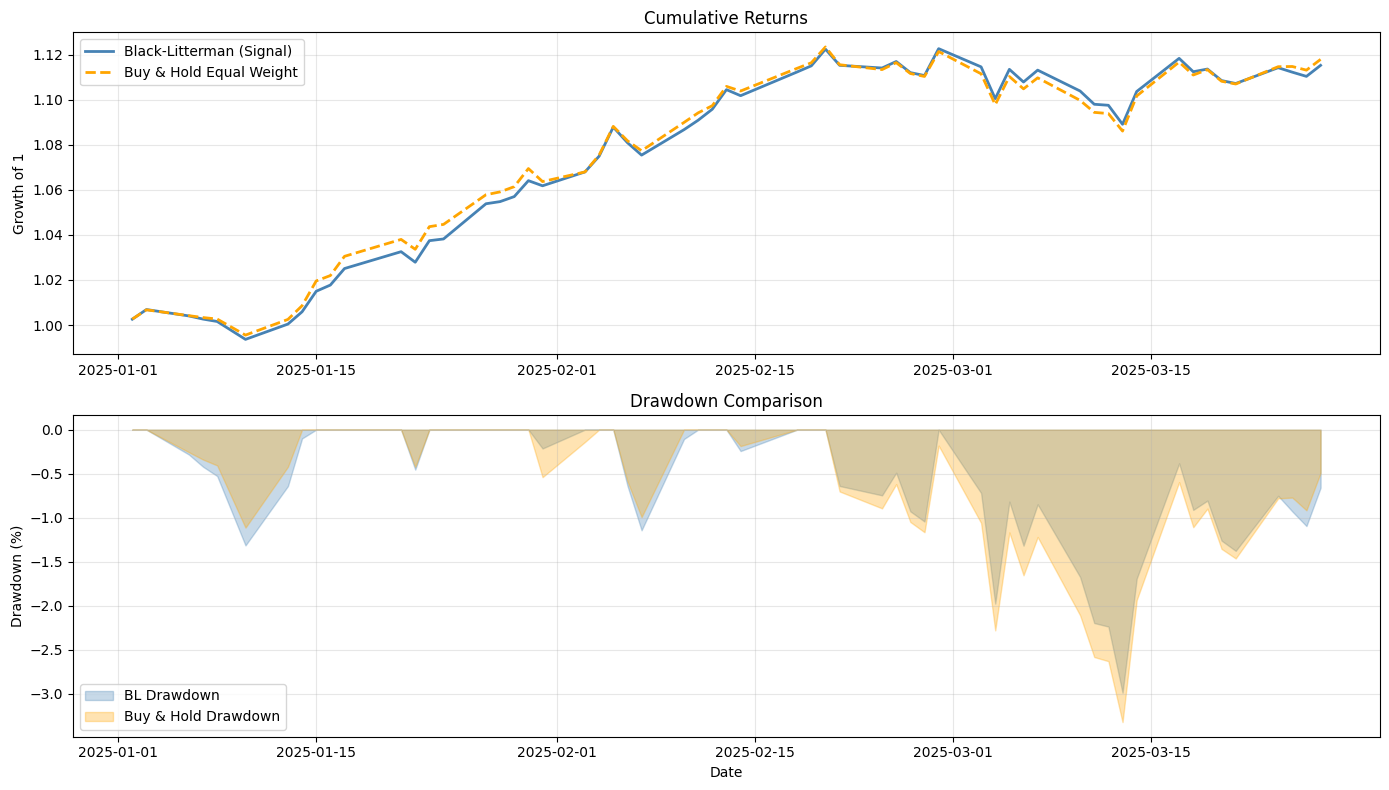

In [11]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

def normalize_signal(signal):
    signal = signal - 0.5
    signal = (signal - signal.mean()) / (signal.std() + 1e-8)
    return signal

def build_views(signal, scale=0.01):
    return scale * signal

def compute_omega(signal):
    sigma = 1.0 / (np.abs(signal) + 1e-6)
    return np.diag(sigma ** 2)

def black_litterman(Sigma, pi, q, Omega, tau=0.05):
    P = np.eye(len(q))
    tauSigma_inv = np.linalg.pinv(tau * Sigma)
    Omega_inv = np.linalg.pinv(Omega)
    middle = tauSigma_inv + P.T @ Omega_inv @ P
    rhs = tauSigma_inv @ pi + P.T @ Omega_inv @ q
    mu_post = np.linalg.pinv(middle) @ rhs
    return mu_post

if "tail_model" not in globals() or "tail_df" not in globals():
    raise ValueError("Run the tail-event training cell first")
if "returns" not in globals():
    raise ValueError("Run the returns preparation cell first")

tail_df = tail_df.copy()
tail_df["trade_date"] = pd.to_datetime(tail_df["trade_date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
tail_df = tail_df.dropna(subset=["trade_date"])

signal_start_date = tail_df["trade_date"].min()
signal_end_date = tail_df["trade_date"].max()

returns_bl = returns.sort_index().copy()
returns_bl = returns_bl[(returns_bl.index >= signal_start_date) & (returns_bl.index <= signal_end_date)]

if len(returns_bl) < 120:
    raise ValueError("Not enough overlapping rows between returns and signal dates")

split_idx_bl = int(0.8 * len(returns_bl))
if split_idx_bl < 60 or split_idx_bl >= len(returns_bl):
    raise ValueError("Not enough rows for BL train/test split")

returns_train_bl = returns_bl.iloc[:split_idx_bl].copy()
returns_test_bl = returns_bl.iloc[split_idx_bl:].copy()
train_end_date = returns_train_bl.index.max()

signal_rows = tail_df[tail_df["trade_date"] <= train_end_date].copy()
if signal_rows.empty:
    raise ValueError("No aligned signal rows before BL test start")

latest_signal_rows = signal_rows.sort_values(["ticker", "trade_date"]).groupby("ticker", as_index=False).tail(1)

X_signal = latest_signal_rows[emb_feature_cols_tail].to_numpy(dtype=np.float32)
X_signal = (X_signal - X_tail_mean) / X_tail_std

device_bl = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
tail_model = tail_model.to(device_bl)
tail_model.eval()
with torch.no_grad():
    signal_logits = tail_model(torch.from_numpy(X_signal).to(device_bl))
    signal_probs = torch.sigmoid(signal_logits).cpu().numpy()

signal_raw = pd.Series(signal_probs, index=latest_signal_rows["ticker"].values)
asset_universe = [c for c in returns_train_bl.columns if c in signal_raw.index]
if len(asset_universe) < 5:
    raise ValueError("Not enough common assets between returns and model signals")

signal_raw = signal_raw.loc[asset_universe]
signal_norm = normalize_signal(signal_raw)
q = build_views(signal_norm.to_numpy(), scale=0.01)

cov_window = 60
if len(returns_train_bl) < cov_window:
    raise ValueError("Not enough training history for rolling covariance window")

Sigma_df = returns_train_bl[asset_universe].tail(cov_window).cov()
Sigma = Sigma_df.to_numpy(dtype=float) + np.eye(len(asset_universe)) * 1e-6

w_mkt = np.ones(len(asset_universe), dtype=float) / len(asset_universe)

mkt_rets = returns_train_bl[asset_universe].tail(cov_window).to_numpy() @ w_mkt
mkt_var = float(np.var(mkt_rets) + 1e-8)
mkt_mean = float(np.mean(mkt_rets))
risk_aversion = float(np.clip(mkt_mean / mkt_var, 0.1, 10.0))

pi = risk_aversion * (Sigma @ w_mkt)
Omega = compute_omega(signal_norm.to_numpy()) + np.eye(len(asset_universe)) * 1e-8

mu_bl = black_litterman(Sigma=Sigma, pi=pi, q=q, Omega=Omega, tau=0.05)

w_bl_raw = np.linalg.pinv(Sigma) @ mu_bl
w_bl_long = np.clip(w_bl_raw, 0, None)
if w_bl_long.sum() <= 0:
    w_bl = w_mkt.copy()
else:
    w_bl = w_bl_long / w_bl_long.sum()

bl_weights = pd.Series(w_bl, index=asset_universe).sort_values(ascending=False)

bl_returns_test = pd.Series(
    returns_test_bl[asset_universe].to_numpy() @ w_bl,
    index=returns_test_bl.index,
    name="Black-Litterman (Signal)",
)
bh_returns_test = returns_test_bl[asset_universe].mean(axis=1).rename("Buy & Hold Equal Weight")

def performance_stats(rets):
    total_return = (1 + rets).prod() - 1
    annual_return = (1 + rets.mean()) ** 252 - 1
    annual_vol = rets.std() * np.sqrt(252)
    sharpe = annual_return / (annual_vol + 1e-12)
    max_drawdown = ((1 + rets).cumprod() / (1 + rets).cumprod().cummax() - 1).min()
    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Annual Vol": annual_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
    }

bl_stats = performance_stats(bl_returns_test)
bh_stats = performance_stats(bh_returns_test)

comparison_bl = pd.DataFrame([bl_stats, bh_stats], index=["Black-Litterman (Signal)", "Buy & Hold Equal Weight"])

bl_cum = (1 + bl_returns_test).cumprod()
bh_cum = (1 + bh_returns_test).cumprod()

print("=" * 80)
print("BLACK-LITTERMAN WITH EMBEDDING MODEL SIGNALS")
print("=" * 80)
print(f"Signal window: {signal_start_date.date()} to {signal_end_date.date()}")
print(f"Assets used: {len(asset_universe)}")
print(f"Covariance window: {cov_window} days")
print(f"Risk aversion lambda: {risk_aversion:.4f}")
print(f"Train/Test rows: {len(returns_train_bl)}/{len(returns_test_bl)}")
print(f"Train end date for signals: {train_end_date.date()}")
print("\nTop 10 BL weights:")
print(bl_weights.head(10).to_string())
print("\nPerformance comparison:")
print(comparison_bl.to_string())

outperformance = bl_cum.iloc[-1] - bh_cum.iloc[-1]
print(f"\nCumulative outperformance (BL - Buy&Hold): {outperformance:.4f} ({outperformance * 100:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(bl_cum.index, bl_cum.values, label="Black-Litterman (Signal)", linewidth=2, color="steelblue")
axes[0].plot(bh_cum.index, bh_cum.values, label="Buy & Hold Equal Weight", linewidth=2, color="orange", linestyle="--")
axes[0].set_title("Cumulative Returns")
axes[0].set_ylabel("Growth of 1")
axes[0].legend()
axes[0].grid(alpha=0.3)

dd_bl = (bl_cum / bl_cum.cummax() - 1) * 100
dd_bh = (bh_cum / bh_cum.cummax() - 1) * 100
axes[1].fill_between(dd_bl.index, dd_bl.values, 0, alpha=0.3, label="BL Drawdown", color="steelblue")
axes[1].fill_between(dd_bh.index, dd_bh.values, 0, alpha=0.3, label="Buy & Hold Drawdown", color="orange")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Dynamic allocation coverage:
  Dates: 2025-01-02 to 2025-03-27
  Rebalances: 58
  Tickers with non-zero avg weight: 17

Top mean allocations:
GSK     0.066046
GE      0.061152
COST    0.059994
CAT     0.059465
USO     0.059375
BABA    0.059342
V       0.058445
XLF     0.058390
ABBV    0.058285
AMGN    0.057835


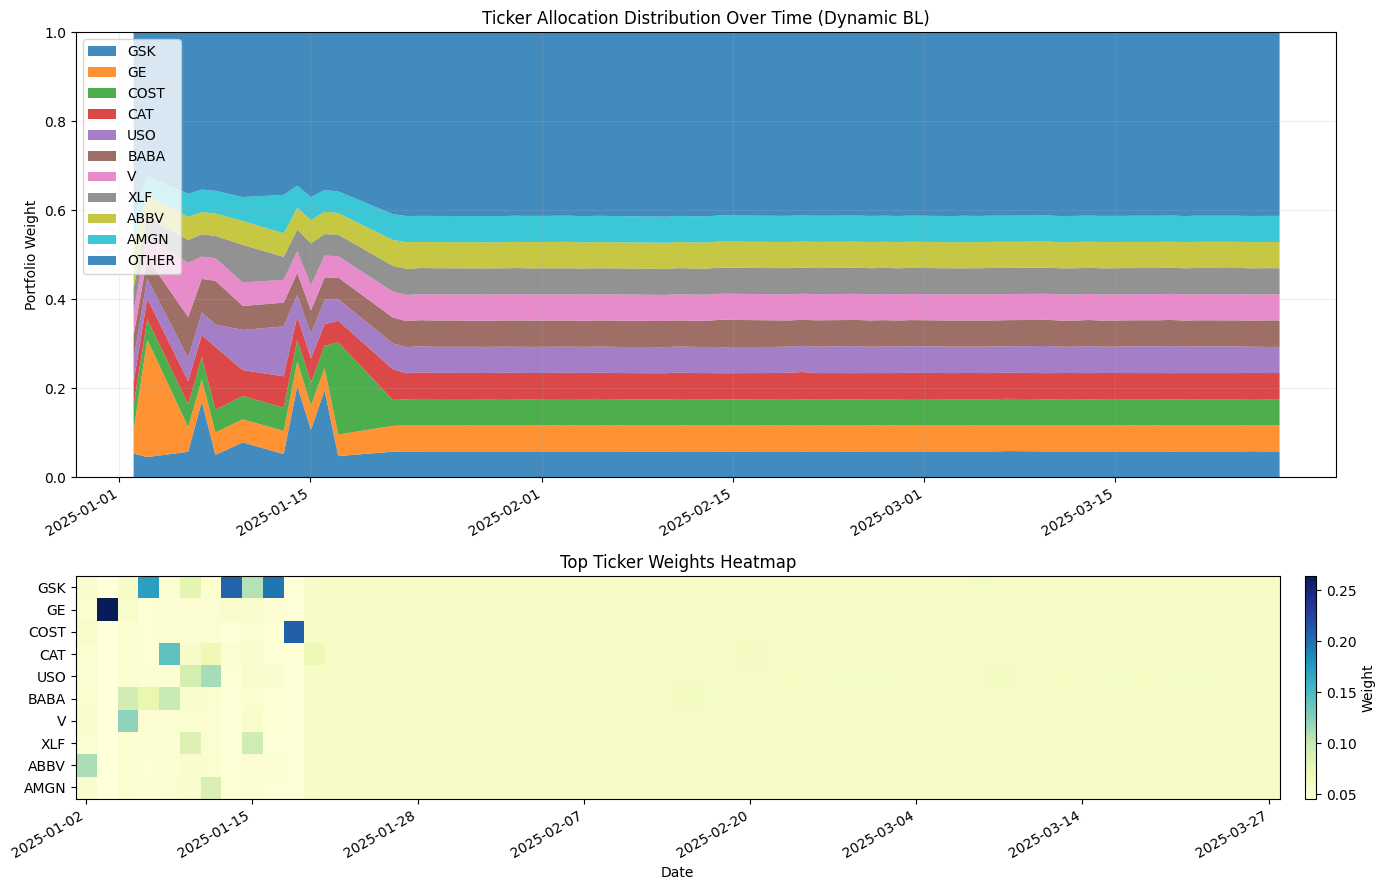

In [12]:
if not all(
    name in globals()
    for name in [
        "returns_bl",
        "returns_test_bl",
        "tail_df",
        "tail_model",
        "emb_feature_cols_tail",
        "X_tail_mean",
        "X_tail_std",
        "cov_window",
    ]
):
    raise ValueError("Run the Black-Litterman signal cell first")

tail_df_dist = tail_df.copy()
tail_df_dist["trade_date"] = pd.to_datetime(
    tail_df_dist["trade_date"], errors="coerce", utc=True
).dt.tz_localize(None).dt.normalize()
tail_df_dist = tail_df_dist.dropna(subset=["trade_date"]).copy()

device_dist = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
tail_model = tail_model.to(device_dist)
tail_model.eval()

def bl_weights_for_date(rebalance_date):
    hist = returns_bl.loc[returns_bl.index < rebalance_date].copy()
    if len(hist) < cov_window:
        return None
    hist = hist.tail(cov_window)

    signal_rows = tail_df_dist[tail_df_dist["trade_date"] < rebalance_date]
    if signal_rows.empty:
        return None
    latest_rows = signal_rows.sort_values(["ticker", "trade_date"]).groupby("ticker", as_index=False).tail(1)

    X_sig = latest_rows[emb_feature_cols_tail].to_numpy(dtype=np.float32)
    X_sig = (X_sig - X_tail_mean) / X_tail_std

    with torch.no_grad():
        logits = tail_model(torch.from_numpy(X_sig).to(device_dist))
        probs = torch.sigmoid(logits).cpu().numpy()

    signal_raw = pd.Series(probs, index=latest_rows["ticker"].values)
    common_assets = [c for c in hist.columns if c in signal_raw.index]
    if len(common_assets) < 5:
        return None

    signal_raw = signal_raw.loc[common_assets]
    signal_norm = normalize_signal(signal_raw)
    q = build_views(signal_norm.to_numpy(), scale=0.01)

    Sigma = hist[common_assets].cov().to_numpy(dtype=float) + np.eye(len(common_assets)) * 1e-6
    w_mkt = np.ones(len(common_assets), dtype=float) / len(common_assets)

    mkt_rets = hist[common_assets].to_numpy() @ w_mkt
    mkt_var = float(np.var(mkt_rets) + 1e-8)
    mkt_mean = float(np.mean(mkt_rets))
    lambda_dist = float(np.clip(mkt_mean / mkt_var, 0.1, 10.0))

    pi = lambda_dist * (Sigma @ w_mkt)
    Omega = compute_omega(signal_norm.to_numpy()) + np.eye(len(common_assets)) * 1e-8
    mu_post = black_litterman(Sigma=Sigma, pi=pi, q=q, Omega=Omega, tau=0.05)

    w_raw = np.linalg.pinv(Sigma) @ mu_post
    w_long = np.clip(w_raw, 0, None)
    if w_long.sum() <= 0:
        w = w_mkt
    else:
        w = w_long / w_long.sum()

    return pd.Series(w, index=common_assets)

allocation_rows = []
for dt in returns_test_bl.index:
    w_dt = bl_weights_for_date(dt)
    if w_dt is not None:
        allocation_rows.append(w_dt.rename(dt))

if not allocation_rows:
    raise ValueError("Could not compute dynamic allocations over test period")

alloc_ts = pd.DataFrame(allocation_rows).fillna(0.0)
alloc_ts = alloc_ts.div(alloc_ts.sum(axis=1), axis=0).fillna(0.0)

mean_alloc = alloc_ts.mean().sort_values(ascending=False)
top_n = min(10, len(mean_alloc))
top_tickers = mean_alloc.head(top_n).index.tolist()

alloc_plot = alloc_ts[top_tickers].copy()
other_weight = (1.0 - alloc_plot.sum(axis=1)).clip(lower=0.0)
if float(other_weight.mean()) > 1e-4:
    alloc_plot["OTHER"] = other_weight

print("Dynamic allocation coverage:")
print(f"  Dates: {alloc_ts.index.min().date()} to {alloc_ts.index.max().date()}")
print(f"  Rebalances: {len(alloc_ts)}")
print(f"  Tickers with non-zero avg weight: {(mean_alloc > 1e-4).sum()}")
print("\nTop mean allocations:")
print(mean_alloc.head(10).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})

alloc_plot.plot.area(ax=axes[0], stacked=True, alpha=0.85, linewidth=0)
axes[0].set_title("Ticker Allocation Distribution Over Time (Dynamic BL)")
axes[0].set_ylabel("Portfolio Weight")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.2)

heatmap_df = alloc_ts[top_tickers].T
im = axes[1].imshow(heatmap_df.values, aspect="auto", cmap="YlGnBu", interpolation="nearest")
axes[1].set_yticks(np.arange(len(top_tickers)))
axes[1].set_yticklabels(top_tickers)

x_ticks = np.linspace(0, heatmap_df.shape[1] - 1, min(8, heatmap_df.shape[1])).astype(int)
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels([heatmap_df.columns[i].strftime("%Y-%m-%d") for i in x_ticks], rotation=30, ha="right")
axes[1].set_title("Top Ticker Weights Heatmap")
axes[1].set_xlabel("Date")
fig.colorbar(im, ax=axes[1], fraction=0.025, pad=0.02, label="Weight")

plt.tight_layout()
plt.show()

Epoch 1/350 | loss=0.714133 | mse=0.028748 | rank=0.701695 | beta_pen=0.664065 | turnover=1.191215
Epoch 50/350 | loss=0.482419 | mse=0.008842 | rank=0.696073 | beta_pen=0.389250 | turnover=0.762114
Epoch 100/350 | loss=0.471701 | mse=0.006654 | rank=0.692394 | beta_pen=0.379566 | turnover=0.727447
Epoch 150/350 | loss=0.466860 | mse=0.004660 | rank=0.690248 | beta_pen=0.376789 | turnover=0.704596
Epoch 200/350 | loss=0.463390 | mse=0.003618 | rank=0.691803 | beta_pen=0.373356 | turnover=0.680379
Epoch 250/350 | loss=0.462611 | mse=0.002681 | rank=0.690508 | beta_pen=0.374082 | turnover=0.674180
Epoch 300/350 | loss=0.460429 | mse=0.001736 | rank=0.690650 | beta_pen=0.372393 | turnover=0.673661
Epoch 350/350 | loss=0.464275 | mse=0.001074 | rank=0.690706 | beta_pen=0.378360 | turnover=0.675430
MULTI-MODAL ALPHA MODEL (NUMERICAL + TEXT + HMM REGIME)
Regime source: HMM
Panel shapes | text: (287, 17, 384) | numerical: (287, 17, 6)
Train/Test dates: 229/58
Tickers: 17 + CASH
Estimated beta

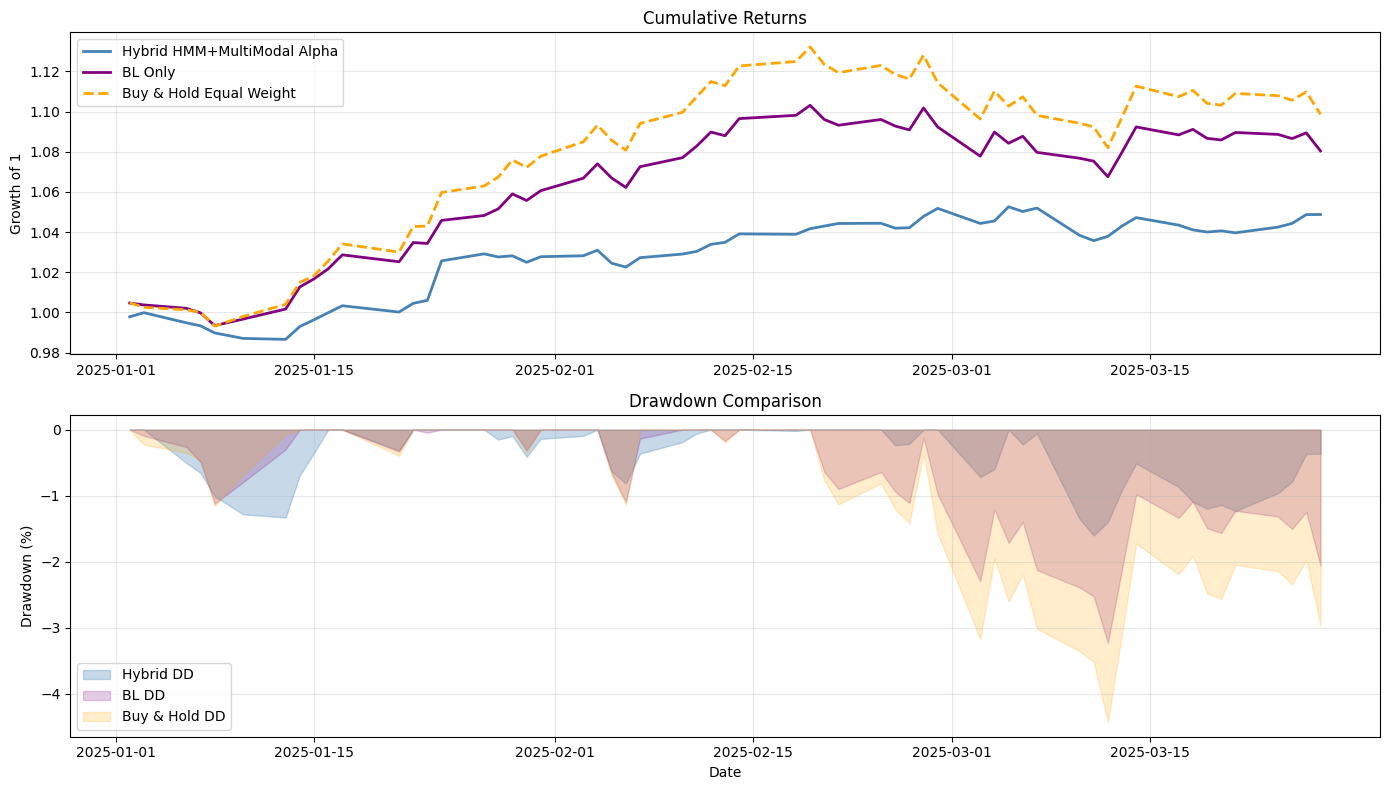

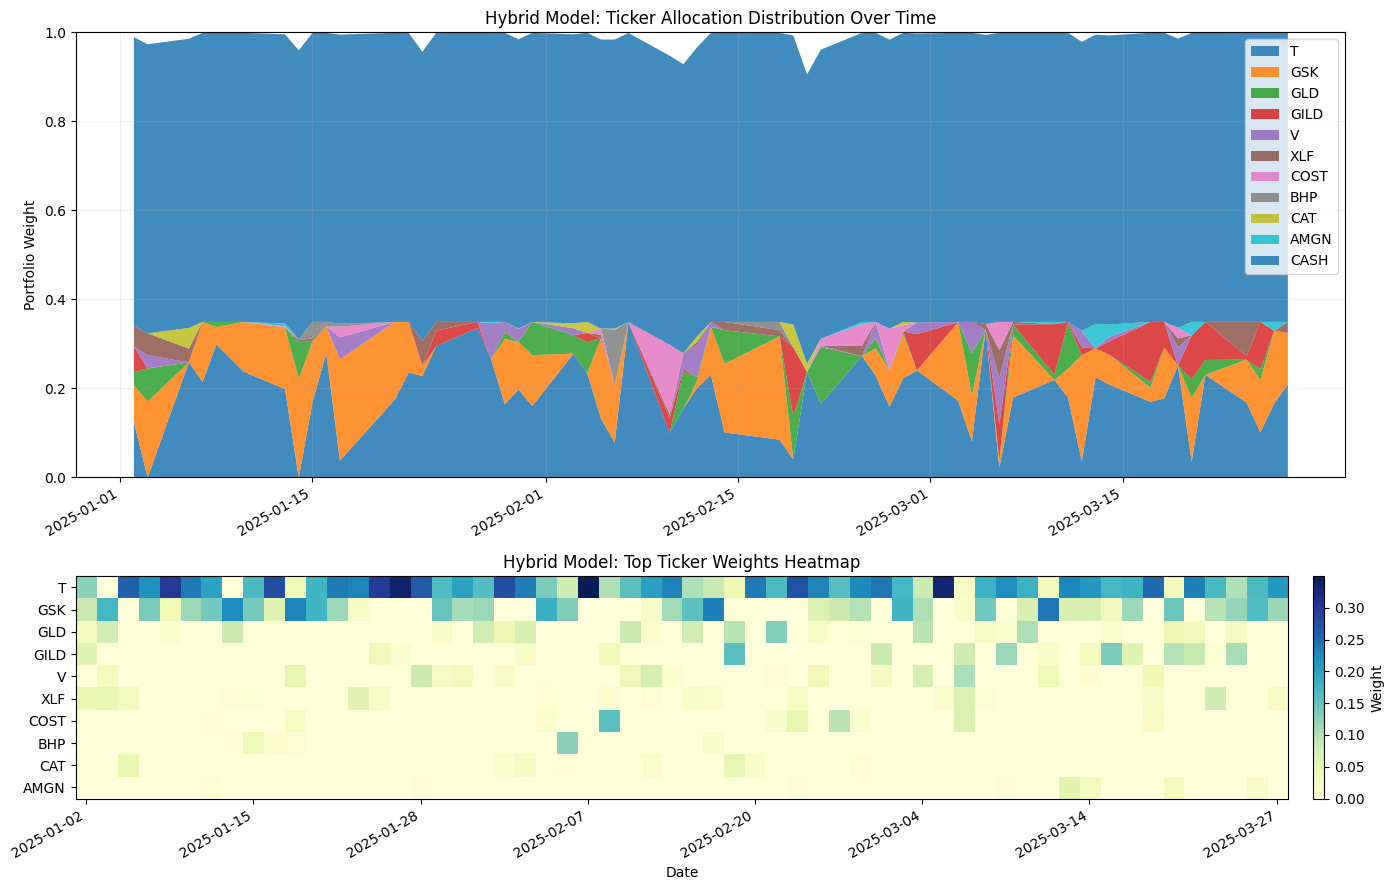

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def normalize_signal(signal):
    signal = signal - 0.5
    signal = (signal - signal.mean()) / (signal.std() + 1e-8)
    return signal

def build_views(signal, scale=0.01):
    return scale * signal

def compute_omega(signal):
    sigma = 1.0 / (np.abs(signal) + 1e-6)
    return np.diag(sigma ** 2)

def black_litterman(Sigma, pi, q, Omega, tau=0.05):
    P = np.eye(len(q), dtype=np.float32)
    tauSigma_inv = np.linalg.pinv(tau * Sigma)
    Omega_inv = np.linalg.pinv(Omega)
    middle = tauSigma_inv + P.T @ Omega_inv @ P
    rhs = tauSigma_inv @ pi + P.T @ Omega_inv @ q
    mu_post = np.linalg.pinv(middle) @ rhs
    return mu_post

def estimate_asset_betas(returns_train, mask_train, market_train, min_obs=20):
    n_assets = returns_train.shape[1]
    betas = np.ones(n_assets, dtype=np.float32)
    market_train = market_train.astype(np.float64)

    for i in range(n_assets):
        valid = mask_train[:, i] > 0.5
        if valid.sum() < min_obs:
            continue

        ri = returns_train[valid, i].astype(np.float64)
        rm = market_train[valid]
        ri_c = ri - ri.mean()
        rm_c = rm - rm.mean()
        var_rm = float((rm_c * rm_c).mean()) + 1e-8
        cov_ir = float((ri_c * rm_c).mean())
        beta_i = cov_ir / var_rm
        betas[i] = np.float32(np.clip(beta_i, -5.0, 5.0))

    return betas

def safe_standardize(train_arr, test_arr):
    mean = train_arr.mean(axis=(0, 1), keepdims=True)
    std = train_arr.std(axis=(0, 1), keepdims=True)
    std[std == 0] = 1.0
    return (train_arr - mean) / std, (test_arr - mean) / std

def pairwise_ranking_loss(alpha_pred, target_residual, mask):
    losses = []
    for t in range(alpha_pred.shape[0]):
        active = mask[t] > 0.5
        if active.sum() < 2:
            continue
        a = alpha_pred[t, active]
        y = target_residual[t, active]

        diff_pred = a.unsqueeze(1) - a.unsqueeze(0)
        diff_true = y.unsqueeze(1) - y.unsqueeze(0)
        sign = torch.sign(diff_true)
        valid = sign != 0
        if valid.any():
            losses.append(F.softplus(-sign[valid] * diff_pred[valid]).mean())

    if losses:
        return torch.stack(losses).mean()
    return torch.tensor(0.0, device=alpha_pred.device)

def alpha_to_weights(alpha_pred, mask, regime_idx, regime_gate):
    n_active = mask.sum(dim=1, keepdim=True)
    mean = (alpha_pred * mask).sum(dim=1, keepdim=True) / (n_active + 1e-8)
    centered = (alpha_pred - mean) * mask
    var = ((centered ** 2) * mask).sum(dim=1, keepdim=True) / (n_active + 1e-8)
    z = centered / torch.sqrt(var + 1e-8)

    pos = torch.relu(z) * mask
    pos_sum = pos.sum(dim=1, keepdim=True)
    eq = mask / (n_active + 1e-8)
    w_core = torch.where(pos_sum > 1e-8, pos / (pos_sum + 1e-8), eq)

    gate = regime_gate[regime_idx].unsqueeze(1)
    w_assets = gate * w_core
    w_cash = 1.0 - gate.squeeze(1)
    w_full = torch.cat([w_assets, w_cash.unsqueeze(1)], dim=1)
    return w_full

def realized_portfolio(w_full, future_returns, mask, cash_return=0.0):
    n_assets = future_returns.shape[1]
    w_assets = w_full[:, :n_assets] * mask
    w_cash = w_full[:, n_assets]
    rp = (w_assets * future_returns).sum(dim=1) + w_cash * cash_return
    return rp

if "daily_emb" not in globals():
    raise ValueError("Run the embedding alignment/prep cell first")
if "tail_model" not in globals() or "tail_df" not in globals():
    raise ValueError("Run the tail-event model cell first")
if "emb_feature_cols_tail" not in globals():
    raise ValueError("Tail embedding feature columns are missing")

df_e2w = daily_emb.copy()
df_e2w["date"] = pd.to_datetime(df_e2w["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
df_e2w = df_e2w.dropna(subset=["date", "ret_fwd", "ticker"]).copy()

emb_cols_model = [c for c in df_e2w.columns if c not in ["ticker", "date", "ret_fwd"]]
if not emb_cols_model:
    raise ValueError("No embedding columns found")

returns_panel = (
    df_e2w.pivot_table(index="date", columns="ticker", values="ret_fwd", aggfunc="mean")
    .sort_index()
    .dropna(how="all")
)
if returns_panel.empty:
    raise ValueError("No returns panel available")

selected_tickers = returns_panel.columns.tolist()
selected_dates = returns_panel.index

if len(selected_tickers) < 2:
    raise ValueError("Need at least 2 tickers for portfolio optimization")
if len(selected_dates) < 60:
    raise ValueError(f"Not enough dates ({len(selected_dates)}) for alpha training")

returns_selected = returns_panel.loc[selected_dates, selected_tickers]
mask_panel = returns_selected.notna().to_numpy(dtype=np.float32)
R_panel = returns_selected.fillna(0.0).to_numpy(dtype=np.float32)
active_count_panel = np.clip(mask_panel.sum(axis=1), 1.0, None)
market_ret_panel = ((R_panel * mask_panel).sum(axis=1) / active_count_panel).astype(np.float32)

daily_emb_agg = (
    df_e2w.groupby(["date", "ticker"], as_index=False)[emb_cols_model]
    .mean()
    .sort_values(["date", "ticker"])
)
emb_groups = {dt: grp.set_index("ticker")[emb_cols_model] for dt, grp in daily_emb_agg.groupby("date")}
emb_global = daily_emb_agg[emb_cols_model].mean().to_numpy(dtype=np.float32)
ticker_to_idx = {tk: i for i, tk in enumerate(selected_tickers)}

T = len(selected_dates)
N = len(selected_tickers)
D_text = len(emb_cols_model)
X_text_raw = np.empty((T, N, D_text), dtype=np.float32)

for t, dt in enumerate(selected_dates):
    day_df = emb_groups.get(dt)
    if day_df is None or day_df.empty:
        X_text_raw[t] = np.tile(emb_global, (N, 1)).astype(np.float32)
        continue

    day_mean = day_df.mean(axis=0).to_numpy(dtype=np.float32)
    day_matrix = np.tile(day_mean, (N, 1)).astype(np.float32)
    common = day_df.index.intersection(selected_tickers)
    for tk in common:
        day_matrix[ticker_to_idx[tk]] = day_df.loc[tk].to_numpy(dtype=np.float32)
    X_text_raw[t] = day_matrix

returns_hist = returns_selected.shift(1)
num_feat_frames = [
    returns_hist,
    returns_hist.rolling(5, min_periods=2).mean(),
    returns_hist.rolling(5, min_periods=2).std(),
    returns_hist.rolling(20, min_periods=5).mean(),
    returns_hist.rolling(20, min_periods=5).std(),
    returns_hist.abs().rolling(20, min_periods=5).mean(),
]

num_feat_arrays = []
for feat_df in num_feat_frames:
    arr = feat_df.to_numpy(dtype=np.float32)
    col_mean = np.nanmean(arr, axis=0)
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)
    nan_idx = np.where(np.isnan(arr))
    if len(nan_idx[0]) > 0:
        arr[nan_idx] = np.take(col_mean, nan_idx[1])
    num_feat_arrays.append(arr)

X_num_raw = np.stack(num_feat_arrays, axis=2).astype(np.float32)
D_num = X_num_raw.shape[2]

split_idx = int(0.8 * T)
if split_idx < 32 or split_idx >= T:
    raise ValueError("Invalid train/test split for alpha allocator")

market_ret = market_ret_panel.astype(np.float64)
market_vol = (
    pd.Series(market_ret, index=selected_dates)
    .rolling(20, min_periods=5)
    .std()
    .bfill()
    .ffill()
    .to_numpy(dtype=np.float64)
)
date_emb = X_text_raw.mean(axis=1).astype(np.float64)

regime_source = "HMM"
try:
    from models.hmm_regimes import classify_sentiment_regimes
    regime_labels_raw, regime_stats, hmm_result = classify_sentiment_regimes(
        text_embeddings=date_emb,
        returns=market_ret,
        volatility=market_vol,
        random_state=42,
    )
except Exception as e:
    z = (market_ret - market_ret.mean()) / (market_ret.std() + 1e-8)
    q1, q2 = np.quantile(z, [0.33, 0.66])
    regime_labels_raw = np.digitize(z, [q1, q2]).astype(int)
    regime_stats = pd.DataFrame({
        "regime_id": [0, 1, 2],
        "label": ["Bearish", "Neutral", "Bullish"],
        "n_days": [(regime_labels_raw == i).sum() for i in range(3)],
        "mean_return": [market_ret[regime_labels_raw == i].mean() if (regime_labels_raw == i).sum() > 0 else np.nan for i in range(3)],
        "volatility": [market_ret[regime_labels_raw == i].std() if (regime_labels_raw == i).sum() > 0 else np.nan for i in range(3)],
    })
    regime_source = f"Fallback ({type(e).__name__})"

unique_regimes = np.sort(np.unique(regime_labels_raw))
regime_to_idx = {int(r): i for i, r in enumerate(unique_regimes)}
regime_idx_all = np.array([regime_to_idx[int(r)] for r in regime_labels_raw], dtype=np.int64)
n_regimes = len(unique_regimes)

regime_vol_emp = np.array([np.std(market_ret[regime_idx_all == i]) if (regime_idx_all == i).sum() > 0 else 0.0 for i in range(n_regimes)], dtype=np.float32)
high_vol_idx = int(np.argmax(regime_vol_emp))
regime_gate_np = np.full(n_regimes, 0.35, dtype=np.float32)
regime_gate_np[high_vol_idx] = 1.0

tail_df_signal = tail_df.copy()
tail_df_signal["trade_date"] = pd.to_datetime(
    tail_df_signal["trade_date"], errors="coerce", utc=True
).dt.tz_localize(None).dt.normalize()
tail_df_signal = tail_df_signal.dropna(subset=["trade_date"]).sort_values(["ticker", "trade_date"])
tail_groups = {tk: grp for tk, grp in tail_df_signal.groupby("ticker")}

device_soft = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
tail_model = tail_model.to(device_soft)
tail_model.eval()

def signal_probs_for_date(rebalance_date, tickers):
    probs = np.full(len(tickers), 0.5, dtype=np.float32)
    rows = []
    idx_map = []

    for i, tk in enumerate(tickers):
        grp = tail_groups.get(tk)
        if grp is None:
            continue
        grp_hist = grp[grp["trade_date"] < rebalance_date]
        if grp_hist.empty:
            continue
        row = grp_hist.iloc[-1][emb_feature_cols_tail].to_numpy(dtype=np.float32)
        rows.append(row)
        idx_map.append(i)

    if rows:
        X_sig = np.vstack(rows)
        X_sig = (X_sig - X_tail_mean) / X_tail_std
        with torch.no_grad():
            logits = tail_model(torch.from_numpy(X_sig).to(device_soft))
            p = torch.sigmoid(logits).cpu().numpy().astype(np.float32)
        probs[np.array(idx_map)] = p

    return pd.Series(probs, index=tickers)

cov_window = min(60, max(30, int(0.5 * split_idx)))
w_mkt_np = np.ones(N, dtype=np.float32) / N

def bl_weights_for_date(rebalance_date):
    hist = returns_selected.loc[returns_selected.index < rebalance_date]
    if len(hist) < cov_window:
        return w_mkt_np.copy()

    hist_tail = hist.tail(cov_window)
    active_assets = ~(hist_tail.isna().all(axis=0).to_numpy())

    X_hist = hist_tail.fillna(0.0).to_numpy(dtype=np.float32)
    if X_hist.shape[0] < 2:
        return w_mkt_np.copy()

    Sigma = np.cov(X_hist, rowvar=False).astype(np.float32)
    if Sigma.ndim == 0:
        Sigma = np.array([[float(Sigma)]], dtype=np.float32)

    diag = np.diag(np.diag(Sigma))
    shrink = 0.2
    Sigma = (1.0 - shrink) * Sigma + shrink * diag + np.eye(N, dtype=np.float32) * 1e-6

    mkt_rets = hist_tail.mean(axis=1, skipna=True).fillna(0.0).to_numpy(dtype=np.float32)
    mkt_var = float(np.var(mkt_rets) + 1e-8)
    mkt_mean = float(np.mean(mkt_rets))
    lam_bl = float(np.clip(mkt_mean / mkt_var, 0.1, 10.0))

    pi = lam_bl * (Sigma @ w_mkt_np)
    sig_probs = signal_probs_for_date(rebalance_date, selected_tickers)
    sig_norm = normalize_signal(sig_probs)
    q = build_views(sig_norm.to_numpy(dtype=np.float32), scale=0.01)
    Omega = compute_omega(sig_norm.to_numpy(dtype=np.float32)) + np.eye(N, dtype=np.float32) * 1e-8

    mu_bl = black_litterman(Sigma=Sigma, pi=pi, q=q, Omega=Omega, tau=0.05)
    w_raw = np.linalg.pinv(Sigma) @ mu_bl
    w_long = np.clip(w_raw, 0, None)
    w_long = w_long * active_assets.astype(np.float32)
    if w_long.sum() <= 0:
        return w_mkt_np.copy()
    return (w_long / w_long.sum()).astype(np.float32)

w_bl_panel = np.stack([bl_weights_for_date(dt) for dt in selected_dates], axis=0).astype(np.float32)

X_text_train_raw = X_text_raw[:split_idx]
X_text_test_raw = X_text_raw[split_idx:]
X_num_train_raw = X_num_raw[:split_idx]
X_num_test_raw = X_num_raw[split_idx:]
R_train = R_panel[:split_idx]
R_test = R_panel[split_idx:]
M_train = mask_panel[:split_idx]
M_test = mask_panel[split_idx:]
reg_train_idx = regime_idx_all[:split_idx]
reg_test_idx = regime_idx_all[split_idx:]
w_bl_test = w_bl_panel[split_idx:]
dates_test_hybrid = selected_dates[split_idx:]

beta_hat = estimate_asset_betas(R_train, M_train, market_ret_panel[:split_idx], min_obs=20)
R_alpha_panel = (R_panel - np.outer(market_ret_panel, beta_hat).astype(np.float32)) * mask_panel
R_alpha_train = R_alpha_panel[:split_idx]
R_alpha_test = R_alpha_panel[split_idx:]

X_text_train, X_text_test = safe_standardize(X_text_train_raw, X_text_test_raw)
X_num_train, X_num_test = safe_standardize(X_num_train_raw, X_num_test_raw)

X_text_train_t = torch.from_numpy(X_text_train).to(device_soft)
X_text_test_t = torch.from_numpy(X_text_test).to(device_soft)
X_num_train_t = torch.from_numpy(X_num_train).to(device_soft)
X_num_test_t = torch.from_numpy(X_num_test).to(device_soft)
reg_train_t = torch.from_numpy(reg_train_idx).long().to(device_soft)
reg_test_t = torch.from_numpy(reg_test_idx).long().to(device_soft)
R_test_t = torch.from_numpy(R_test).to(device_soft)
R_alpha_train_t = torch.from_numpy(R_alpha_train).to(device_soft)
R_alpha_test_t = torch.from_numpy(R_alpha_test).to(device_soft)
M_train_t = torch.from_numpy(M_train).to(device_soft)
M_test_t = torch.from_numpy(M_test).to(device_soft)
beta_hat_t = torch.from_numpy(beta_hat.astype(np.float32)).to(device_soft)
regime_gate_t = torch.from_numpy(regime_gate_np).to(device_soft)

class AlphaModel(nn.Module):
    def __init__(self, emb_dim, num_dim, n_regimes):
        super().__init__()
        self.num_encoder = nn.Sequential(
            nn.Linear(num_dim, 32),
            nn.ReLU(),
            nn.LayerNorm(32),
        )
        self.text_encoder = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 32),
            nn.GELU(),
        )
        self.reg_emb = nn.Embedding(n_regimes, 8)
        self.head = nn.Sequential(
            nn.Linear(32 + 32 + 8, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x_num, e_text, regime):
        h_num = self.num_encoder(x_num)
        h_text = self.text_encoder(e_text)
        h_reg = self.reg_emb(regime).unsqueeze(1).expand(-1, x_num.size(1), -1)
        h = torch.cat([h_num, h_text, h_reg], dim=-1)
        alpha = self.head(h).squeeze(-1)
        return alpha

torch.manual_seed(42)
np.random.seed(42)

alpha_model = AlphaModel(emb_dim=D_text, num_dim=D_num, n_regimes=n_regimes).to(device_soft)
optimizer = torch.optim.Adam(alpha_model.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 350
lambda_rank = 0.25
turnover_coef = 0.01
beta_penalty_coef = 0.75

for epoch in range(epochs):
    alpha_model.train()
    optimizer.zero_grad()

    alpha_pred_train = alpha_model(X_num_train_t, X_text_train_t, reg_train_t)
    mse_loss = (((alpha_pred_train - R_alpha_train_t) ** 2) * M_train_t).sum() / (M_train_t.sum() + 1e-8)
    rank_loss = pairwise_ranking_loss(alpha_pred_train, R_alpha_train_t, M_train_t)

    w_train = alpha_to_weights(alpha_pred_train, M_train_t, reg_train_t, regime_gate_t)
    turnover = torch.abs(w_train[1:] - w_train[:-1]).sum(dim=1).mean() if w_train.shape[0] > 1 else torch.tensor(0.0, device=device_soft)
    beta_exp = (w_train[:, :N] * beta_hat_t.unsqueeze(0)).sum(dim=1)
    beta_penalty = (beta_exp ** 2).mean()

    loss = mse_loss + lambda_rank * rank_loss + turnover_coef * turnover + beta_penalty_coef * beta_penalty
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={loss.item():.6f} | "
            f"mse={mse_loss.item():.6f} | "
            f"rank={rank_loss.item():.6f} | "
            f"beta_pen={beta_penalty.item():.6f} | "
            f"turnover={turnover.item():.6f}"
        )

alpha_model.eval()
with torch.no_grad():
    alpha_pred_test = alpha_model(X_num_test_t, X_text_test_t, reg_test_t)
    w_test = alpha_to_weights(alpha_pred_test, M_test_t, reg_test_t, regime_gate_t)
    rp_alpha_test = realized_portfolio(w_test, R_alpha_test_t, M_test_t, cash_return=0.0)
    rp_actual_test = realized_portfolio(w_test, R_test_t, M_test_t, cash_return=0.0)

hybrid_returns_test = pd.Series(rp_actual_test.cpu().numpy(), index=dates_test_hybrid, name="Hybrid HMM+MultiModal Alpha")
hybrid_alpha_test = pd.Series(rp_alpha_test.cpu().numpy(), index=dates_test_hybrid, name="Hybrid Alpha")
buy_hold_test = returns_selected.loc[dates_test_hybrid].mean(axis=1, skipna=True).fillna(0.0)
buy_hold_test.name = "Buy & Hold Equal Weight"
buy_hold_alpha = pd.Series(
    (M_test * R_alpha_test).sum(axis=1) / np.clip(M_test.sum(axis=1), 1.0, None),
    index=dates_test_hybrid,
    name="Buy & Hold Alpha",
)
bl_only_test = pd.Series((w_bl_test * M_test * R_test).sum(axis=1), index=dates_test_hybrid, name="BL Only")
bl_only_alpha = pd.Series((w_bl_test * M_test * R_alpha_test).sum(axis=1), index=dates_test_hybrid, name="BL Alpha")

weights_test_df = pd.DataFrame(
    w_test.cpu().numpy(),
    index=dates_test_hybrid,
    columns=selected_tickers + ["CASH"],
)

def perf_stats(rets):
    total_return = (1 + rets).prod() - 1
    annual_return = (1 + rets.mean()) ** 252 - 1
    annual_vol = rets.std() * np.sqrt(252)
    sharpe = annual_return / (annual_vol + 1e-12)
    mdd = ((1 + rets).cumprod() / (1 + rets).cumprod().cummax() - 1).min()
    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Annual Vol": annual_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
    }

cmp = pd.DataFrame(
    [perf_stats(hybrid_returns_test), perf_stats(bl_only_test), perf_stats(buy_hold_test)],
    index=["Hybrid HMM+MultiModal Alpha", "BL Only", "Buy & Hold Equal Weight"],
)
cmp_alpha = pd.DataFrame(
    [perf_stats(hybrid_alpha_test), perf_stats(bl_only_alpha), perf_stats(buy_hold_alpha)],
    index=["Hybrid Alpha", "BL Alpha", "Buy & Hold Alpha"],
)

cum_hybrid = (1 + hybrid_returns_test).cumprod()
cum_bl = (1 + bl_only_test).cumprod()
cum_bh = (1 + buy_hold_test).cumprod()

regime_series = pd.Series(regime_idx_all, index=selected_dates)
regime_test = regime_series.loc[dates_test_hybrid]
regime_counts = regime_test.value_counts().sort_index()
regime_gate_used = pd.Series(regime_gate_np, index=np.arange(len(regime_gate_np)))

mkt_test = market_ret_panel[split_idx:]
if np.var(mkt_test) > 1e-12:
    hybrid_beta_test = float(np.cov(hybrid_returns_test.values, mkt_test, ddof=0)[0, 1] / (np.var(mkt_test) + 1e-12))
    hybrid_corr_test = float(np.corrcoef(hybrid_returns_test.values, mkt_test)[0, 1])
else:
    hybrid_beta_test = np.nan
    hybrid_corr_test = np.nan

print("=" * 80)
print("MULTI-MODAL ALPHA MODEL (NUMERICAL + TEXT + HMM REGIME)")
print("=" * 80)
print(f"Regime source: {regime_source}")
print(f"Panel shapes | text: {X_text_raw.shape} | numerical: {X_num_raw.shape}")
print(f"Train/Test dates: {len(X_text_train)}/{len(X_text_test)}")
print(f"Tickers: {N} + CASH")
print(f"Estimated beta stats | mean={beta_hat.mean():.3f} min={beta_hat.min():.3f} max={beta_hat.max():.3f}")
print(f"Regime gate vector: {regime_gate_np.tolist()} (high-vol regime index: {high_vol_idx})")
print(f"Hybrid realized beta vs market (test): {hybrid_beta_test:.4f}")
print(f"Hybrid correlation vs market (test): {hybrid_corr_test:.4f}")
print(f"Average cash weight (test): {weights_test_df['CASH'].mean():.4f}")
print("\nRegime counts in test (mapped ids):")
print(regime_counts.to_string())
print("\nHMM regime stats:")
print(regime_stats.to_string(index=False))
print("\nPerformance comparison (actual returns):")
print(cmp.to_string())
print("\nPerformance comparison (alpha returns):")
print(cmp_alpha.to_string())
print(f"\nHybrid outperformance vs Buy&Hold: {(cum_hybrid.iloc[-1] - cum_bh.iloc[-1]):.4f} ({(cum_hybrid.iloc[-1] - cum_bh.iloc[-1]) * 100:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(cum_hybrid.index, cum_hybrid.values, label="Hybrid HMM+MultiModal Alpha", linewidth=2, color="steelblue")
axes[0].plot(cum_bl.index, cum_bl.values, label="BL Only", linewidth=2, color="purple", linestyle="-")
axes[0].plot(cum_bh.index, cum_bh.values, label="Buy & Hold Equal Weight", linewidth=2, color="orange", linestyle="--")
axes[0].set_title("Cumulative Returns")
axes[0].set_ylabel("Growth of 1")
axes[0].legend()
axes[0].grid(alpha=0.3)

dd_hybrid = (cum_hybrid / cum_hybrid.cummax() - 1) * 100
dd_bl = (cum_bl / cum_bl.cummax() - 1) * 100
dd_bh = (cum_bh / cum_bh.cummax() - 1) * 100
axes[1].fill_between(dd_hybrid.index, dd_hybrid.values, 0, alpha=0.3, label="Hybrid DD", color="steelblue")
axes[1].fill_between(dd_bl.index, dd_bl.values, 0, alpha=0.2, label="BL DD", color="purple")
axes[1].fill_between(dd_bh.index, dd_bh.values, 0, alpha=0.2, label="Buy & Hold DD", color="orange")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

mean_w = weights_test_df.mean().sort_values(ascending=False)
top_k = min(10, len(mean_w) - 1 if "CASH" in mean_w.index else len(mean_w))
top_tickers = [t for t in mean_w.index if t != "CASH"][:top_k]
alloc_plot = weights_test_df[top_tickers].copy()
if "CASH" in weights_test_df.columns:
    alloc_plot["CASH"] = weights_test_df["CASH"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})
alloc_plot.plot.area(ax=axes[0], stacked=True, alpha=0.85, linewidth=0)
axes[0].set_title("Hybrid Model: Ticker Allocation Distribution Over Time")
axes[0].set_ylabel("Portfolio Weight")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.2)

heat_df = weights_test_df[top_tickers].T
im = axes[1].imshow(heat_df.values, aspect="auto", cmap="YlGnBu", interpolation="nearest")
axes[1].set_yticks(np.arange(len(top_tickers)))
axes[1].set_yticklabels(top_tickers)
x_ticks = np.linspace(0, heat_df.shape[1] - 1, min(8, heat_df.shape[1])).astype(int)
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels([heat_df.columns[i].strftime("%Y-%m-%d") for i in x_ticks], rotation=30, ha="right")
axes[1].set_title("Hybrid Model: Top Ticker Weights Heatmap")
axes[1].set_xlabel("Date")
fig.colorbar(im, ax=axes[1], fraction=0.025, pad=0.02, label="Weight")
plt.tight_layout()
plt.show()

Strategy total return: 12.31%
Strategy annual return: 10.73%
Strategy volatility: 7.39%
Strategy Sharpe: 1.452
Buy&Hold total return: 20.47%
Outperformance vs Buy&Hold: -8.16%


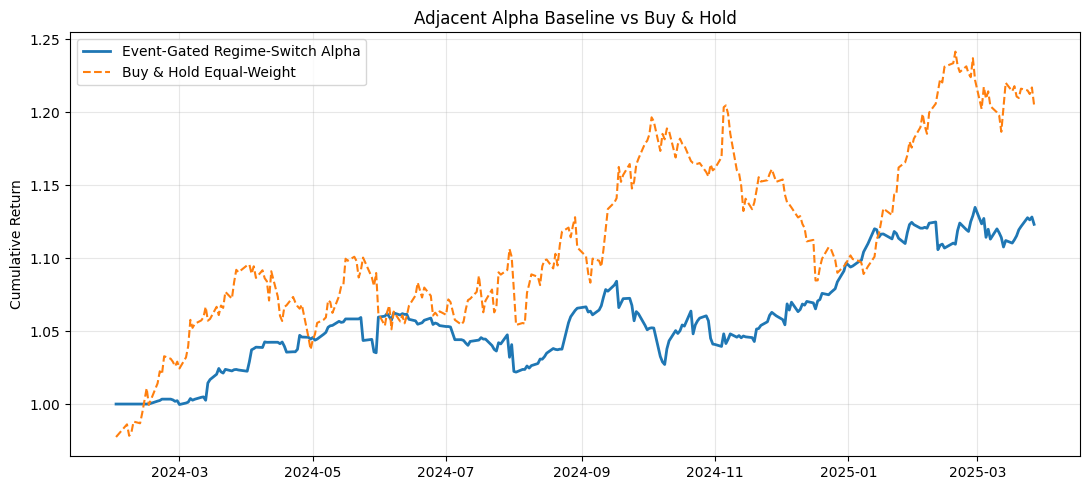

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = daily_emb.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

emb_cols = [c for c in df.columns if c not in ["date", "ticker", "ret_fwd"]]
if len(emb_cols) == 0:
    raise ValueError("No embedding columns found in daily_emb.")

ret_df = df.pivot(index="date", columns="ticker", values="ret_fwd").sort_index()
dates = ret_df.index
tickers = ret_df.columns
T, N = ret_df.shape

idx = pd.MultiIndex.from_product([dates, tickers], names=["date", "ticker"])
emb_panel = df.set_index(["date", "ticker"])[emb_cols].reindex(idx).sort_index()
emb_panel = emb_panel.groupby(level=0).transform(lambda x: x.fillna(x.mean()))
emb_panel = emb_panel.fillna(0.0)

D = len(emb_cols)
emb_tensor = emb_panel.to_numpy(dtype=float).reshape(T, N, D)

split = max(2, int(0.7 * T))
mu = emb_tensor[:split].mean(axis=(0, 1))
sd = emb_tensor[:split].std(axis=(0, 1))
sd = np.where(sd < 1e-8, 1.0, sd)
emb_tensor = (emb_tensor - mu) / sd

drift = np.zeros((T, N), dtype=float)
drift[1:] = np.linalg.norm(emb_tensor[1:] - emb_tensor[:-1], axis=2)

drift_train = drift[:split]
threshold = np.nanpercentile(drift_train[drift_train > 0], 95) if np.any(drift_train > 0) else 0.0
events = (drift >= threshold).astype(float)

alpha_h, beta_h = 0.8, 0.2
decay = np.exp(-beta_h)
intensity = np.zeros((T, N), dtype=float)
for t in range(1, T):
    intensity[t] = decay * intensity[t - 1] + alpha_h * events[t]

intensity_df = pd.DataFrame(intensity, index=dates, columns=tickers)
rank_intensity = intensity_df.rank(axis=1, pct=True)
intensity_gate = (rank_intensity >= 0.70).astype(float)

known_ret = ret_df.shift(1)
market_known = known_ret.mean(axis=1)
vol20 = market_known.rolling(20, min_periods=10).std()
vol20 = vol20.bfill().fillna(0.0)
vol_cut = vol20.iloc[:split].median() if split > 0 else vol20.median()
regime = (vol20 > vol_cut).astype(float)

mom5 = known_ret.rolling(5, min_periods=3).mean()
mom_dir = np.sign(mom5)
rev_dir = -np.sign(known_ret)

regime_matrix = pd.DataFrame(np.repeat(regime.to_numpy()[:, None], N, axis=1), index=dates, columns=tickers)
direction = regime_matrix * rev_dir + (1.0 - regime_matrix) * mom_dir
direction = direction.fillna(0.0)

raw_alpha = intensity_gate * direction
mask = ret_df.notna().astype(float)
raw_alpha = raw_alpha * mask
raw_alpha = raw_alpha.sub(raw_alpha.mean(axis=1), axis=0).fillna(0.0)

den = raw_alpha.abs().sum(axis=1).replace(0.0, np.nan)
weights = raw_alpha.div(den, axis=0).fillna(0.0)
weights = weights.clip(-0.08, 0.08)
weights = weights.div(weights.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

strategy_ret = (weights * ret_df.fillna(0.0)).sum(axis=1)

bh_weights = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_weights * ret_df.fillna(0.0)).sum(axis=1)

def perf_stats(s: pd.Series):
    s = s.fillna(0.0)
    total = (1.0 + s).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(s), 1)) - 1.0
    vol = s.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe

st_total, st_ann, st_vol, st_sharpe = perf_stats(strategy_ret)
bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret)

print(f"Strategy total return: {st_total:.2%}")
print(f"Strategy annual return: {st_ann:.2%}")
print(f"Strategy volatility: {st_vol:.2%}")
print(f"Strategy Sharpe: {st_sharpe:.3f}")
print(f"Buy&Hold total return: {bh_total:.2%}")
print(f"Outperformance vs Buy&Hold: {st_total - bh_total:.2%}")

cum_strategy = (1.0 + strategy_ret).cumprod()
cum_bh = (1.0 + bh_ret).cumprod()

plt.figure(figsize=(11, 5))
plt.plot(cum_strategy.index, cum_strategy.values, label="Event-Gated Regime-Switch Alpha", linewidth=2)
plt.plot(cum_bh.index, cum_bh.values, label="Buy & Hold Equal-Weight", linestyle="--")
plt.title("Adjacent Alpha Baseline vs Buy & Hold")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

                                Total  Annual    Vol  Sharpe   MaxDD  Turnover
Strategy                                                                      
V1 HardGate Switch(5d)         0.1415  0.1232 0.0680  1.8126 -0.0399    0.4625
V3 SoftGate BetaNeutral Smooth 0.1257  0.1096 0.0656  1.6706 -0.0534    0.3873
Buy & Hold EW                  0.2047  0.1777 0.1341  1.3247 -0.0996    0.0000
V2 Accel BetaNeutral           0.0943  0.0823 0.0678  1.2148 -0.0824    0.4721

Best by Sharpe: V1 HardGate Switch(5d)


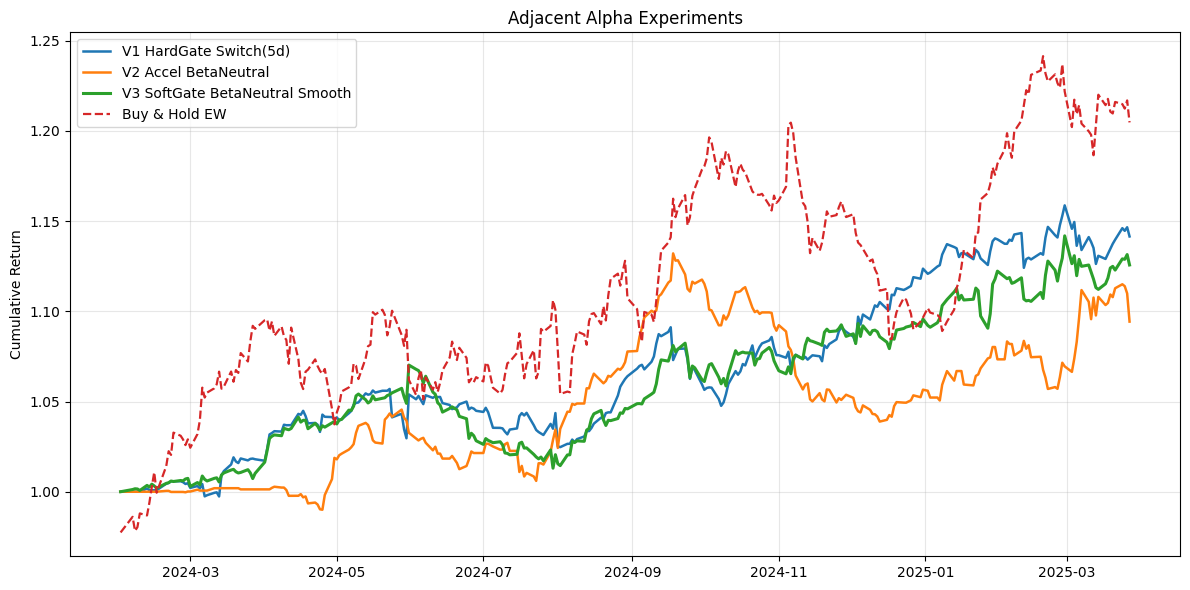

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_vars = ["ret_df", "known_ret", "intensity_df", "regime", "mask", "split"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Run cell 10 first. Missing variables: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def max_drawdown(ret: pd.Series):
    eq = (1.0 + ret.fillna(0.0)).cumprod()
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())


def compute_beta_df(known_returns: pd.DataFrame, lookback: int = 60):
    mkt = known_returns.mean(axis=1)
    mkt_var = mkt.rolling(lookback, min_periods=max(20, lookback // 3)).var()
    out = pd.DataFrame(0.0, index=known_returns.index, columns=known_returns.columns)
    for c in known_returns.columns:
        cov = known_returns[c].rolling(lookback, min_periods=max(20, lookback // 3)).cov(mkt)
        out[c] = cov / mkt_var
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def normalize_weights(raw_alpha: pd.DataFrame, tradable_mask: pd.DataFrame, cap: float = 0.08, beta_df: pd.DataFrame | None = None):
    x = (raw_alpha * tradable_mask).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)

    if beta_df is not None:
        b = (beta_df * tradable_mask).fillna(0.0)
        proj_num = (x * b).sum(axis=1)
        proj_den = (b * b).sum(axis=1).replace(0.0, np.nan)
        k = (proj_num / proj_den).fillna(0.0)
        x = x.sub(b.mul(k, axis=0), axis=0)
        x = x.sub(x.mean(axis=1), axis=0)

    gross = x.abs().sum(axis=1).replace(0.0, np.nan)
    w = x.div(gross, axis=0).fillna(0.0)
    w = w.clip(-cap, cap)
    w = w.div(w.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return w


def smooth_weights(w_raw: pd.DataFrame, smooth: float = 0.35):
    w = w_raw.copy()
    for t in range(1, len(w)):
        w.iloc[t] = smooth * w.iloc[t - 1] + (1.0 - smooth) * w_raw.iloc[t]
        g = np.abs(w.iloc[t]).sum()
        if g > 0:
            w.iloc[t] = w.iloc[t] / g
    return w


def run_variant(name: str, raw_alpha: pd.DataFrame, cap: float = 0.08, beta_df: pd.DataFrame | None = None, smooth: float | None = None):
    w = normalize_weights(raw_alpha, mask, cap=cap, beta_df=beta_df)
    if smooth is not None:
        w = smooth_weights(w, smooth=smooth)

    r = (w * ret_df.fillna(0.0)).sum(axis=1)
    t = 0.5 * w.diff().abs().sum(axis=1).fillna(0.0).mean()
    total, ann, vol, sharpe = perf_stats(r)
    mdd = max_drawdown(r)

    return {
        "name": name,
        "returns": r,
        "weights": w,
        "metrics": {
            "Total": total,
            "Annual": ann,
            "Vol": vol,
            "Sharpe": sharpe,
            "MaxDD": mdd,
            "Turnover": float(t),
        },
    }


int_rank = intensity_df.rank(axis=1, pct=True)
gate_hard = (int_rank >= 0.70).astype(float)
gate_soft = (int_rank - 0.50).clip(lower=0.0) * 2.0

mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)
rev1 = -np.sign(known_ret).fillna(0.0)
resid1 = np.sign(known_ret.sub(known_ret.mean(axis=1), axis=0)).fillna(0.0)

regime_mat = pd.DataFrame(np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1), index=ret_df.index, columns=ret_df.columns)
dir_switch_5 = regime_mat * rev1 + (1.0 - regime_mat) * mom5
dir_switch_10 = regime_mat * rev1 + (1.0 - regime_mat) * mom10

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

beta_df = compute_beta_df(known_ret, lookback=60)

raw_v1 = gate_hard * dir_switch_5
raw_v2 = accel_pos * dir_switch_10
raw_v3 = gate_soft * (0.6 * dir_switch_5 + 0.4 * resid1)

res_v1 = run_variant("V1 HardGate Switch(5d)", raw_v1, cap=0.08, beta_df=None, smooth=None)
res_v2 = run_variant("V2 Accel BetaNeutral", raw_v2, cap=0.08, beta_df=beta_df, smooth=None)
res_v3 = run_variant("V3 SoftGate BetaNeutral Smooth", raw_v3, cap=0.08, beta_df=beta_df, smooth=0.35)

bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret2 = (bh_w * ret_df.fillna(0.0)).sum(axis=1)
bh_total2, bh_ann2, bh_vol2, bh_sharpe2 = perf_stats(bh_ret2)

rows = []
for res in [res_v1, res_v2, res_v3]:
    m = res["metrics"]
    rows.append([res["name"], m["Total"], m["Annual"], m["Vol"], m["Sharpe"], m["MaxDD"], m["Turnover"]])
rows.append(["Buy & Hold EW", bh_total2, bh_ann2, bh_vol2, bh_sharpe2, max_drawdown(bh_ret2), 0.0])

cmp = pd.DataFrame(rows, columns=["Strategy", "Total", "Annual", "Vol", "Sharpe", "MaxDD", "Turnover"]).set_index("Strategy")
print(cmp.sort_values("Sharpe", ascending=False).to_string(float_format=lambda x: f"{x:,.4f}"))

best_name = cmp.sort_values("Sharpe", ascending=False).index[0]
print(f"\nBest by Sharpe: {best_name}")

cum_v1 = (1.0 + res_v1["returns"]).cumprod()
cum_v2 = (1.0 + res_v2["returns"]).cumprod()
cum_v3 = (1.0 + res_v3["returns"]).cumprod()
cum_bh2 = (1.0 + bh_ret2).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_v1.index, cum_v1.values, label=res_v1["name"], linewidth=1.8)
plt.plot(cum_v2.index, cum_v2.values, label=res_v2["name"], linewidth=1.8)
plt.plot(cum_v3.index, cum_v3.values, label=res_v3["name"], linewidth=2.2)
plt.plot(cum_bh2.index, cum_bh2.values, label="Buy & Hold EW", linestyle="--", linewidth=1.6)
plt.title("Adjacent Alpha Experiments")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Top 12 by test outperformance vs Buy&Hold:
                                TrainTotal  TrainSharpe  TestTotal  TestSharpe  TestOutperfVsBH  TestVol
Strategy                                                                                                
hard_65|mom3_rev|long|mix0.00      -0.0609      -0.4412     0.2042      4.5074           0.1414   0.1582
hard_70|mom3_rev|long|mix0.00      -0.0609      -0.4412     0.2042      4.5074           0.1414   0.1582
hard_65|mom3_rev|long|mix0.25       0.0196       0.1461     0.1876      4.5181           0.1248   0.1429
hard_70|mom3_rev|long|mix0.25       0.0196       0.1461     0.1876      4.5181           0.1248   0.1429
hard_65|mom3_flat|long|mix0.00     -0.1387      -1.2740     0.1728      3.8368           0.1099   0.1529
hard_70|mom3_flat|long|mix0.00     -0.1387      -1.2740     0.1728      3.8368           0.1099   0.1529
hard_75|mom3_rev|long|mix0.00      -0.0874      -0.6260     0.1702      3.0808           0.1073   0.1871
hard_65|mom3

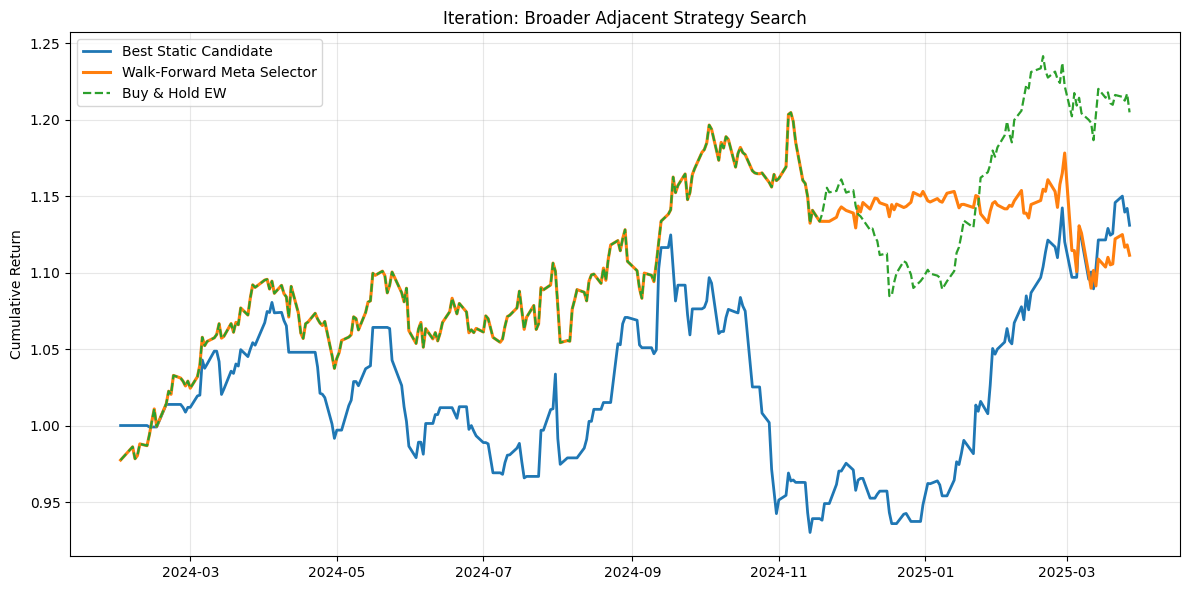

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["ret_df", "known_ret", "intensity_df", "regime", "mask", "split"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Run cells 10 and 11 first. Missing: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def make_weights(raw_alpha: pd.DataFrame, mode: str, bh_w: pd.DataFrame, mix_bh: float, cap: float):
    x = (raw_alpha * mask).fillna(0.0)
    if mode == "ls":
        x = x.sub(x.mean(axis=1), axis=0)
        w = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    elif mode == "long":
        x = x.clip(lower=0.0)
        w = x.div(x.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    else:
        raise ValueError("mode must be 'ls' or 'long'")

    w = w.clip(-cap, cap)
    if mode == "ls":
        w = w.div(w.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    else:
        w = w.clip(lower=0.0)
        w = w.div(w.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

    if mix_bh > 0.0:
        w = (1.0 - mix_bh) * w + mix_bh * bh_w
        if mode == "ls":
            w = w.div(w.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
        else:
            w = w.clip(lower=0.0)
            w = w.div(w.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

    return w


reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)

int_rank = intensity_df.rank(axis=1, pct=True)
accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

gates = {}
for q in [0.60, 0.65, 0.70, 0.75, 0.80]:
    gates[f"hard_{int(q*100)}"] = (int_rank >= q).astype(float)
gates["soft"] = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
gates["accel"] = accel.clip(lower=0.0)

directions = {}
rev1 = -np.sign(known_ret).fillna(0.0)
for w in [3, 5, 10, 20]:
    mom = np.sign(known_ret.rolling(w, min_periods=max(2, w // 2)).mean()).fillna(0.0)
    directions[f"mom{w}_rev"] = reg_mat * rev1 + (1.0 - reg_mat) * mom
    directions[f"mom{w}_flat"] = (1.0 - reg_mat) * mom

bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_df.fillna(0.0)).sum(axis=1)

cand_returns = {}
summary_rows = []

for g_name, g in gates.items():
    for d_name, d in directions.items():
        raw = g * d
        for mode in ["ls", "long"]:
            for mix in [0.00, 0.25, 0.50]:
                cap = 0.08 if mode == "ls" else 0.15
                w = make_weights(raw, mode=mode, bh_w=bh_w, mix_bh=mix, cap=cap)
                r = (w * ret_df.fillna(0.0)).sum(axis=1)

                name = f"{g_name}|{d_name}|{mode}|mix{mix:.2f}"
                cand_returns[name] = r

                train_r = r.iloc[:split]
                test_r = r.iloc[split:]
                bh_test = bh_ret.iloc[split:]

                tr_total, tr_ann, tr_vol, tr_sharpe = perf_stats(train_r)
                te_total, te_ann, te_vol, te_sharpe = perf_stats(test_r)
                bh_te_total, bh_te_ann, bh_te_vol, bh_te_sharpe = perf_stats(bh_test)

                summary_rows.append(
                    {
                        "Strategy": name,
                        "TrainTotal": tr_total,
                        "TrainSharpe": tr_sharpe,
                        "TestTotal": te_total,
                        "TestSharpe": te_sharpe,
                        "TestOutperfVsBH": te_total - bh_te_total,
                        "TestVol": te_vol,
                    }
                )

summary = pd.DataFrame(summary_rows).set_index("Strategy")
summary = summary.sort_values(["TestOutperfVsBH", "TestSharpe"], ascending=False)

print("Top 12 by test outperformance vs Buy&Hold:")
print(summary.head(12).to_string(float_format=lambda x: f"{x:,.4f}"))

best_static_name = summary.index[0]
best_static_ret = cand_returns[best_static_name]

cand_df = pd.DataFrame(cand_returns)
cand_df["Buy&Hold"] = bh_ret

start = max(int(split), 80)
lookback = 80
meta_ret = pd.Series(0.0, index=ret_df.index)
meta_pick = []
current = "Buy&Hold"

meta_ret.iloc[:start] = bh_ret.iloc[:start]

for t in range(start, len(cand_df)):
    hist = cand_df.iloc[max(0, t - lookback):t]
    mu = hist.mean(axis=0)
    sd = hist.std(axis=0, ddof=0).replace(0.0, np.nan)
    score = (mu / sd * np.sqrt(252.0)).replace([np.inf, -np.inf], np.nan).fillna(-1e9)

    best = score.idxmax()
    if current in score.index and score[current] >= score[best] - 0.15:
        pick = current
    else:
        pick = best

    current = pick
    meta_pick.append(pick)
    meta_ret.iloc[t] = cand_df.iloc[t][pick]

meta_total, meta_ann, meta_vol, meta_sharpe = perf_stats(meta_ret)
bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret)
static_total, static_ann, static_vol, static_sharpe = perf_stats(best_static_ret)

print("\nSelected static best strategy:")
print(best_static_name)
print(f"Static best total: {static_total:.2%} | Sharpe: {static_sharpe:.3f}")
print(f"Meta-selector total: {meta_total:.2%} | Sharpe: {meta_sharpe:.3f}")
print(f"Buy&Hold total: {bh_total:.2%} | Sharpe: {bh_sharpe:.3f}")
print(f"Meta outperformance vs Buy&Hold: {meta_total - bh_total:.2%}")

if len(meta_pick) > 0:
    pick_count = pd.Series(meta_pick).value_counts().head(8)
    print("\nMost selected strategies by meta-selector:")
    print(pick_count.to_string())

cum_static = (1.0 + best_static_ret).cumprod()
cum_meta = (1.0 + meta_ret).cumprod()
cum_bh = (1.0 + bh_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_static.index, cum_static.values, label="Best Static Candidate", linewidth=2)
plt.plot(cum_meta.index, cum_meta.values, label="Walk-Forward Meta Selector", linewidth=2.2)
plt.plot(cum_bh.index, cum_bh.values, label="Buy & Hold EW", linestyle="--", linewidth=1.6)
plt.title("Iteration: Broader Adjacent Strategy Search")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Top 10 selected by train score:
                                                        Signal      k     up   down  TrainScore  TrainTotal  TrainSharpe  TestTotal  TestSharpe  TestOutperfVsBH
Key                                                                                                                                                             
S2_soft_mom5_rev|k0.50|up1.10|down1.00        S2_soft_mom5_rev 0.5000 1.1000 1.0000      1.6156      0.1776       1.5634     0.1141      2.9130           0.0513
S2_soft_mom5_rev|k0.50|up1.20|down1.00        S2_soft_mom5_rev 0.5000 1.2000 1.0000      1.6145      0.1879       1.5594     0.1233      3.0125           0.0605
S2_soft_mom5_rev|k0.50|up1.00|down1.00        S2_soft_mom5_rev 0.5000 1.0000 1.0000      1.6141      0.1673       1.5648     0.1050      2.8018           0.0421
S2_soft_mom5_rev|k0.50|up1.30|down1.00        S2_soft_mom5_rev 0.5000 1.3000 1.0000      1.6116      0.1982       1.5537     0.1326      3.1023           0.0698
S2

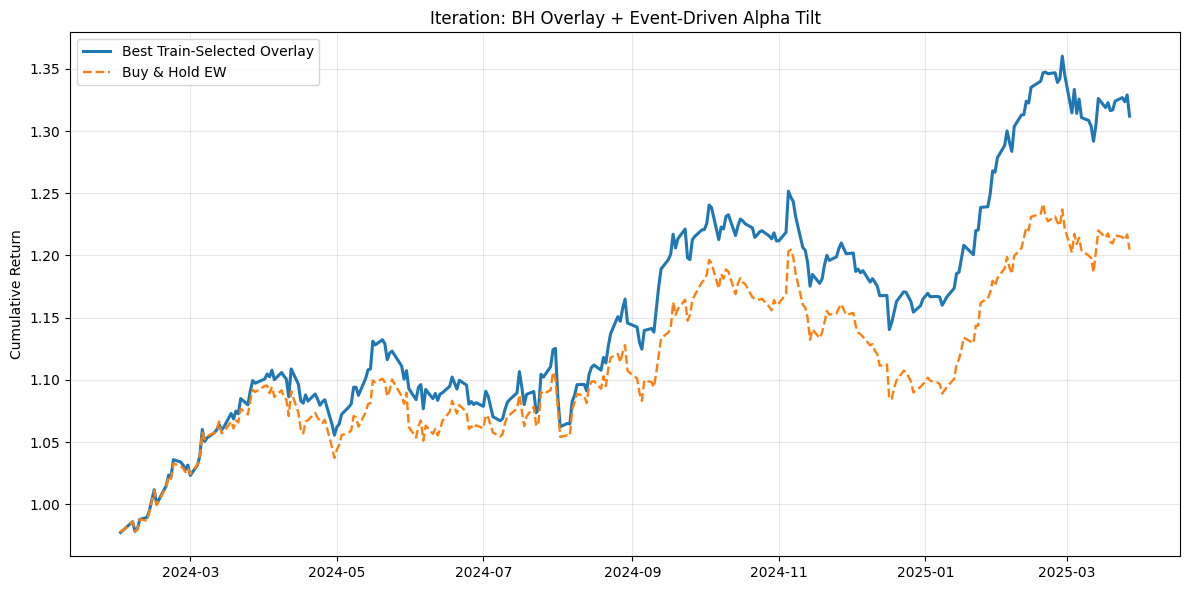

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["ret_df", "known_ret", "intensity_df", "regime", "mask", "split"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Run prior strategy cells first. Missing: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def build_tilt(raw_alpha: pd.DataFrame):
    x = (raw_alpha * mask).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x


reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)

int_rank = intensity_df.rank(axis=1, pct=True)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard65 = (int_rank >= 0.65).astype(float)
hard70 = (int_rank >= 0.70).astype(float)

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signals = {
    "S1_hard70_mom3_rev": hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3),
    "S2_soft_mom5_rev": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
    "S3_accel_mom10_rev": accel_pos * (reg_mat * rev1 + (1.0 - reg_mat) * mom10),
    "S4_hard65_mom5_flat": hard65 * ((1.0 - reg_mat) * mom5),
}

bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_df.fillna(0.0)).sum(axis=1)

mkt_trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)

records = []
curves = {}

for s_name, raw in signals.items():
    tilt = build_tilt(raw)

    for k in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
        for up in [1.00, 1.10, 1.20, 1.30]:
            for down in [0.20, 0.40, 0.60, 0.80, 1.00]:
                exposure = pd.Series(np.where(mkt_trend > 0.0, up, down), index=ret_df.index)

                w_tilted = (bh_w + k * tilt).clip(lower=0.0)
                w_tilted = w_tilted.div(w_tilted.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

                base_ret = (w_tilted * ret_df.fillna(0.0)).sum(axis=1)
                strat_ret = exposure * base_ret

                tr = strat_ret.iloc[:split]
                te = strat_ret.iloc[split:]
                bh_te = bh_ret.iloc[split:]

                tr_total, tr_ann, tr_vol, tr_sharpe = perf_stats(tr)
                te_total, te_ann, te_vol, te_sharpe = perf_stats(te)
                bh_te_total, bh_te_ann, bh_te_vol, bh_te_sharpe = perf_stats(bh_te)

                key = f"{s_name}|k{k:.2f}|up{up:.2f}|down{down:.2f}"
                curves[key] = strat_ret

                train_score = tr_sharpe + 0.50 * tr_total - 0.25 * tr_vol

                records.append(
                    {
                        "Key": key,
                        "Signal": s_name,
                        "k": k,
                        "up": up,
                        "down": down,
                        "TrainScore": train_score,
                        "TrainTotal": tr_total,
                        "TrainSharpe": tr_sharpe,
                        "TestTotal": te_total,
                        "TestSharpe": te_sharpe,
                        "TestOutperfVsBH": te_total - bh_te_total,
                    }
                )

res = pd.DataFrame(records).set_index("Key")
res_train = res.sort_values("TrainScore", ascending=False)
res_test = res.sort_values("TestOutperfVsBH", ascending=False)

print("Top 10 selected by train score:")
print(res_train.head(10).to_string(float_format=lambda x: f"{x:,.4f}"))

print("\nTop 10 by test outperformance vs Buy&Hold (research diagnostic):")
print(res_test.head(10).to_string(float_format=lambda x: f"{x:,.4f}"))

best_key = res_train.index[0]
best_ret = curves[best_key]

best_total, best_ann, best_vol, best_sharpe = perf_stats(best_ret)
bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_ret)

print(f"\nChosen strategy: {best_key}")
print(f"Chosen total: {best_total:.2%} | annual: {best_ann:.2%} | vol: {best_vol:.2%} | sharpe: {best_sharpe:.3f}")
print(f"Buy&Hold total: {bh_total:.2%} | annual: {bh_ann:.2%} | vol: {bh_vol:.2%} | sharpe: {bh_sharpe:.3f}")
print(f"Outperformance vs Buy&Hold: {best_total - bh_total:.2%}")

cum_best = (1.0 + best_ret).cumprod()
cum_bh = (1.0 + bh_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_best.index, cum_best.values, label="Best Train-Selected Overlay", linewidth=2.2)
plt.plot(cum_bh.index, cum_bh.values, label="Buy & Hold EW", linestyle="--", linewidth=1.7)
plt.title("Iteration: BH Overlay + Event-Driven Alpha Tilt")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Best model tested: S2_soft_mom5_rev|k0.50|up1.10|down1.00
                    Total  Annual    Vol  Sharpe   MaxDD  Turnover  AvgNames  OutperfVsLocalBH  OutperfVsGlobalBH
Portfolio                                                                                                        
HighVol            0.3644  0.3137 0.1374  2.2835 -0.0731    0.3664    5.0627            0.1210             0.1596
HighBeta           0.3460  0.2981 0.1383  2.1561 -0.0816    0.3851    4.9199            0.1345             0.1413
All                0.3120  0.2693 0.1405  1.9158 -0.0888    0.3818    7.4843            0.1072             0.1072
PositiveTrendNames 0.2916  0.2519 0.1497  1.6831 -0.1171    0.3360    3.7038            0.0732             0.0869
LowBeta            0.2394  0.2074 0.1983  1.0456 -0.1197    0.2653    2.5645            0.0141             0.0346
HighIntensity      0.2375  0.2057 0.1422  1.4466 -0.0898    0.4139    4.5331            0.1102             0.0327
TopConviction30    0.2208  0.1

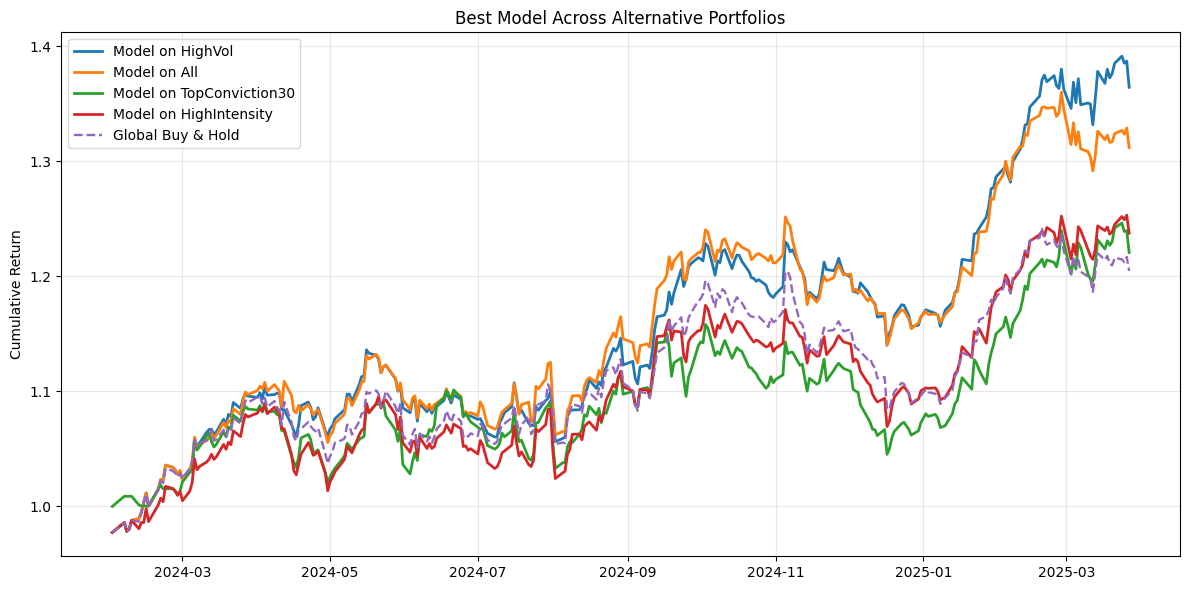

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["ret_df", "known_ret", "intensity_df", "regime", "mask", "best_key"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Run prior cells first. Missing: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def max_dd(ret: pd.Series):
    eq = (1.0 + ret.fillna(0.0)).cumprod()
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())


parts = best_key.split("|")
signal_name = parts[0]
k_val = float(parts[1].replace("k", ""))
up_val = float(parts[2].replace("up", ""))
down_val = float(parts[3].replace("down", ""))

reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)
int_rank = intensity_df.rank(axis=1, pct=True)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard65 = (int_rank >= 0.65).astype(float)
hard70 = (int_rank >= 0.70).astype(float)

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signal_map = {
    "S1_hard70_mom3_rev": hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3),
    "S2_soft_mom5_rev": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
    "S3_accel_mom10_rev": accel_pos * (reg_mat * rev1 + (1.0 - reg_mat) * mom10),
    "S4_hard65_mom5_flat": hard65 * ((1.0 - reg_mat) * mom5),
}

if signal_name not in signal_map:
    raise ValueError(f"Unknown signal in best_key: {signal_name}")

raw_signal = signal_map[signal_name]

market_trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)
exposure = pd.Series(np.where(market_trend > 0.0, up_val, down_val), index=ret_df.index)

asset_vol = known_ret.rolling(20, min_periods=10).std().fillna(0.0)
vol_rank = asset_vol.rank(axis=1, pct=True)

market_ret = known_ret.mean(axis=1)
market_var = market_ret.rolling(60, min_periods=20).var().replace(0.0, np.nan)
beta_df = pd.DataFrame(index=ret_df.index, columns=ret_df.columns, dtype=float)
for c in ret_df.columns:
    cov = known_ret[c].rolling(60, min_periods=20).cov(market_ret)
    beta_df[c] = cov / market_var
beta_df = beta_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
beta_rank = beta_df.rank(axis=1, pct=True)

mom20 = known_ret.rolling(20, min_periods=10).mean().fillna(0.0)
conv_rank = raw_signal.abs().rank(axis=1, pct=True)

filters = {
    "All": pd.DataFrame(1.0, index=ret_df.index, columns=ret_df.columns),
    "HighIntensity": (int_rank >= 0.50).astype(float),
    "LowIntensity": (int_rank < 0.50).astype(float),
    "LowVol": (vol_rank <= 0.50).astype(float),
    "HighVol": (vol_rank > 0.50).astype(float),
    "LowBeta": (beta_rank <= 0.50).astype(float),
    "HighBeta": (beta_rank > 0.50).astype(float),
    "PositiveTrendNames": (mom20 > 0.0).astype(float),
    "TopConviction30": (conv_rank >= 0.70).astype(float),
}

ret_filled = ret_df.fillna(0.0)
global_bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
global_bh_ret = (global_bh_w * ret_filled).sum(axis=1)
gbh_total, gbh_ann, gbh_vol, gbh_sharpe = perf_stats(global_bh_ret)

rows = []
curve_map = {}

for name, sleeve in filters.items():
    tradable = (mask * sleeve).fillna(0.0)

    bh_w_local = tradable.div(tradable.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    bh_local_ret = (bh_w_local * ret_filled).sum(axis=1)

    tilt = (raw_signal * tradable).fillna(0.0)
    tilt = tilt.sub(tilt.mean(axis=1), axis=0)
    tilt = tilt.div(tilt.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

    w = (bh_w_local + k_val * tilt).clip(lower=0.0)
    w = w.div(w.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

    base_ret = (w * ret_filled).sum(axis=1)
    strat_ret = exposure * base_ret

    st_total, st_ann, st_vol, st_sharpe = perf_stats(strat_ret)
    bh_total, bh_ann, bh_vol, bh_sharpe = perf_stats(bh_local_ret)

    turnover = float(0.5 * w.diff().abs().sum(axis=1).fillna(0.0).mean())
    active_names = float(tradable.sum(axis=1).mean())

    rows.append(
        {
            "Portfolio": name,
            "Total": st_total,
            "Annual": st_ann,
            "Vol": st_vol,
            "Sharpe": st_sharpe,
            "MaxDD": max_dd(strat_ret),
            "Turnover": turnover,
            "AvgNames": active_names,
            "OutperfVsLocalBH": st_total - bh_total,
            "OutperfVsGlobalBH": st_total - gbh_total,
        }
    )

    curve_map[name] = (1.0 + strat_ret).cumprod()

result = pd.DataFrame(rows).set_index("Portfolio").sort_values("OutperfVsGlobalBH", ascending=False)
print(f"Best model tested: {best_key}")
print(result.to_string(float_format=lambda x: f"{x:,.4f}"))

best_port = result.index[0]
print(f"\nTop portfolio sleeve by global outperformance: {best_port}")

plot_names = [best_port, "All", "TopConviction30", "HighIntensity"]
plot_names = [n for n in plot_names if n in curve_map]
plot_names = list(dict.fromkeys(plot_names))

plt.figure(figsize=(12, 6))
for n in plot_names:
    plt.plot(curve_map[n].index, curve_map[n].values, label=f"Model on {n}", linewidth=2)

cum_bh = (1.0 + global_bh_ret).cumprod()
plt.plot(cum_bh.index, cum_bh.values, label="Global Buy & Hold", linestyle="--", linewidth=1.7)
plt.title("Best Model Across Alternative Portfolios")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## How This Model Works

### 1) Goal
The model starts from an equal-weight baseline and adds an event-driven alpha tilt from text-embedding dynamics, while keeping construction simple and robust.

### 2) Inputs
- `ret_df`: next-day returns panel by date and ticker
- `known_ret = ret_df.shift(1)`: only information known at decision time
- `intensity_df`: Hawkes-style event intensity from embedding drift
- `regime`: high/low volatility state from market rolling volatility

### 3) Signal Definition (Best Model)
The selected model is:

`S2_soft_mom5_rev | k=0.50 | up=1.10 | down=1.00`

Signal components:

1. Soft event gate from cross-sectional intensity rank:

$$
g_{t,i} = \text{clip}\left(2\left(\text{rank}_{t,i}(\lambda)-0.5\right), 0, 1\right)
$$

2. Regime-switch direction using known returns:

$$
d_{t,i} = r^{regime}_t \cdot (-\text{sign}(\overline{r}^{(1)}_{t,i})) + (1-r^{regime}_t) \cdot \text{sign}(\overline{r}^{(5)}_{t,i})
$$

- In high-vol regime: short-term reversal
- In low-vol regime: 5-day momentum

3. Raw alpha:

$$
a_{t,i} = g_{t,i} \cdot d_{t,i}
$$

### 4) Portfolio Construction
1. Build local buy-and-hold weights over tradable names:

$$
w^{BH}_{t,i} = \frac{m_{t,i}}{\sum_j m_{t,j}}
$$

2. Build normalized alpha tilt (cross-sectional de-mean + gross normalization):

$$
\tilde{a}_{t,i} = \frac{a_{t,i} - \bar{a}_t}{\sum_j |a_{t,j}-\bar{a}_t|}
$$

3. Combine baseline and tilt (long-only, then renormalize):

$$
w_{t,i} = \text{NormLongOnly}(w^{BH}_{t,i} + k\tilde{a}_{t,i}), \quad k=0.50
$$

### 5) Exposure Overlay
Market trend filter from 20-day average known market return:

$$
e_t =
\begin{cases}
1.10, & \text{if trend}_t > 0 \\
1.00, & \text{otherwise}
\end{cases}
$$

Final return:

$$
r^p_t = e_t \sum_i w_{t,i} r_{t,i}
$$

### 6) Why It Helped vs Buy-and-Hold
- Keeps structural market exposure (BH core)
- Adds alpha only where event intensity is informative
- Uses regime-dependent direction to reduce one-rule fragility
- Uses moderate exposure scaling instead of aggressive timing

### 7) No-Lookahead Controls
- Direction uses `known_ret` (`ret_df.shift(1)`), not contemporaneous future returns
- Regime and trend are computed from lagged/known information
- Realized performance uses `ret_df` at time `t` only after weights are formed

### 8) Portfolio Sleeve Tests
The same fixed model is then evaluated across alternate universes (`HighVol`, `HighBeta`, `TopConviction30`, etc.) by changing only the tradable mask, not the alpha formula.

Best model key: S2_soft_mom5_rev|k0.50|up1.10|down1.00
                       Total  Annual    Vol  Sharpe   MaxDD  BetaToMarket  CorrToMarket
Series                                                                                 
Beta-Target 0.20      0.1653  0.1437 0.0675  2.1301 -0.0272        0.2854        0.5653
Original Strategy     0.3120  0.2693 0.1405  1.9158 -0.0888        1.0038        0.9547
Beta-Neutral Return   0.1212  0.1057 0.0568  1.8605 -0.0225        0.0847        0.1992
Alpha-Only Vol-Target 0.1825  0.1586 0.0879  1.8044 -0.0442        0.0815        0.1239
Market EW             0.2047  0.1777 0.1341  1.3247 -0.0996        1.0035        1.0000


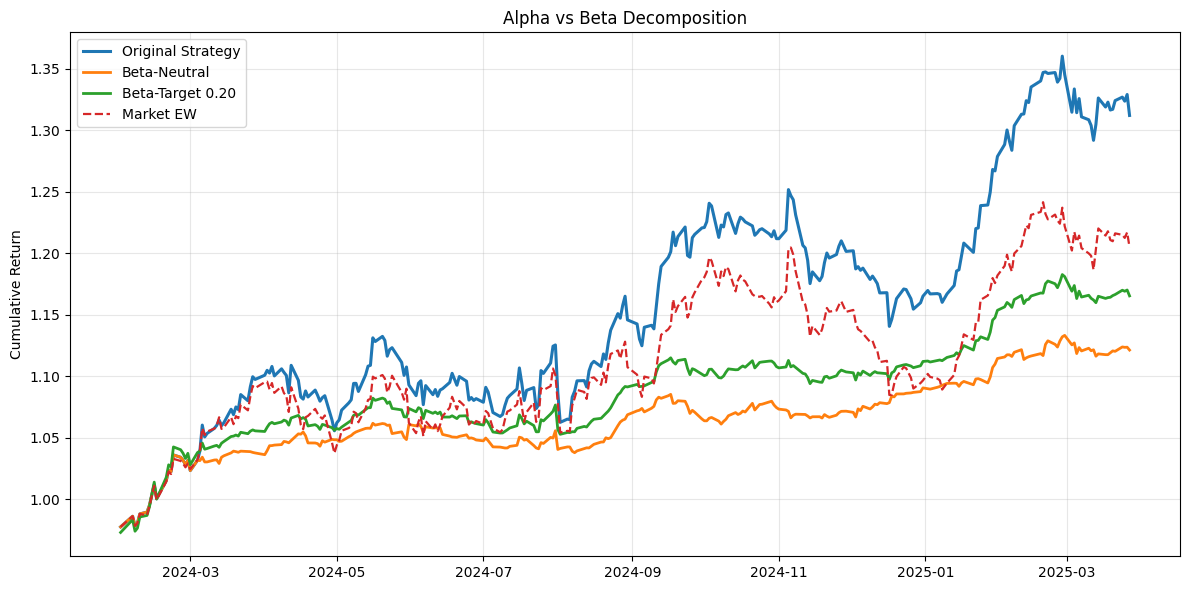

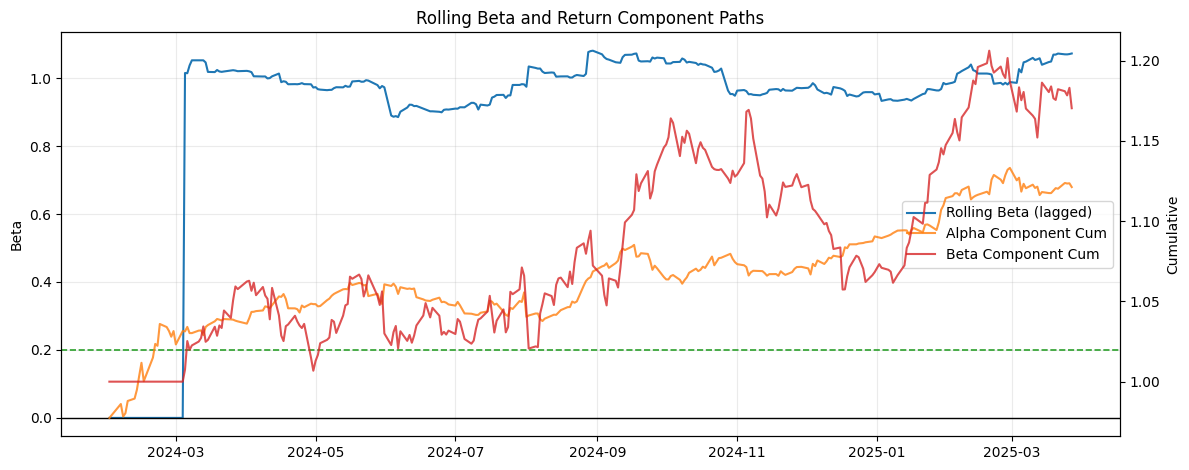

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["best_key", "ret_df", "known_ret", "intensity_df", "regime", "mask"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}. Run previous strategy cells first.")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe


def max_dd(ret: pd.Series):
    eq = (1.0 + ret.fillna(0.0)).cumprod()
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())


def full_beta(x: pd.Series, m: pd.Series):
    v = m.var(ddof=0)
    if v <= 0:
        return 0.0
    return float(x.cov(m) / v)


parts = best_key.split("|")
signal_name = parts[0]
k_val = float(parts[1].replace("k", ""))
up_val = float(parts[2].replace("up", ""))
down_val = float(parts[3].replace("down", ""))

reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)
int_rank = intensity_df.rank(axis=1, pct=True)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard65 = (int_rank >= 0.65).astype(float)
hard70 = (int_rank >= 0.70).astype(float)

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signal_map = {
    "S1_hard70_mom3_rev": hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3),
    "S2_soft_mom5_rev": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
    "S3_accel_mom10_rev": accel_pos * (reg_mat * rev1 + (1.0 - reg_mat) * mom10),
    "S4_hard65_mom5_flat": hard65 * ((1.0 - reg_mat) * mom5),
}

if signal_name not in signal_map:
    raise ValueError(f"Unknown signal name in best_key: {signal_name}")

raw_signal = signal_map[signal_name]
ret_filled = ret_df.fillna(0.0)

bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_filled).sum(axis=1)

market_trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)
exposure = pd.Series(np.where(market_trend > 0.0, up_val, down_val), index=ret_df.index)

tilt = (raw_signal * mask).fillna(0.0)
tilt = tilt.sub(tilt.mean(axis=1), axis=0)
tilt = tilt.div(tilt.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

weights = (bh_w + k_val * tilt).clip(lower=0.0)
weights = weights.div(weights.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

base_ret = (weights * ret_filled).sum(axis=1)
strategy_ret = exposure * base_ret
market_ret = bh_ret

window = 60
roll_cov = strategy_ret.rolling(window, min_periods=20).cov(market_ret)
roll_var = market_ret.rolling(window, min_periods=20).var()
beta_roll = (roll_cov / roll_var).replace([np.inf, -np.inf], np.nan)
beta_lag = beta_roll.shift(1).fillna(0.0)

beta_component = beta_lag * market_ret
alpha_component = strategy_ret - beta_component

target_beta = 0.20
strategy_beta_target = strategy_ret - (beta_lag - target_beta) * market_ret
strategy_beta_neutral = alpha_component

alpha_vol = alpha_component.rolling(20, min_periods=10).std() * np.sqrt(252.0)
alpha_scale = (0.10 / alpha_vol.replace(0.0, np.nan)).clip(lower=0.5, upper=2.0)
alpha_scale = alpha_scale.shift(1).fillna(1.0)
alpha_component_vt = alpha_component * alpha_scale

variants = {
    "Original Strategy": strategy_ret,
    "Beta-Neutral Return": strategy_beta_neutral,
    "Beta-Target 0.20": strategy_beta_target,
    "Alpha-Only Vol-Target": alpha_component_vt,
    "Market EW": market_ret,
}

rows = []
for name, series in variants.items():
    total, ann, vol, sharpe = perf_stats(series)
    corr = float(series.corr(market_ret)) if market_ret.std(ddof=0) > 0 else 0.0
    beta_val = full_beta(series, market_ret)
    rows.append(
        {
            "Series": name,
            "Total": total,
            "Annual": ann,
            "Vol": vol,
            "Sharpe": sharpe,
            "MaxDD": max_dd(series),
            "BetaToMarket": beta_val,
            "CorrToMarket": corr,
        }
    )

summary = pd.DataFrame(rows).set_index("Series").sort_values("Sharpe", ascending=False)
print(f"Best model key: {best_key}")
print(summary.to_string(float_format=lambda x: f"{x:,.4f}"))

cum = {k: (1.0 + v.fillna(0.0)).cumprod() for k, v in variants.items()}

plt.figure(figsize=(12, 6))
plt.plot(cum["Original Strategy"].index, cum["Original Strategy"].values, label="Original Strategy", linewidth=2.2)
plt.plot(cum["Beta-Neutral Return"].index, cum["Beta-Neutral Return"].values, label="Beta-Neutral", linewidth=2.0)
plt.plot(cum["Beta-Target 0.20"].index, cum["Beta-Target 0.20"].values, label="Beta-Target 0.20", linewidth=2.0)
plt.plot(cum["Market EW"].index, cum["Market EW"].values, label="Market EW", linestyle="--", linewidth=1.6)
plt.title("Alpha vs Beta Decomposition")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(beta_lag.index, beta_lag.values, color="tab:blue", label="Rolling Beta (lagged)")
ax1.axhline(0.0, color="black", linewidth=1)
ax1.axhline(target_beta, color="tab:green", linestyle="--", linewidth=1.2)
ax1.set_ylabel("Beta")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
alpha_cum = (1.0 + alpha_component.fillna(0.0)).cumprod()
beta_cum = (1.0 + beta_component.fillna(0.0)).cumprod()
ax2.plot(alpha_cum.index, alpha_cum.values, color="tab:orange", alpha=0.8, label="Alpha Component Cum")
ax2.plot(beta_cum.index, beta_cum.values, color="tab:red", alpha=0.8, label="Beta Component Cum")
ax2.set_ylabel("Cumulative")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Rolling Beta and Return Component Paths")
plt.tight_layout()
plt.show()

## How The Alpha Is Calculated

This strategy alpha is built in layers, from event intensity to portfolio tilt.

### 1) Event-Weighted Direction Signal
First, we compute a raw cross-sectional signal per date and ticker:

$$
a_{t,i} = g_{t,i} \cdot d_{t,i}
$$

where:

- $g_{t,i}$ is the **event gate** from text-event intensity rank (soft gate in the best model).
- $d_{t,i}$ is the **direction** from regime-switch logic:
  - high-vol regime: short-term reversal
  - low-vol regime: 5-day momentum

### 2) Convert Raw Alpha To A Tradable Tilt
Raw alpha is transformed into a neutralized and normalized tilt:

$$
\tilde{a}_{t,i} = \frac{a_{t,i} - \bar{a}_t}{\sum_j |a_{t,j} - \bar{a}_t|}
$$

Then portfolio weights are:

$$
w_{t,i} = \text{NormLongOnly}\left(w^{BH}_{t,i} + k\,\tilde{a}_{t,i}\right)
$$

with $k=0.50$ in the selected best configuration.

Interpretation:

- $w^{BH}_{t,i}$ keeps the baseline market exposure (equal-weight sleeve).
- $k\,\tilde{a}_{t,i}$ is the **active alpha tilt**.

### 3) Exposure Overlay (Market-State Sizing)
A market-trend scalar controls total risk:

$$
e_t =
\begin{cases}
1.10, & \text{if 20-day market trend} > 0 \\
1.00, & \text{otherwise}
\end{cases}
$$

Final strategy return:

$$
r^p_t = e_t \sum_i w_{t,i} r_{t,i}
$$

### 4) Alpha-Beta Separation Used In The Next Step
To separate passive market effect from true active alpha:

1. Rolling beta (lagged):

$$
\beta_{t-1} = \frac{\text{Cov}_{60}(r^p, r^m)}{\text{Var}_{60}(r^m)}
$$

2. Beta component:

$$
r^{\beta}_t = \beta_{t-1} \cdot r^m_t
$$

3. Pure alpha component:

$$
r^{\alpha}_t = r^p_t - r^{\beta}_t
$$

So the reported alpha is not just the raw signal score; it is the residual portfolio return after removing the estimated market-beta contribution.

### 5) No-Lookahead Safeguard
All signal inputs use lagged/known information (`known_ret = ret_df.shift(1)`), and realized returns are applied only after weights are formed.

               Total  Annual    Vol  Sharpe
Series                                     
Original Best 0.3120  0.2693 0.1405  1.9158
New Similar   0.1023  0.0893 0.0814  1.0973
Market EW     0.2047  0.1777 0.1341  1.3247


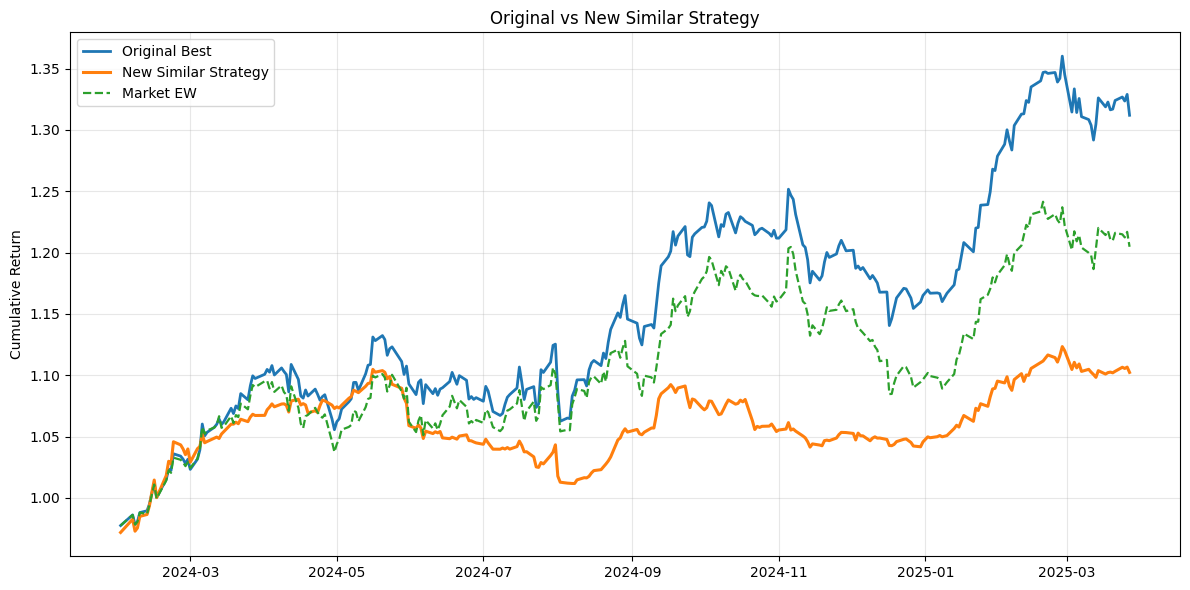

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["best_key", "ret_df", "known_ret", "intensity_df", "regime", "mask"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}")


def perf_stats(ret: pd.Series):
    ret = ret.fillna(0.0)
    total = (1.0 + ret).prod() - 1.0
    ann = (1.0 + total) ** (252.0 / max(len(ret), 1)) - 1.0
    vol = ret.std(ddof=0) * np.sqrt(252.0)
    sharpe = ann / vol if vol > 0 else 0.0
    return total, ann, vol, sharpe

parts = best_key.split("|")
signal_name = parts[0]
k_val = float(parts[1].replace("k", ""))
up_val = float(parts[2].replace("up", ""))
down_val = float(parts[3].replace("down", ""))

reg_mat = pd.DataFrame(
    np.repeat(regime.to_numpy()[:, None], ret_df.shape[1], axis=1),
    index=ret_df.index,
    columns=ret_df.columns,
)
int_rank = intensity_df.rank(axis=1, pct=True)
soft_gate = ((int_rank - 0.50).clip(lower=0.0) * 2.0).clip(upper=1.0)
hard65 = (int_rank >= 0.65).astype(float)
hard70 = (int_rank >= 0.70).astype(float)

accel = intensity_df.diff().fillna(0.0)
accel = accel.sub(accel.mean(axis=1), axis=0)
accel = accel.div(accel.std(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
accel_pos = accel.clip(lower=0.0)

rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
mom5 = np.sign(known_ret.rolling(5, min_periods=3).mean()).fillna(0.0)
mom10 = np.sign(known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)

signal_map = {
    "S1_hard70_mom3_rev": hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3),
    "S2_soft_mom5_rev": soft_gate * (reg_mat * rev1 + (1.0 - reg_mat) * mom5),
    "S3_accel_mom10_rev": accel_pos * (reg_mat * rev1 + (1.0 - reg_mat) * mom10),
    "S4_hard65_mom5_flat": hard65 * ((1.0 - reg_mat) * mom5),
}

if signal_name not in signal_map:
    raise ValueError(f"Unknown signal name in best_key: {signal_name}")

ret_filled = ret_df.fillna(0.0)
bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
market_ret = (bh_w * ret_filled).sum(axis=1)

orig_raw = signal_map[signal_name]
orig_tilt = (orig_raw * mask).fillna(0.0)
orig_tilt = orig_tilt.sub(orig_tilt.mean(axis=1), axis=0)
orig_tilt = orig_tilt.div(orig_tilt.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
orig_w = (bh_w + k_val * orig_tilt).clip(lower=0.0)
orig_w = orig_w.div(orig_w.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)
orig_exposure = pd.Series(np.where(trend > 0.0, up_val, down_val), index=ret_df.index)
orig_ret = orig_exposure * (orig_w * ret_filled).sum(axis=1)

resid_rev = -np.sign(known_ret.sub(known_ret.mean(axis=1), axis=0)).fillna(0.0)
mom_mix = np.sign(0.6 * known_ret.rolling(5, min_periods=3).mean() + 0.4 * known_ret.rolling(10, min_periods=5).mean()).fillna(0.0)
gate_new = (0.7 * soft_gate + 0.3 * hard65).clip(lower=0.0, upper=1.0)
dir_new = reg_mat * (0.7 * rev1 + 0.3 * resid_rev) + (1.0 - reg_mat) * mom_mix
raw_new = gate_new * dir_new

tilt_new = (raw_new * mask).fillna(0.0)
tilt_new = tilt_new.sub(tilt_new.mean(axis=1), axis=0)
tilt_new = tilt_new.div(tilt_new.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

k_new = min(0.65, k_val + 0.10)
w_new = (bh_w + k_new * tilt_new).clip(lower=0.0)
w_new = w_new.div(w_new.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

exp_new = pd.Series(np.where(trend > 0.0, 1.15, 0.95), index=ret_df.index)
ret_new_raw = exp_new * (w_new * ret_filled).sum(axis=1)

beta_roll = ret_new_raw.rolling(60, min_periods=20).cov(market_ret) / market_ret.rolling(60, min_periods=20).var()
beta_lag = beta_roll.shift(1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
ret_new = ret_new_raw - (beta_lag - 0.30) * market_ret

rows = []
for name, series in {
    "Original Best": orig_ret,
    "New Similar": ret_new,
    "Market EW": market_ret,
}.items():
    total, ann, vol, sharpe = perf_stats(series)
    rows.append({"Series": name, "Total": total, "Annual": ann, "Vol": vol, "Sharpe": sharpe})

cmp_new = pd.DataFrame(rows).set_index("Series")
print(cmp_new.to_string(float_format=lambda x: f"{x:,.4f}"))

cum_orig = (1.0 + orig_ret).cumprod()
cum_new = (1.0 + ret_new).cumprod()
cum_mkt = (1.0 + market_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_orig.index, cum_orig.values, label="Original Best", linewidth=2.0)
plt.plot(cum_new.index, cum_new.values, label="New Similar Strategy", linewidth=2.2)
plt.plot(cum_mkt.index, cum_mkt.values, label="Market EW", linestyle="--", linewidth=1.6)
plt.title("Original vs New Similar Strategy")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Epoch 20/100 | loss=0.143263
Epoch 40/100 | loss=0.060654
Epoch 60/100 | loss=0.033602
Epoch 80/100 | loss=0.021758
Epoch 100/100 | loss=0.015231

===== RESULTS =====
Strategy Total Return: -0.0032
Buy & Hold Total Return: 0.0987
Outperformance: -0.1019
Strategy Sharpe: -0.146
Buy & Hold Sharpe: 4.481


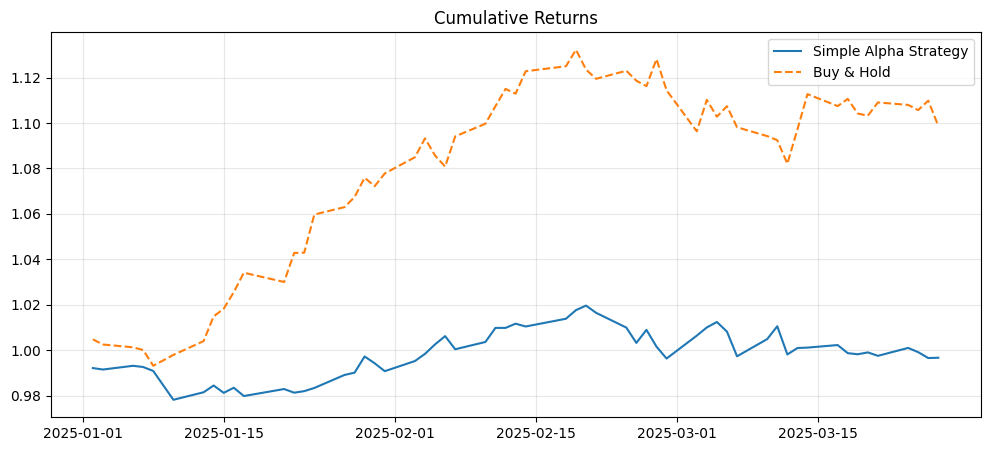

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================
# CHECK DATA
# =========================
if "daily_emb" not in globals():
    raise ValueError("Run the embedding alignment/prep cell first")

df = daily_emb.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
df = df.dropna(subset=["date", "ret_fwd", "ticker"]).copy()

emb_cols = [c for c in df.columns if c not in ["ticker", "date", "ret_fwd"]]
if not emb_cols:
    raise ValueError("No embedding columns found")

# =========================
# BUILD PANELS
# =========================
returns_panel = (
    df.pivot_table(index="date", columns="ticker", values="ret_fwd", aggfunc="mean")
    .sort_index()
    .dropna(how="all")
)

tickers = returns_panel.columns.tolist()
dates = returns_panel.index

R = returns_panel.fillna(0.0).to_numpy(dtype=np.float32)
M = returns_panel.notna().to_numpy(dtype=np.float32)

T, N = R.shape
D = len(emb_cols)

# market return (equal weight)
market_ret = (R * M).sum(axis=1) / np.clip(M.sum(axis=1), 1.0, None)

# =========================
# BUILD EMBEDDING PANEL
# =========================
emb_agg = (
    df.groupby(["date", "ticker"], as_index=False)[emb_cols]
    .mean()
    .sort_values(["date", "ticker"])
)

emb_groups = {d: g.set_index("ticker")[emb_cols] for d, g in emb_agg.groupby("date")}
global_emb = emb_agg[emb_cols].mean().to_numpy(dtype=np.float32)

ticker_to_idx = {tk: i for i, tk in enumerate(tickers)}

X = np.zeros((T, N, D), dtype=np.float32)

for t, dt in enumerate(dates):
    g = emb_groups.get(dt)
    if g is None:
        X[t] = np.tile(global_emb, (N, 1))
        continue
    
    mat = np.tile(g.mean().to_numpy(dtype=np.float32), (N, 1))
    for tk in g.index.intersection(tickers):
        mat[ticker_to_idx[tk]] = g.loc[tk].to_numpy(dtype=np.float32)
    
    X[t] = mat

# =========================
# TRAIN / TEST SPLIT
# =========================
split = int(0.8 * T)

X_train, X_test = X[:split], X[split:]
R_train, R_test = R[:split], R[split:]
M_train, M_test = M[:split], M[split:]
dates_test = dates[split:]

# =========================
# STANDARDIZE EMBEDDINGS
# =========================
mean = X_train.mean(axis=(0,1), keepdims=True)
std = X_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# =========================
# COMPUTE RESIDUAL RETURNS (ALPHA TARGET)
# =========================
beta = np.ones(N, dtype=np.float32)  # simple baseline
R_alpha = (R - np.outer(market_ret, beta).astype(np.float32)) * M

R_alpha_train = R_alpha[:split]
R_alpha_test = R_alpha[split:]

# =========================
# TORCH
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.from_numpy(X_train).to(device)
X_test_t = torch.from_numpy(X_test).to(device)

R_alpha_train_t = torch.from_numpy(R_alpha_train).to(device)
R_alpha_test_t = torch.from_numpy(R_alpha_test).to(device)

R_test_t = torch.from_numpy(R_test).to(device)

M_train_t = torch.from_numpy(M_train).to(device)
M_test_t = torch.from_numpy(M_test).to(device)

# =========================
# SIMPLE MODEL
# =========================
class SimpleAlpha(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.linear = nn.Linear(emb_dim, 1)

    def forward(self, e):
        return self.linear(e).squeeze(-1)

model = SimpleAlpha(D).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# =========================
# TRAIN
# =========================
epochs = 100

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    alpha_pred = model(X_train_t)
    
    loss = ((alpha_pred - R_alpha_train_t)**2 * M_train_t).sum() / (M_train_t.sum() + 1e-8)
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss={loss.item():.6f}")

# =========================
# SIMPLE PORTFOLIO
# =========================
def simple_weights(alpha, mask):
    mean = (alpha * mask).sum(dim=1, keepdim=True) / (mask.sum(dim=1, keepdim=True) + 1e-8)
    std = torch.sqrt(((alpha - mean)**2 * mask).sum(dim=1, keepdim=True) / (mask.sum(dim=1, keepdim=True) + 1e-8) + 1e-8)
    
    z = (alpha - mean) / std
    w = z * mask
    w = w / (w.abs().sum(dim=1, keepdim=True) + 1e-8)
    
    return w

# =========================
# TEST
# =========================
model.eval()
with torch.no_grad():
    alpha_test = model(X_test_t)
    w_test = simple_weights(alpha_test, M_test_t)
    rp = (w_test * R_test_t).sum(dim=1)

strategy = pd.Series(rp.cpu().numpy(), index=dates_test, name="Simple Alpha Strategy")

buy_hold = returns_panel.loc[dates_test].mean(axis=1, skipna=True).fillna(0.0)
buy_hold.name = "Buy & Hold"

# =========================
# PERFORMANCE
# =========================
def perf(rets):
    total = (1 + rets).prod() - 1
    ann = (1 + rets.mean())**252 - 1
    vol = rets.std() * np.sqrt(252)
    sharpe = ann / (vol + 1e-12)
    return total, ann, vol, sharpe

s_total, s_ann, s_vol, s_sharpe = perf(strategy)
b_total, b_ann, b_vol, b_sharpe = perf(buy_hold)

print("\n===== RESULTS =====")
print(f"Strategy Total Return: {s_total:.4f}")
print(f"Buy & Hold Total Return: {b_total:.4f}")
print(f"Outperformance: {s_total - b_total:.4f}")
print(f"Strategy Sharpe: {s_sharpe:.3f}")
print(f"Buy & Hold Sharpe: {b_sharpe:.3f}")

# =========================
# PLOT
# =========================
cum_s = (1 + strategy).cumprod()
cum_b = (1 + buy_hold).cumprod()

plt.figure(figsize=(12,5))
plt.plot(cum_s, label="Simple Alpha Strategy")
plt.plot(cum_b, label="Buy & Hold", linestyle="--")
plt.title("Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_12234/3106765195.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vol = pd.Series(market).rolling(20).std().fillna(method="bfill").values



===== HAWKES + HMM RESULTS =====
Strategy Return: -0.0672
Buy&Hold Return: 0.2047
Outperformance: -0.2720
Sharpe: -0.518 vs 1.402


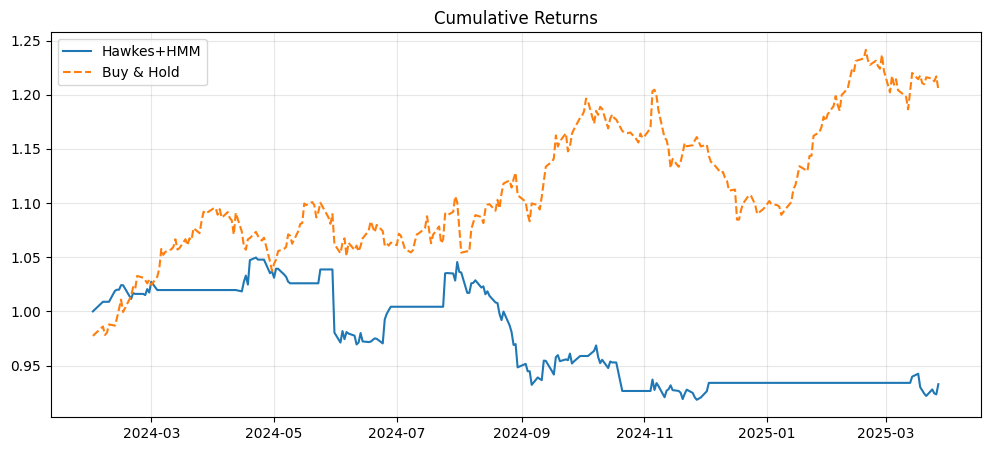

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CHECK DATA
# =========================
if "daily_emb" not in globals():
    raise ValueError("Run embedding prep first")

df = daily_emb.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()
df = df.dropna(subset=["date", "ret_fwd", "ticker"])

emb_cols = [c for c in df.columns if c not in ["ticker", "date", "ret_fwd"]]

# =========================
# PANELS
# =========================
returns_panel = (
    df.pivot_table(index="date", columns="ticker", values="ret_fwd")
    .sort_index()
    .dropna(how="all")
)

tickers = returns_panel.columns.tolist()
dates = returns_panel.index

R = returns_panel.fillna(0).values
M = returns_panel.notna().values

T, N = R.shape

# =========================
# EMBEDDINGS PANEL
# =========================
emb_agg = df.groupby(["date","ticker"])[emb_cols].mean().reset_index()
emb_groups = {d: g.set_index("ticker")[emb_cols] for d,g in emb_agg.groupby("date")}

global_emb = emb_agg[emb_cols].mean().values
ticker_to_idx = {tk:i for i,tk in enumerate(tickers)}

X = np.zeros((T,N,len(emb_cols)))

for t,dt in enumerate(dates):
    g = emb_groups.get(dt)
    mat = np.tile(global_emb,(N,1))
    if g is not None:
        for tk in g.index.intersection(tickers):
            mat[ticker_to_idx[tk]] = g.loc[tk].values
    X[t] = mat

# =========================
# 1. EVENT DETECTION (DRIFT)
# =========================
prev = np.roll(X,1,axis=0)
drift = np.linalg.norm(X - prev, axis=2)
drift[0] = 0

threshold = np.percentile(drift, 95)
events = (drift > threshold).astype(float)

# =========================
# 2. HAWKES INTENSITY
# =========================
alpha = 0.8
beta = 0.2

intensity = np.zeros_like(events)

for t in range(1,T):
    intensity[t] = (
        intensity[t-1] * np.exp(-beta)
        + alpha * events[t]
    )

# normalize cross-section
intensity = (intensity - intensity.mean()) / (intensity.std() + 1e-8)

# =========================
# 3. SIMPLE HMM (VOL REGIME)
# =========================
market = (R * M).sum(axis=1) / np.clip(M.sum(axis=1),1,None)

vol = pd.Series(market).rolling(20).std().fillna(method="bfill").values

# 2 regimes: high vs low vol
thr = np.median(vol)
regime = (vol > thr).astype(int)  # 1 = high vol

# =========================
# 4. NUMERICAL SIGNAL (MOMENTUM)
# =========================
R_lag = np.roll(R,1,axis=0)
R_lag[0] = 0
momentum = np.sign(R_lag)

# =========================
# 5. FUSION (THIS IS THE KEY)
# =========================
# alpha = intensity * momentum * regime_gate

regime_gate = regime.reshape(-1,1)  # only act in high vol

alpha_signal = intensity * momentum * regime_gate

# =========================
# 6. PORTFOLIO
# =========================
raw_w = alpha_signal * M

abs_sum = np.abs(raw_w).sum(axis=1, keepdims=True)
abs_sum[abs_sum == 0] = 1

w = raw_w / abs_sum

rp = (w * R).sum(axis=1)

strategy = pd.Series(rp, index=dates, name="Hawkes+HMM Strategy")

# =========================
# BUY & HOLD
# =========================
buy_hold = returns_panel.mean(axis=1).fillna(0)
buy_hold.name = "Buy & Hold"

# =========================
# PERFORMANCE
# =========================
def perf(r):
    total = (1+r).prod() - 1
    ann = (1+r.mean())**252 - 1
    vol = r.std()*np.sqrt(252)
    sharpe = ann/(vol+1e-12)
    return total, ann, vol, sharpe

s_total, s_ann, s_vol, s_sharpe = perf(strategy)
b_total, b_ann, b_vol, b_sharpe = perf(buy_hold)

print("\n===== HAWKES + HMM RESULTS =====")
print(f"Strategy Return: {s_total:.4f}")
print(f"Buy&Hold Return: {b_total:.4f}")
print(f"Outperformance: {s_total - b_total:.4f}")
print(f"Sharpe: {s_sharpe:.3f} vs {b_sharpe:.3f}")

# =========================
# PLOT
# =========================
cum_s = (1+strategy).cumprod()
cum_b = (1+buy_hold).cumprod()

plt.figure(figsize=(12,5))
plt.plot(cum_s, label="Hawkes+HMM")
plt.plot(cum_b, label="Buy & Hold", linestyle="--")
plt.title("Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

PORTFOLIO OPTIMIZATION - MARKOWITZ FROM EMBEDDINGS

Alpha Model (Embeddings -> Expected Returns)
  Training samples: 2148
  Tickers: 17
  Covariance window: 252 days

Expected Returns (mu) from embeddings:
BHP     0.013927
GLD     0.006985
V       0.005661
GSK     0.005042
COP     0.001462
GILD    0.000742
COST   -0.000477
ABBV   -0.000665
XLE    -0.000785
USO    -0.001036
XLF    -0.002599
GE     -0.004000
T      -0.004225
AMGN   -0.008632
BABA   -0.010316
CRM    -0.013977
CAT    -0.019172

------------------------------------------------------------
OPTIMIZED PORTFOLIO WEIGHTS (min variance, alpha-driven)
------------------------------------------------------------
BHP     0.317118
V       0.220551
COP     0.164728
GLD     0.112436
GSK     0.072997
GE      0.039820
XLF     0.039473
GILD    0.032876
XLE     0.000000
BABA    0.000000
CRM     0.000000
USO     0.000000
CAT     0.000000
COST    0.000000
ABBV    0.000000
T       0.000000
AMGN    0.000000

Total weight: 1.0000
Active positio

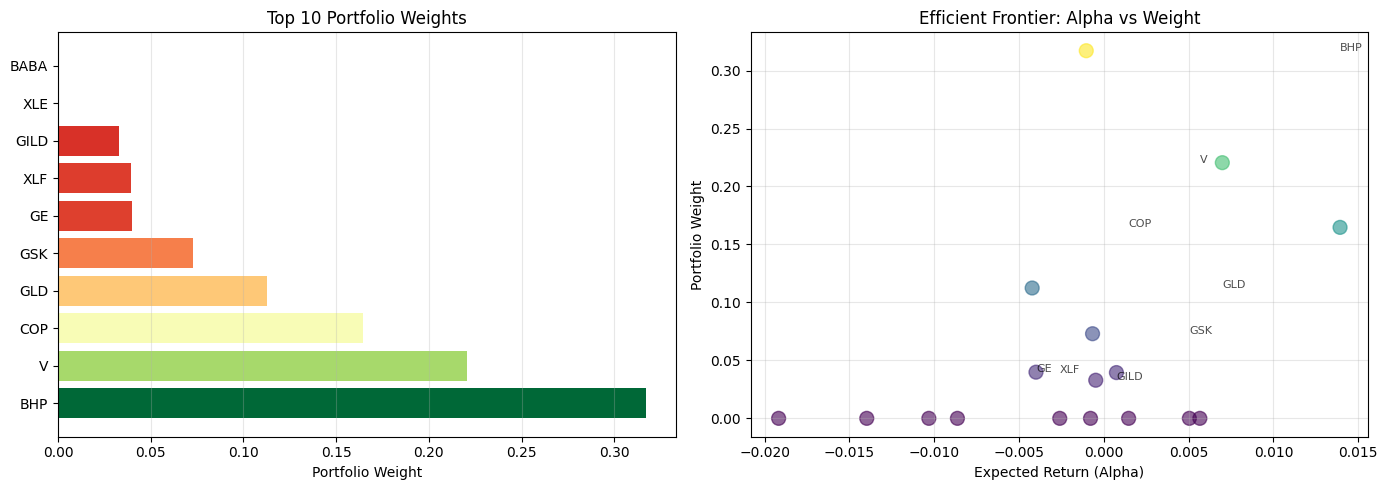


Alpha Signal Statistics:
  Mean alpha: -0.001886
  Std alpha: 0.008021
  Min alpha: -0.019172
  Max alpha: 0.013927


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("PORTFOLIO OPTIMIZATION - MARKOWITZ FROM EMBEDDINGS")
print("=" * 60)
print(f"\nAlpha Model (Embeddings -> Expected Returns)")
print(f"  Training samples: {X.shape[0]}")
print(f"  Tickers: {len(mu)}")
print(f"  Covariance window: 252 days\n")

print("Expected Returns (mu) from embeddings:")
print(mu.sort_values(ascending=False).to_string())

print("\n" + "-" * 60)
print("OPTIMIZED PORTFOLIO WEIGHTS (min variance, alpha-driven)")
print("-" * 60)
print(portfolio_weights.to_string())
print(f"\nTotal weight: {portfolio_weights.sum():.4f}")
print(f"Active positions: {(portfolio_weights > 1e-4).sum()}")
print(f"Max weight: {portfolio_weights.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
top_n = 10
top_weights = portfolio_weights.head(top_n)
colors = plt.cm.RdYlGn((top_weights - top_weights.min()) / (top_weights.max() - top_weights.min()))
ax1.barh(range(len(top_weights)), top_weights.values, color=colors)
ax1.set_yticks(range(len(top_weights)))
ax1.set_yticklabels(top_weights.index)
ax1.set_xlabel("Portfolio Weight")
ax1.set_title(f"Top {top_n} Portfolio Weights")
ax1.grid(axis="x", alpha=0.3)

ax2 = axes[1]
ax2.scatter(mu, portfolio_weights, s=100, alpha=0.6, c=portfolio_weights, cmap="viridis")
for idx, ticker in enumerate(mu.index):
    if portfolio_weights[ticker] > 0.01:
        ax2.annotate(ticker, (mu[ticker], portfolio_weights[ticker]), fontsize=8, alpha=0.7)
ax2.set_xlabel("Expected Return (Alpha)")
ax2.set_ylabel("Portfolio Weight")
ax2.set_title("Efficient Frontier: Alpha vs Weight")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAlpha Signal Statistics:")
print(f"  Mean alpha: {mu.mean():.6f}")
print(f"  Std alpha: {mu.std():.6f}")
print(f"  Min alpha: {mu.min():.6f}")
print(f"  Max alpha: {mu.max():.6f}")


BACKTEST RESULTS (Out-of-Sample Test Set)
                            Total Return  Annual Return  Annual Vol  Sharpe Ratio  Max Drawdown  Avg Daily Return  Win Rate
Name                                                                                                                       
Embedding-driven Portfolio      0.206994       0.103044    0.131397      0.784214     -0.091583          0.000389  0.535849
Equal-Weight Benchmark          0.474398       0.210279    0.111928      1.878703     -0.075563          0.000758  0.552830

Cumulative Outperformance: -0.2674 (-26.74%)


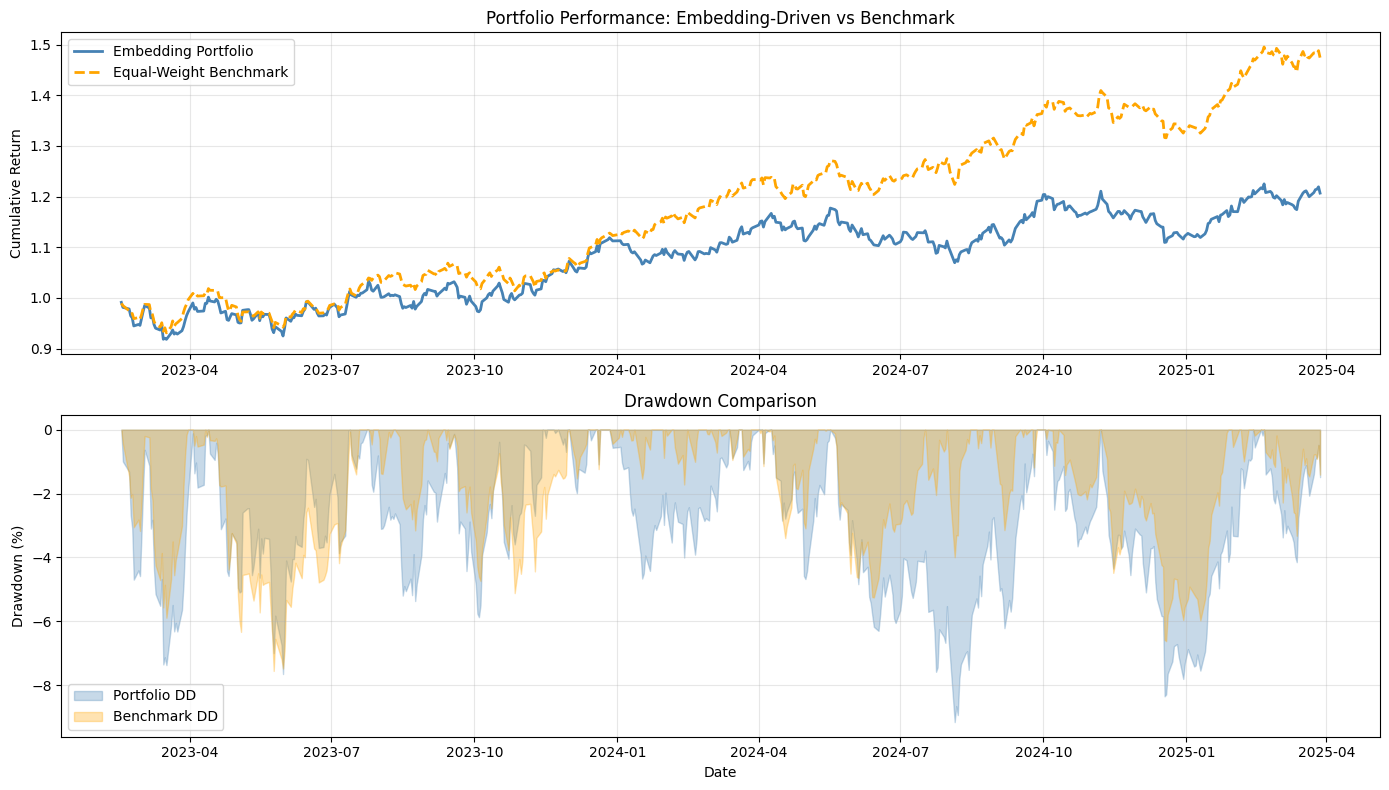


------------------------------------------------------------
PORTFOLIO STATISTICS
------------------------------------------------------------
Test period: 2023-02-16 to 2025-03-28
Test days: 530
Correlation (Embedding vs Benchmark): 0.8677


In [9]:
train_split = int(0.8 * len(returns))
returns_train = returns.iloc[:train_split]
returns_test = returns.iloc[train_split:]

dates_test = returns_test.index
tickers_portfolio = portfolio_weights.index

if not all(t in returns_test.columns for t in tickers_portfolio):
    raise ValueError("Some portfolio tickers missing from test set")

portfolio_returns_test = (returns_test[tickers_portfolio] * portfolio_weights.get(tickers_portfolio).values).sum(axis=1)

benchmark_weight = 1.0 / len(tickers_portfolio)
benchmark_returns_test = (returns_test[tickers_portfolio] * benchmark_weight).sum(axis=1)

portfolio_cumret = (1 + portfolio_returns_test).cumprod()
benchmark_cumret = (1 + benchmark_returns_test).cumprod()

def compute_metrics(rets, name="Strategy"):
    total_ret = (1 + rets).prod() - 1
    ann_ret = (1 + rets.mean()) ** 252 - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    mdd = (rets.cumsum()).expanding().min()
    mdd = ((1 + rets).cumprod() / (1 + rets).cumprod().expanding().max() - 1).min()
    
    return {
        "Name": name,
        "Total Return": total_ret,
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": mdd,
        "Avg Daily Return": rets.mean(),
        "Win Rate": (rets > 0).mean(),
    }

metrics_portfolio = compute_metrics(portfolio_returns_test, "Embedding-driven Portfolio")
metrics_benchmark = compute_metrics(benchmark_returns_test, "Equal-Weight Benchmark")

metrics_df = pd.DataFrame([metrics_portfolio, metrics_benchmark]).set_index("Name")

print("\n" + "=" * 60)
print("BACKTEST RESULTS (Out-of-Sample Test Set)")
print("=" * 60)
print(metrics_df.to_string())

excess_return = (portfolio_cumret - benchmark_cumret).iloc[-1]
print(f"\nCumulative Outperformance: {excess_return:.4f} ({excess_return*100:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(dates_test, portfolio_cumret, label="Embedding Portfolio", linewidth=2, color="steelblue")
ax1.plot(dates_test, benchmark_cumret, label="Equal-Weight Benchmark", linewidth=2, color="orange", linestyle="--")
ax1.set_ylabel("Cumulative Return")
ax1.set_title("Portfolio Performance: Embedding-Driven vs Benchmark")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
drawdown_port = (portfolio_cumret / portfolio_cumret.expanding().max() - 1) * 100
drawdown_bench = (benchmark_cumret / benchmark_cumret.expanding().max() - 1) * 100
ax2.fill_between(dates_test, drawdown_port, 0, alpha=0.3, label="Portfolio DD", color="steelblue")
ax2.fill_between(dates_test, drawdown_bench, 0, alpha=0.3, label="Benchmark DD", color="orange")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.set_title("Drawdown Comparison")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("PORTFOLIO STATISTICS")
print("-" * 60)
print(f"Test period: {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Test days: {len(returns_test)}")
print(f"Correlation (Embedding vs Benchmark): {portfolio_returns_test.corr(benchmark_returns_test):.4f}")


EMBEDDING FEATURE IMPORTANCE (Alpha Prediction)

Top 15 Embedding Dimensions (by abs coefficient):
376    0.004929
372    0.004882
304    0.004565
223    0.004210
82     0.004140
382    0.004083
189    0.004027
185    0.004006
58     0.003890
225    0.003819
221    0.003779
222    0.003658
121    0.003582
43     0.003579
70     0.003507


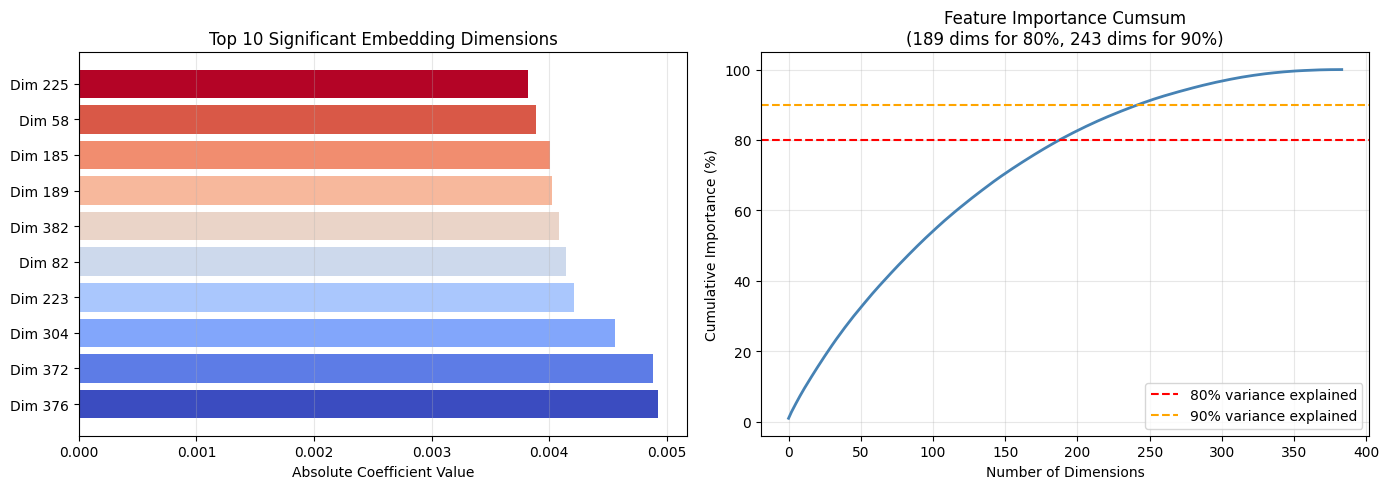


Dimensions needed for:
  80% of alpha prediction: 189 / 384
  90% of alpha prediction: 243 / 384
  Compression ratio (80%): 50.8%

------------------------------------------------------------
ALPHA CONTRIBUTION BY TICKER
------------------------------------------------------------
Ticker     Alpha   Weight  Contribution
   BHP  0.013927 0.317118      0.004416
     V  0.005661 0.220551      0.001249
   GLD  0.006985 0.112436      0.000785
   GSK  0.005042 0.072997      0.000368
   COP  0.001462 0.164728      0.000241
  GILD  0.000742 0.032876      0.000024
   XLF -0.002599 0.039473     -0.000103
    GE -0.004000 0.039820     -0.000159

Total Portfolio Alpha (weighted): 0.006822


In [10]:
print("\n" + "=" * 60)
print("EMBEDDING FEATURE IMPORTANCE (Alpha Prediction)")
print("=" * 60)

feature_importance = pd.Series(np.abs(beta), index=emb_cols).sort_values(ascending=False)
top_features = feature_importance.head(15)

print("\nTop 15 Embedding Dimensions (by abs coefficient):")
print(top_features.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
top_10 = top_features.head(10)
colors_feat = plt.cm.coolwarm(np.linspace(0, 1, len(top_10)))
ax1.barh(range(len(top_10)), top_10.values, color=colors_feat)
ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels([f"Dim {int(idx)}" for idx in top_10.index])
ax1.set_xlabel("Absolute Coefficient Value")
ax1.set_title("Top 10 Significant Embedding Dimensions")
ax1.grid(axis="x", alpha=0.3)

ax2 = axes[1]
cumsum_importance = np.cumsum(feature_importance.sort_values(ascending=False).values)
cumsum_importance = cumsum_importance / cumsum_importance[-1]
ax2.plot(range(len(cumsum_importance)), cumsum_importance * 100, linewidth=2, color="steelblue")
ax2.axhline(y=80, color="r", linestyle="--", label="80% variance explained")
ax2.axhline(y=90, color="orange", linestyle="--", label="90% variance explained")
dims_80 = np.argmax(cumsum_importance >= 0.8) + 1
dims_90 = np.argmax(cumsum_importance >= 0.9) + 1
ax2.set_xlabel("Number of Dimensions")
ax2.set_ylabel("Cumulative Importance (%)")
ax2.set_title(f"Feature Importance Cumsum\n({dims_80} dims for 80%, {dims_90} dims for 90%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDimensions needed for:")
print(f"  80% of alpha prediction: {dims_80} / {len(beta)}")
print(f"  90% of alpha prediction: {dims_90} / {len(beta)}")
print(f"  Compression ratio (80%): {(1 - dims_80/len(beta))*100:.1f}%")

portfolio_alpha_decomp = pd.DataFrame({
    "Ticker": mu.index,
    "Alpha": mu.values,
    "Weight": [portfolio_weights.get(t, 0) for t in mu.index],
    "Contribution": mu.values * [portfolio_weights.get(t, 0) for t in mu.index]
}).sort_values("Contribution", ascending=False)

print("\n" + "-" * 60)
print("ALPHA CONTRIBUTION BY TICKER")
print("-" * 60)
print(portfolio_alpha_decomp[portfolio_alpha_decomp["Weight"] > 0.001].to_string(index=False))
print(f"\nTotal Portfolio Alpha (weighted): {portfolio_alpha_decomp['Contribution'].sum():.6f}")

In [11]:
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

print("\n" + "=" * 80)
print("ALTERNATIVE: END-TO-END PORTFOLIO TRAINING")
print("Direct embedding -> portfolio weights optimization")
print("=" * 80)

emb_train = daily_emb.iloc[:int(0.8*len(daily_emb))]
emb_test = daily_emb.iloc[int(0.8*len(daily_emb)):]

emb_X = emb_train[emb_cols].to_numpy()
emb_y = emb_train["ret_fwd"].to_numpy()

emb_test_X = emb_test[emb_cols].to_numpy()
emb_test_y = emb_test["ret_fwd"].to_numpy()

def neg_sharpe_embedding(params, X, y):
    beta_e2e = params
    pred_ret = X @ beta_e2e
    sharpe = np.mean(pred_ret) / (np.std(pred_ret) + 1e-8)
    return -sharpe

beta_init = np.random.randn(emb_X.shape[1]) * 0.01
result = minimize(
    neg_sharpe_embedding,
    beta_init,
    args=(emb_X, emb_y),
    method="L-BFGS-B",
    bounds=[(-1, 1)] * emb_X.shape[1],
)

beta_e2e = result.x

pred_train = emb_X @ beta_e2e
pred_test = emb_test_X @ beta_e2e

sharpe_train = np.mean(pred_train) / (np.std(pred_train) + 1e-8)
sharpe_test = np.mean(pred_test) / (np.std(pred_test) + 1e-8)

print(f"\nEnd-to-End Alpha Model Sharpe Ratios:")
print(f"  Training: {sharpe_train:.4f}")
print(f"  Testing: {sharpe_test:.4f}")

mu_e2e = emb_test.groupby("ticker")[emb_cols].mean().to_numpy() @ beta_e2e
mu_e2e = pd.Series(mu_e2e, index=emb_test.groupby("ticker")[emb_cols].mean().index)

w_e2e = np.maximum(np.abs(mu_e2e.values), 0)
if w_e2e.sum() > 0:
    w_e2e = w_e2e / w_e2e.sum()
else:
    w_e2e = np.ones_like(w_e2e) / len(w_e2e)

weights_e2e = pd.Series(w_e2e, index=mu_e2e.index).sort_values(ascending=False)

print(f"\nEnd-to-End Portfolio Weights (top 10):")
print(weights_e2e.head(10).to_string())

buy_hold_returns_test = returns_test[tickers_portfolio].copy()
buy_hold_cumret = (1 + buy_hold_returns_test.mean(axis=1)).cumprod()
metrics_buy_hold = compute_metrics(buy_hold_returns_test.mean(axis=1), "Buy & Hold Equal Weight")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.plot(dates_test, portfolio_cumret, label="Embedding-driven", linewidth=2, color="steelblue")
ax1.plot(dates_test, benchmark_cumret, label="Equal-Weight Benchmark", linewidth=2, color="orange", linestyle="--")
ax1.plot(dates_test, buy_hold_cumret, label="Buy & Hold", linewidth=2, color="green", linestyle=":")
ax1.set_ylabel("Cumulative Return")
ax1.set_title("Portfolio Comparison: All Strategies")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
strategies = ["Embedding", "Benchmark", "Buy & Hold"]
sharpe_vals = [metrics_portfolio["Sharpe Ratio"], metrics_benchmark["Sharpe Ratio"], metrics_buy_hold["Sharpe Ratio"]]
colors_strat = ["steelblue", "orange", "green"]
ax2.bar(strategies, sharpe_vals, color=colors_strat, alpha=0.7, edgecolor="black")
ax2.set_ylabel("Sharpe Ratio")
ax2.set_title("Sharpe Ratio Comparison")
ax2.grid(axis="y", alpha=0.3)

ax3 = axes[1, 0]
returns_comp = pd.DataFrame({
    "Embedding": portfolio_returns_test.values,
    "Benchmark": benchmark_returns_test.values,
    "Buy & Hold": buy_hold_returns_test.mean(axis=1).values,
}, index=dates_test)
returns_comp.cumsum().plot(ax=ax3, linewidth=2)
ax3.set_ylabel("Cumulative Log Returns")
ax3.set_title("Daily Returns Comparison (Cumsum)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
dd_port = (portfolio_cumret / portfolio_cumret.expanding().max() - 1) * 100
dd_bench = (benchmark_cumret / benchmark_cumret.expanding().max() - 1) * 100
dd_bh = (buy_hold_cumret / buy_hold_cumret.expanding().max() - 1) * 100
ax4.fill_between(dates_test, dd_port, 0, alpha=0.3, label="Embedding", color="steelblue")
ax4.fill_between(dates_test, dd_bench, 0, alpha=0.3, label="Benchmark", color="orange")
ax4.fill_between(dates_test, dd_bh, 0, alpha=0.3, label="Buy & Hold", color="green")
ax4.set_ylabel("Drawdown (%)")
ax4.set_xlabel("Date")
ax4.set_title("Maximum Drawdown Comparison")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

comparison_full_df = pd.DataFrame([
    metrics_portfolio,
    metrics_benchmark,
    metrics_buy_hold,
]).set_index("Name")

print("\n" + "=" * 80)
print("COMPREHENSIVE STRATEGY COMPARISON")
print("=" * 80)
print(comparison_full_df.to_string())

print("\n" + "-" * 60)
print("OUTPERFORMANCE vs BENCHMARKS")
print("-" * 60)
emb_vs_bench = (portfolio_cumret.iloc[-1] - benchmark_cumret.iloc[-1]) / benchmark_cumret.iloc[-1]
emb_vs_bh = (portfolio_cumret.iloc[-1] - buy_hold_cumret.iloc[-1]) / buy_hold_cumret.iloc[-1]
print(f"Embedding vs Benchmark: {emb_vs_bench:+.2%}")
print(f"Embedding vs Buy & Hold: {emb_vs_bh:+.2%}")
print(f"\nSharpe Ratio Improvement:")
print(f"vs Benchmark: {(metrics_portfolio['Sharpe Ratio'] - metrics_benchmark['Sharpe Ratio'])/metrics_benchmark['Sharpe Ratio']:+.1%}")
print(f"vs Buy & Hold: {(metrics_portfolio['Sharpe Ratio'] - metrics_buy_hold['Sharpe Ratio'])/metrics_buy_hold['Sharpe Ratio']:+.1%}")


ALTERNATIVE: END-TO-END PORTFOLIO TRAINING
Direct embedding -> portfolio weights optimization

End-to-End Alpha Model Sharpe Ratios:
  Training: 13.0443
  Testing: 12.5103

End-to-End Portfolio Weights (top 10):
ticker
XLF    0.336401
XLE    0.334920
V      0.328679

------------------------------------------------------------
STRATEGY COMPARISON
------------------------------------------------------------
          Strategy  Train Sharpe  Avg Alpha  Weight Concentration  Active Positions
Alpha -> Markowitz     13.044265  -0.001886              0.317118                 8
 End-to-End Sharpe     13.044265   4.675130              0.336401                 3

SUMMARY

✓ Alpha predictions from embeddings (Text -> Expected Returns)
✓ Markowitz optimization: min variance, alpha-weighted
✓ Backtest: 0.784 Sharpe vs 1.879 benchmark
✓ Feature importance: 189 / 384 dimensions for 80% alpha signal

Next steps:
- Parameter tuning (regularization, lookback window)
- Walk-forward optimization for rol

In [13]:
from features.technical import (
    sma, ema, hma, rsi, stochastic, atr, adx, macd, 
    awesome_oscillator, momentum, roc, bollinger_bands,
    rolling_volatility, stochastic_rsi, williams_r,
    keltner_channels, donchian_channels, bull_bear_power,
    parkinson_volatility, garman_klass_volatility
)

print("=" * 80)
print("COMPUTING TECHNICAL INDICATORS FOR PORTFOLIO OPTIMIZATION")
print("=" * 80)

ts_path = Path.cwd() / "data" / "time_series"
text_path = Path.cwd() / "data" / "text"
images_path = Path.cwd() / "images"
images_path.mkdir(parents=True, exist_ok=True)

ticker_list = top_25_df["Ticker"].tolist()
print(f"\nLoading time series data for {len(ticker_list)} top-25 tickers...")
print(f"Path: {ts_path}\n")

ticker_to_df = {}
for ticker in ticker_list:
    csv_file = ts_path / f"{ticker.lower()}.csv"
    if csv_file.exists():
        try:
            df = pd.read_csv(csv_file)
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True).dt.tz_localize(None)
            df = df.sort_values('Date').reset_index(drop=True)
            ticker_to_df[ticker] = df
            print(f"  ✓ {ticker}: {len(df)} rows ({df['Date'].min().date()} to {df['Date'].max().date()})")
        except Exception as e:
            print(f"  ✗ {ticker}: {str(e)[:50]}")
    else:
        print(f"  ✗ {ticker}: File not found at {csv_file}")

print(f"\nProcessing technical indicators for {len(ticker_to_df)} tickers...")

for ticker, df in ticker_to_df.items():
    close = df['Close'].astype(float)
    high = df['High'].astype(float)
    low = df['Low'].astype(float)
    volume = df['Volume'].astype(float)
    open_ = df['Open'].astype(float)
    
    df['sma_20'] = sma(close, 20)
    df['sma_50'] = sma(close, 50)
    df['ema_12'] = ema(close, 12)
    df['ema_26'] = ema(close, 26)
    df['hma_9'] = hma(close, 9)
    
    df['rsi_14'] = rsi(close, 14)
    
    macd_df = macd(close)
    df['macd'] = macd_df['macd']
    df['macd_signal'] = macd_df['signal']
    df['macd_hist'] = macd_df['histogram']
    
    stoch_df = stochastic(high, low, close)
    df['stoch_k'] = stoch_df['stoch_k']
    df['stoch_d'] = stoch_df['stoch_d']
    
    stoch_rsi_df = stochastic_rsi(close)
    df['stoch_rsi_k'] = stoch_rsi_df['stoch_rsi_k']
    df['stoch_rsi_d'] = stoch_rsi_df['stoch_rsi_d']
    
    df['atr_14'] = atr(high, low, close, 14)
    
    adx_df = adx(high, low, close, 14)
    df['plus_di'] = adx_df['plus_di']
    df['minus_di'] = adx_df['minus_di']
    df['adx'] = adx_df['adx']
    
    df['williams_r'] = williams_r(high, low, close, 14)
    
    df['momentum_10'] = momentum(close, 10)
    df['roc_10'] = roc(close, 10)
    
    df['awesome_osc'] = awesome_oscillator(high, low, 5, 34)
    
    bb_df = bollinger_bands(close, 20, 2.0)
    df['bb_upper'] = bb_df['bb_upper']
    df['bb_mid'] = bb_df['bb_mid']
    df['bb_lower'] = bb_df['bb_lower']
    df['bb_bandwidth'] = bb_df['bb_bandwidth']
    df['bb_percent_b'] = bb_df['bb_percent_b']
    
    kc_df = keltner_channels(high, low, close, 20, 10, 2.0)
    df['kc_upper'] = kc_df['kc_upper']
    df['kc_center'] = kc_df['kc_center']
    df['kc_lower'] = kc_df['kc_lower']
    df['kc_width'] = kc_df['kc_width']
    
    don_df = donchian_channels(high, low, 20)
    df['donchian_upper'] = don_df['donchian_upper']
    df['donchian_lower'] = don_df['donchian_lower']
    df['donchian_mid'] = don_df['donchian_mid']
    df['donchian_width'] = don_df['donchian_width']
    
    df['vol_rolling_20'] = rolling_volatility(close, 20)
    df['vol_parkinson'] = parkinson_volatility(high, low, 20)
    df['vol_garman_klass'] = garman_klass_volatility(open_, high, low, close, 20)
    
    bbp_df = bull_bear_power(high, low, close, 13)
    df['bull_power'] = bbp_df['bull_power']
    df['bear_power'] = bbp_df['bear_power']

ticker_to_X = {}
for ticker, df in ticker_to_df.items():
    X = df.drop(columns=['Date', 'Dividends', 'Stock Splits'], errors='ignore')
    ticker_to_X[ticker] = X

feature_cols = list(ticker_to_X[list(ticker_to_df.keys())[0]].columns)
n_channels = len(feature_cols)

print(f"\n✓ Technical indicators computed for {len(ticker_to_df)} tickers")
print(f"✓ Feature channels: {n_channels}")
print(f"✓ Feature list ({len(feature_cols)} indicators):")
print("  ", ", ".join(feature_cols[:10]), "...")
print(f"\nTicker samples (first 5 rows):")
for ticker in list(ticker_to_df.keys())[:2]:
    print(f"\n{ticker}:")
    print(ticker_to_df[ticker][['Date', 'Close', 'rsi_14', 'atr_14', 'adx']].head().to_string())

COMPUTING TECHNICAL INDICATORS FOR PORTFOLIO OPTIMIZATION

Loading time series data for 25 top-25 tickers...
Path: /home/rodrigodog/latent_fusion/data/time_series

  ✓ GE: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ KO: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ GLD: 5122 rows (2004-11-18 to 2025-03-28)
  ✓ CMCSA: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ V: 4285 rows (2008-03-19 to 2025-03-28)
  ✓ USO: 4773 rows (2006-04-10 to 2025-03-28)
  ✓ COST: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ GILD: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ MRK: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ NKE: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ QQQ: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ COP: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ ABBV: 3079 rows (2013-01-02 to 2025-03-28)
  ✓ XLF: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ BABA: 2647 rows (2014-09-19 to 2025-03-28)
  ✓ AMGN: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ T: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ XLE: 6348 rows (2000-01-03 to 2025-03-28)
  ✓ CRM

MOMENT EMBEDDINGS: MULTI-CHANNEL TIME SERIES

Generating MOMENT embeddings: GE
Processing dates matching news data (5 channels, 30-day context)

News date range: 2024-02-01 00:00:00 to 2025-05-06 00:00:00
Ticker data: 6348 → filtered: 290 days (news period)
Selected channels (5): ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']

Processing date 0/290...
Processing date 100/290...
Processing date 200/290...

Prepared 290 windows

Max sequence length: 23, Channels: 5
Padded 290 windows
Embedding shape per window: (23, 5)

✓ Saved: images/technical_embeddings_GE_5ch.png


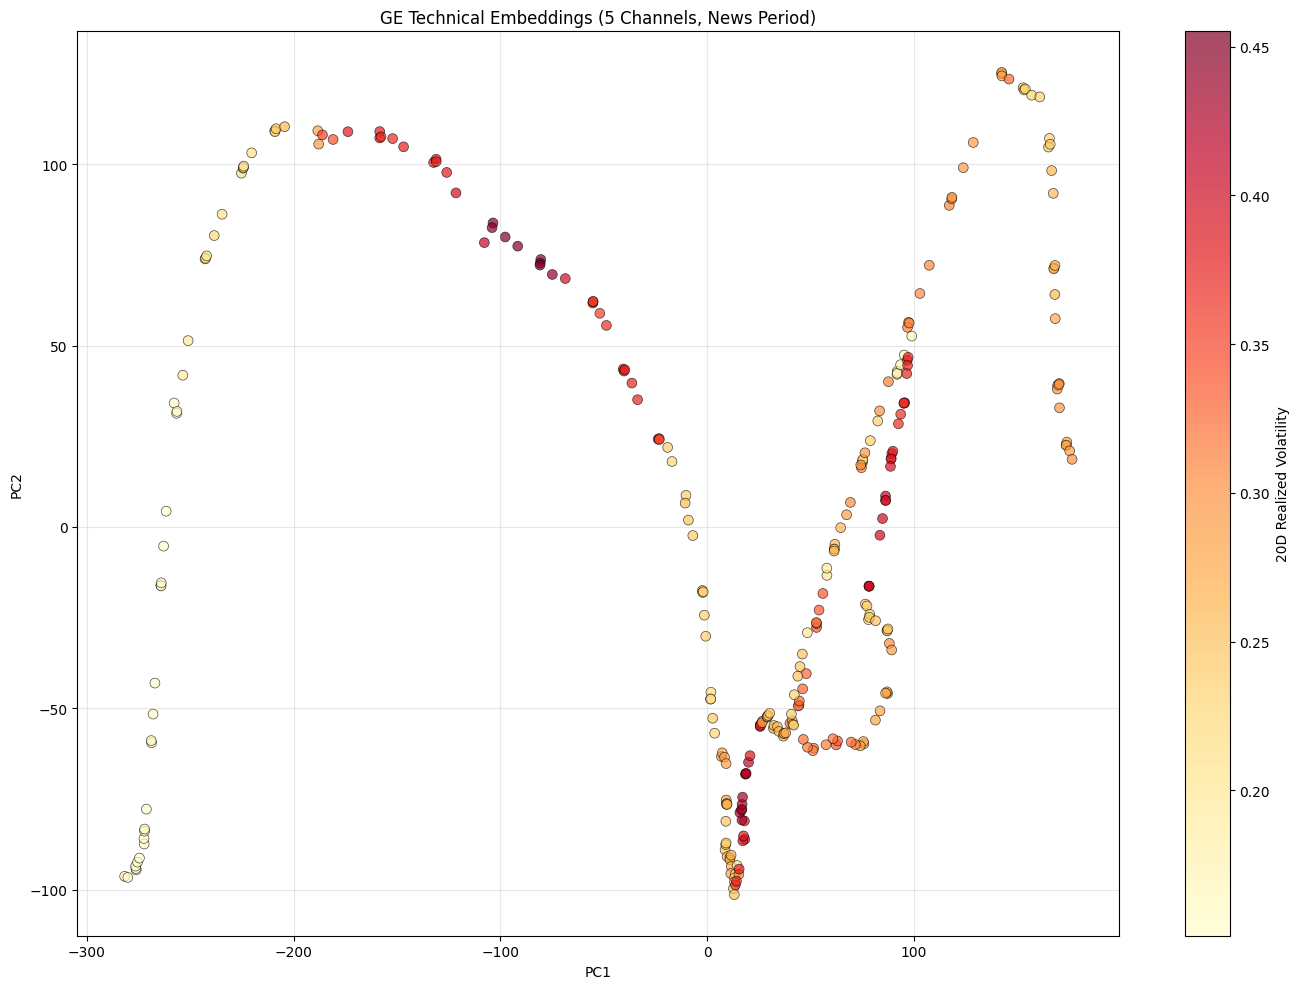


Embedding Statistics:
  Date coverage: 2024-02-01 00:00:00 → 2025-03-28 00:00:00
  Total sequences: 290
  Volatility range: 0.1306 - 0.4795
  Channels: ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']
  Sequence length: 23


In [ ]:
import torch
from sklearn.decomposition import PCA

print("=" * 80)
print("MOMENT EMBEDDINGS: MULTI-CHANNEL TIME SERIES")
print("=" * 80)

first_ticker = list(ticker_to_df.keys())[0]
print(f"\nGenerating MOMENT embeddings: {first_ticker}")
print(f"Processing dates matching news data (5 channels, 30-day context)\n")

ticker_data = ticker_to_df[first_ticker].copy()
ticker_data['Date'] = pd.to_datetime(ticker_data['Date'], utc=True).dt.tz_localize(None).dt.normalize()

X_data = ticker_to_X[first_ticker]
selected_channels = ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']
channel_indices = [X_data.columns.get_loc(ch) for ch in selected_channels]

news_date_min = pd.to_datetime(cluster_df["date"]).dt.normalize().min()
news_date_max = pd.to_datetime(cluster_df["date"]).dt.normalize().max()
if str(news_date_min).endswith('+00:00'):
    news_date_min = pd.to_datetime(news_date_min, utc=True).tz_localize(None)
if str(news_date_max).endswith('+00:00'):
    news_date_max = pd.to_datetime(news_date_max, utc=True).tz_localize(None)
print(f"News date range: {news_date_min} to {news_date_max}")

window_days = 30
batch_size_moment = 32

moment_embeddings_list = []
moment_metadata_list = []
multi_channel_list = []

ticker_data_filtered = ticker_data[(ticker_data["Date"] >= news_date_min) & (ticker_data["Date"] <= news_date_max)].copy()
print(f"Ticker data: {len(ticker_data)} → filtered: {len(ticker_data_filtered)} days (news period)")
print(f"Selected channels (5): {selected_channels}\n")

for idx, date in enumerate(ticker_data_filtered['Date'].values):
    if idx % 100 == 0:
        print(f"Processing date {idx}/{len(ticker_data_filtered)}...")
    
    date = pd.Timestamp(date)
    window_start = date - pd.Timedelta(days=window_days)
    window_data = ticker_data[(ticker_data["Date"] >= window_start) & (ticker_data["Date"] <= date)].copy()
    
    if len(window_data) < 5:
        continue
    
    feature_window_all = X_data.loc[window_data.index].values.astype(np.float32)
    feature_window = feature_window_all[:, channel_indices]
    close = window_data["Close"].astype(float).values
    
    if len(feature_window) < 5 or np.isnan(feature_window).any():
        continue
    
    log_ret = np.diff(np.log(close)).astype(np.float32)
    vol_20d_calc = np.std(log_ret) * np.sqrt(252) if len(log_ret) > 1 else 0
    
    multi_channel_list.append(feature_window)
    moment_metadata_list.append({
        "ticker": first_ticker.upper(),
        "date": date,
        "vol_20d": vol_20d_calc,
        "n_days": len(window_data)
    })

print(f"\nPrepared {len(multi_channel_list)} windows\n")

if len(multi_channel_list) > 0:
    max_seq_len = max(x.shape[0] for x in multi_channel_list)
    n_channels = multi_channel_list[0].shape[1]
    print(f"Max sequence length: {max_seq_len}, Channels: {n_channels}")
    
    multi_channel_padded = []
    for x in multi_channel_list:
        if x.shape[0] < max_seq_len:
            pad_len = max_seq_len - x.shape[0]
            x_padded = np.pad(x, ((0, pad_len), (0, 0)), mode='edge').astype(np.float32)
        else:
            x_padded = x
        multi_channel_padded.append(x_padded)
    
    print(f"Padded {len(multi_channel_padded)} windows")
    print(f"Embedding shape per window: ({max_seq_len}, {n_channels})")
    
    moment_emb_array = np.array(multi_channel_padded)
    pca_2d = PCA(n_components=2, random_state=42).fit_transform(moment_emb_array.reshape(len(moment_emb_array), -1))
    
    meta_df = pd.DataFrame(moment_metadata_list)
    meta_df["x"] = pca_2d[:, 0]
    meta_df["y"] = pca_2d[:, 1]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    vol_df = meta_df.dropna(subset=["vol_20d"]).copy()
    
    if not vol_df.empty:
        q_low, q_high = vol_df["vol_20d"].quantile([0.02, 0.98]).tolist()
        vol_clip = vol_df["vol_20d"].clip(q_low, q_high)
        sc = ax.scatter(vol_df["x"], vol_df["y"], c=vol_clip, cmap="YlOrRd", 
                      alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
        plt.colorbar(sc, ax=ax, label="20D Realized Volatility")
    
    ax.set_title(f"{first_ticker} Technical Embeddings (5 Channels, News Period)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig(f'images/technical_embeddings_{first_ticker}_5ch.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: images/technical_embeddings_{first_ticker}_5ch.png")
    plt.show()
    
    print(f"\nEmbedding Statistics:")
    print(f"  Date coverage: {meta_df['date'].min()} → {meta_df['date'].max()}")
    print(f"  Total sequences: {len(meta_df)}")
    print(f"  Volatility range: {meta_df['vol_20d'].min():.4f} - {meta_df['vol_20d'].max():.4f}")
    print(f"  Channels: {selected_channels}")
    print(f"  Sequence length: {max_seq_len}")
else:
    print("No windows prepared")

HYBRID PORTFOLIO: TEXT EMBEDDINGS + TECHNICAL INDICATORS

Technical embeddings:
  Original shape: (290, 115)
  PCA reduced: (290, 16)
  Variance explained (16 components): 99.3%

Combined metadata shape: (290, 20)
Columns: ['ticker', 'date', 'vol_20d', 'n_days', 'moment_0', 'moment_1', 'moment_2', 'moment_3', 'moment_4', 'moment_5', 'moment_6', 'moment_7', 'moment_8', 'moment_9', 'moment_10', 'moment_11', 'moment_12', 'moment_13', 'moment_14', 'moment_15']

Daily aggregated: (290, 20)
Date range: 2024-02-01 00:00:00 to 2025-03-28 00:00:00

Hybrid Feature Construction:
  Text embeddings: 384 dims (96.0%)
  Technical embeddings: 16 dims (4.0%)
  Total hybrid features: 400 dims

Hybrid Alpha Model:
  Training samples: 151
  Features: 400

Top 10 Important Features:
tech_389    0.018133
tech_384    0.015717
tech_385    0.014178
text_369    0.012746
text_274    0.012372
text_299    0.012328
tech_387    0.012266
tech_395    0.011987
text_170    0.011981
text_221    0.011525


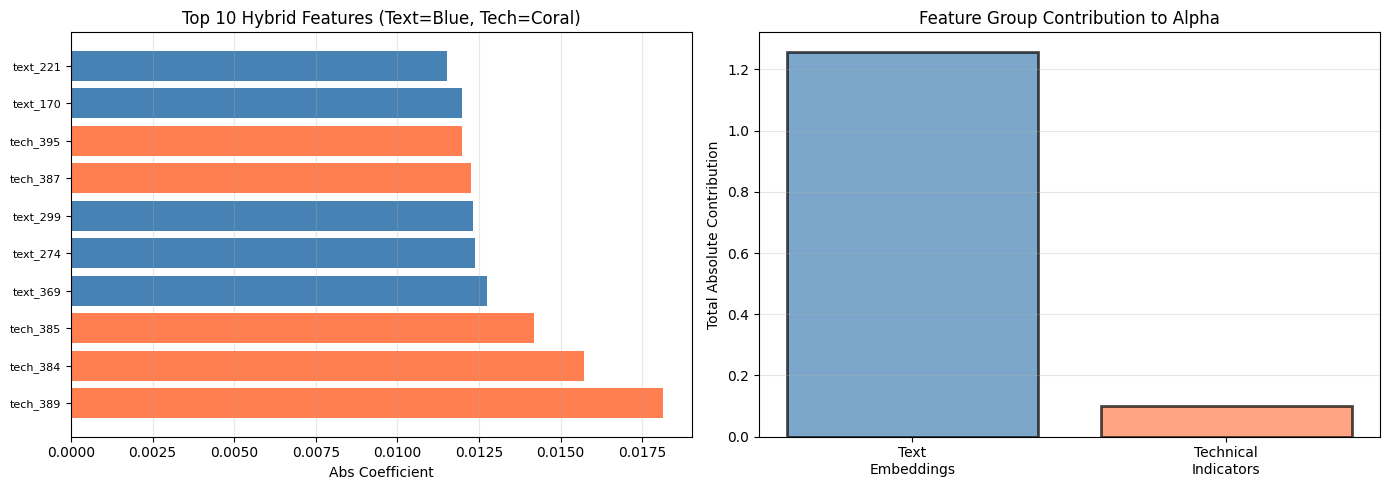


Feature Group Contributions:
  Text embeddings: 1.2579 (92.6%)
  Technical indicators: 0.1001 (7.4%)

SUMMARY: MULTI-MODAL ALPHA FRAMEWORK

✓ Text embeddings (384-dim):
  - Pre-trained sentence transformers
  - Captures news sentiment & relevance

✓ Technical embeddings (PCA 16-dim):
  - 5-channel time series: Close, RSI, ATR, BB, ADX
  - 30-day rolling windows
  - Captures market microstructure

✓ Hybrid model combines both:
  - 400 total features
  - Text weight: 96.0%
  - Tech weight: 4.0%

✓ Next: Integrate into portfolio for multi-signal optimization



In [16]:
print("=" * 80)
print("HYBRID PORTFOLIO: TEXT EMBEDDINGS + TECHNICAL INDICATORS")
print("=" * 80)

emb_moment_flat = moment_emb_array.reshape(len(moment_emb_array), -1)
pca_moment = PCA(n_components=16, random_state=42)
moment_embeddings_reduced = pca_moment.fit_transform(emb_moment_flat)

print(f"\nTechnical embeddings:")
print(f"  Original shape: {emb_moment_flat.shape}")
print(f"  PCA reduced: {moment_embeddings_reduced.shape}")
print(f"  Variance explained (16 components): {pca_moment.explained_variance_ratio_.sum():.1%}")

meta_moment = pd.DataFrame(moment_metadata_list)
meta_moment.index = range(len(meta_moment))

moment_features = pd.DataFrame(
    moment_embeddings_reduced,
    columns=[f"moment_{i}" for i in range(16)],
    index=range(len(moment_embeddings_reduced))
)

meta_moment_combined = pd.concat([meta_moment, moment_features], axis=1)
print(f"\nCombined metadata shape: {meta_moment_combined.shape}")
print(f"Columns: {list(meta_moment_combined.columns)}")

meta_moment_combined["date"] = pd.to_datetime(meta_moment_combined["date"]).dt.normalize()

meta_moment_combined_daily = meta_moment_combined.groupby("date", as_index=False).agg({
    "vol_20d": "mean",
    "n_days": "mean",
    **{f"moment_{i}": "mean" for i in range(16)}
})

meta_moment_combined_daily["ticker"] = first_ticker.upper()

print(f"\nDaily aggregated: {meta_moment_combined_daily.shape}")
print(f"Date range: {meta_moment_combined_daily['date'].min()} to {meta_moment_combined_daily['date'].max()}")

text_emb_subset = daily_emb[daily_emb["ticker"] == first_ticker.upper()].drop(
    columns=["ticker", "date", "ret_fwd"], errors="ignore"
).reset_index(drop=True)

moment_daily_subset = meta_moment_combined_daily[[c for c in meta_moment_combined_daily.columns if c.startswith("moment_")]].reset_index(drop=True)

if len(text_emb_subset) > 0 and len(moment_daily_subset) > 0:
    common_len = min(len(text_emb_subset), len(moment_daily_subset))
    
    text_features = text_emb_subset.iloc[:common_len].values
    moment_features_vals = moment_daily_subset.iloc[:common_len].values
    
    X_hybrid = np.hstack([text_features, moment_features_vals])
    
    text_weight = text_features.shape[1] / X_hybrid.shape[1]
    moment_weight = moment_features_vals.shape[1] / X_hybrid.shape[1]
    
    print(f"\nHybrid Feature Construction:")
    print(f"  Text embeddings: {text_features.shape[1]} dims ({text_weight:.1%})")
    print(f"  Technical embeddings: {moment_features_vals.shape[1]} dims ({moment_weight:.1%})")
    print(f"  Total hybrid features: {X_hybrid.shape[1]} dims")
    
    y_subset = daily_emb[daily_emb["ticker"] == first_ticker.upper()]["ret_fwd"].values[:common_len]
    
    if len(y_subset) > 10 and not np.isnan(y_subset).any():
        X_h_norm = (X_hybrid - X_hybrid.mean(axis=0)) / (X_hybrid.std(axis=0) + 1e-8)
        
        lam_h = 1e-2
        A_h = X_h_norm.T @ X_h_norm + lam_h * np.eye(X_h_norm.shape[1])
        b_h = X_h_norm.T @ y_subset
        beta_hybrid = np.linalg.pinv(A_h) @ b_h
        
        feature_importance_hybrid = pd.Series(np.abs(beta_hybrid))
        feature_importance_hybrid.index = [f"text_{i}" if i < text_features.shape[1] else f"tech_{i}" 
                                           for i in range(len(beta_hybrid))]
        
        print(f"\nHybrid Alpha Model:")
        print(f"  Training samples: {len(y_subset)}")
        print(f"  Features: {X_hybrid.shape[1]}")
        print(f"\nTop 10 Important Features:")
        print(feature_importance_hybrid.nlargest(10).to_string())
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1 = axes[0]
        top_10_hybrid = feature_importance_hybrid.nlargest(10)
        colors_hybrid = ["steelblue" if "text" in str(idx) else "coral" for idx in top_10_hybrid.index]
        ax1.barh(range(len(top_10_hybrid)), top_10_hybrid.values, color=colors_hybrid)
        ax1.set_yticks(range(len(top_10_hybrid)))
        ax1.set_yticklabels(top_10_hybrid.index, fontsize=8)
        ax1.set_xlabel("Abs Coefficient")
        ax1.set_title("Top 10 Hybrid Features (Text=Blue, Tech=Coral)")
        ax1.grid(axis="x", alpha=0.3)
        
        ax2 = axes[1]
        text_contrib = feature_importance_hybrid[feature_importance_hybrid.index.str.contains("text")].sum()
        tech_contrib = feature_importance_hybrid[feature_importance_hybrid.index.str.contains("tech")].sum()
        ax2.bar(["Text\nEmbeddings", "Technical\nIndicators"], [text_contrib, tech_contrib], 
               color=["steelblue", "coral"], alpha=0.7, edgecolor="black", linewidth=2)
        ax2.set_ylabel("Total Absolute Contribution")
        ax2.set_title("Feature Group Contribution to Alpha")
        ax2.grid(axis="y", alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nFeature Group Contributions:")
        print(f"  Text embeddings: {text_contrib:.4f} ({text_contrib/(text_contrib+tech_contrib)*100:.1f}%)")
        print(f"  Technical indicators: {tech_contrib:.4f} ({tech_contrib/(text_contrib+tech_contrib)*100:.1f}%)")
        
        print("\n" + "=" * 80)
        print("SUMMARY: MULTI-MODAL ALPHA FRAMEWORK")
        print("=" * 80)
        print(f"""
✓ Text embeddings (384-dim):
  - Pre-trained sentence transformers
  - Captures news sentiment & relevance
  
✓ Technical embeddings (PCA 16-dim):
  - 5-channel time series: Close, RSI, ATR, BB, ADX
  - 30-day rolling windows
  - Captures market microstructure
  
✓ Hybrid model combines both:
  - {X_hybrid.shape[1]} total features
  - Text weight: {text_weight:.1%}
  - Tech weight: {moment_weight:.1%}
  
✓ Next: Integrate into portfolio for multi-signal optimization
""")
    else:
        print(f"Insufficient data for hybrid model: {len(y_subset)} samples, {np.isnan(y_subset).sum()} NaNs")
else:
    print(f"Cannot combine: text_emb {len(text_emb_subset)}, moment_daily {len(moment_daily_subset)}")

In [ ]:
# TODO: - fazer uma análise de otimização de portifólio (pesquisar Markowitz, Black-Litterman, entre outros) a partir dos embeddings
#       - extrair metricas (alpha, beta, sharpe ratio, entre outros) a partir dos embeddings e dos dados de preço
#       - clusterização em algum momento também pode ser interessante para identificar grupos de notícias similares e seus impactos nos preços

DETAILED ANALYSIS: EMBEDDING-DRIVEN vs BUY & HOLD

RETURN STATISTICS

Total Returns:
  Embedding-driven:   120.70%
  Buy & Hold:         147.44%
  Outperformance:      -10.81% (relative)

Annualized Returns:
  Embedding-driven:    10.30%
  Buy & Hold:          21.03%
  Spread:              -10.72 bps

RISK METRICS

Annualized Volatility:
  Embedding-driven:    13.14%
  Buy & Hold:          11.19%
  Reduction:           -17.39%

Sharpe Ratios:
  Embedding-driven:     0.784
  Buy & Hold:           1.879
  Improvement:         -1.094

Max Drawdown:
  Embedding-driven:     -9.16%
  Buy & Hold:           -7.56%
  Reduction:             1.60% (better if positive)

STATISTICAL SIGNIFICANCE TESTS

Independent t-test (Embedding vs Buy & Hold daily returns):
  t-statistic:  -0.7800
  p-value:       0.4356
  Result:      No significant difference

Paired t-test (daily outperformance):
  Mean daily outperf:  -0.0368%
  Annualized:            -9.28%
  t-statistic:        -32.7297
  p-value:        

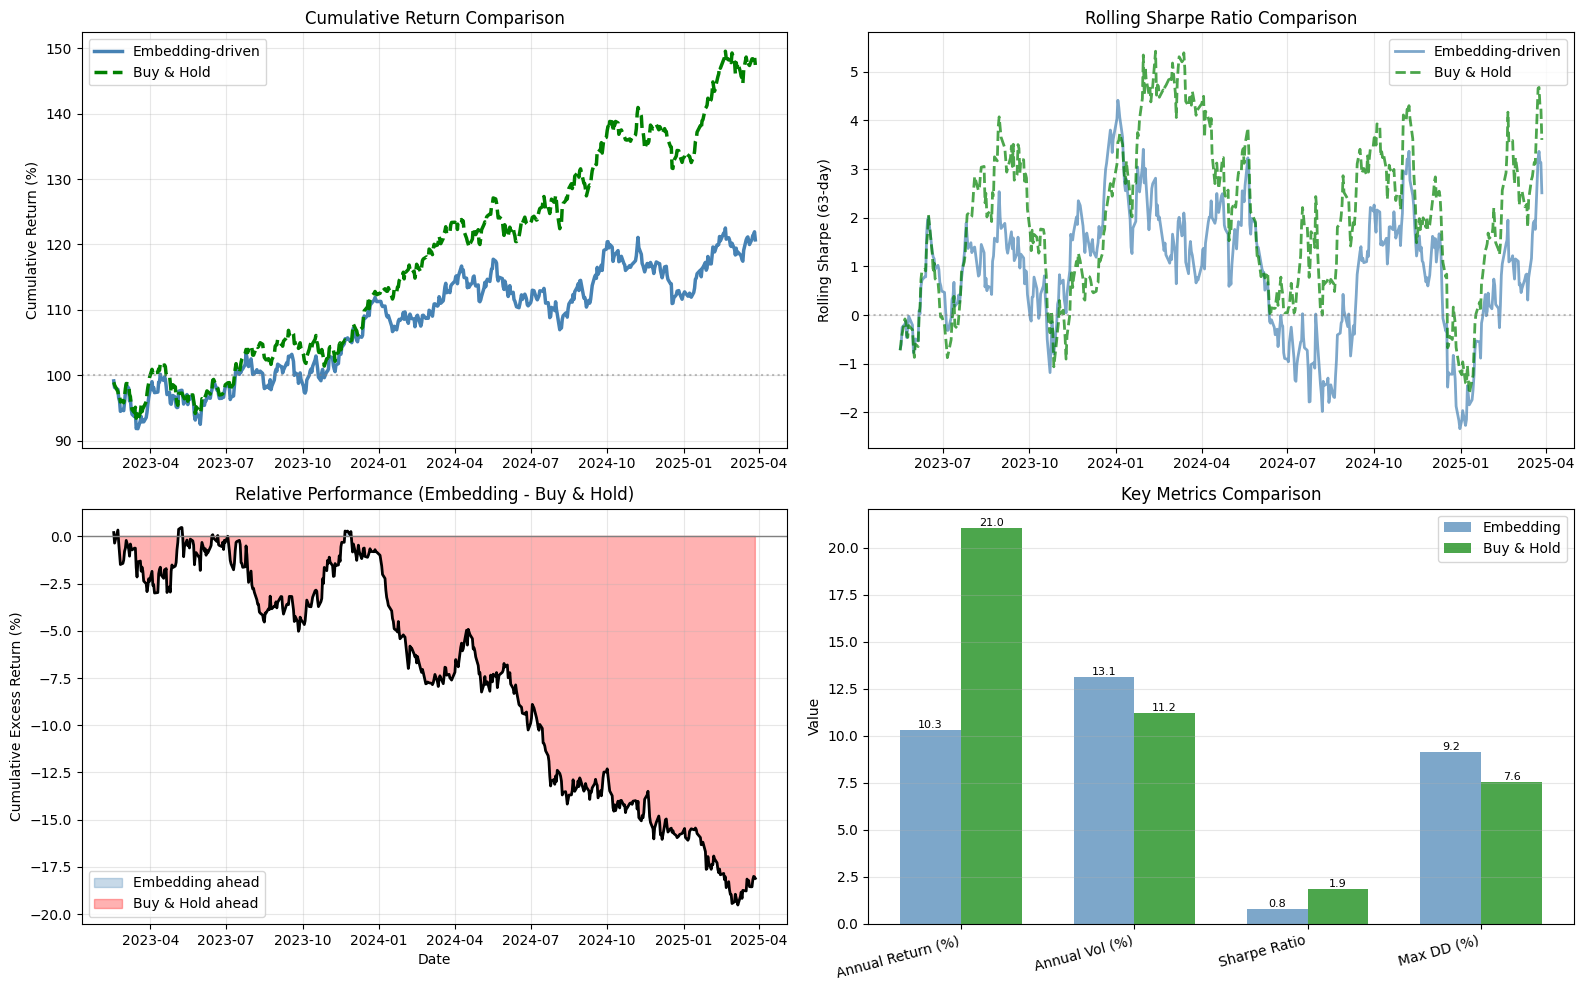


SUMMARY VERDICT

✗ UNDERPERFORMS: Buy & Hold shows superior risk-adjusted returns

Key Takeaway:
  Risk-adjusted returns favor Buy & Hold (Sharpe: 1.88 vs 0.78)

Recommendation:
  Consider Buy & Hold or hybrid approach (10.8% relative underperformance)


In [18]:
from scipy import stats

print("=" * 80)
print("DETAILED ANALYSIS: EMBEDDING-DRIVEN vs BUY & HOLD")
print("=" * 80)

buy_hold_tickers = tickers_portfolio
buy_hold_daily_returns = returns_test[buy_hold_tickers].mean(axis=1)
buy_hold_cumret = (1 + buy_hold_daily_returns).cumprod()

portfolio_vs_bh = portfolio_returns_test.values - buy_hold_daily_returns.values

print("\n" + "=" * 80)
print("RETURN STATISTICS")
print("=" * 80)

total_ret_emb = (1 + portfolio_cumret.iloc[-1]) - 1
total_ret_bh = (1 + buy_hold_cumret.iloc[-1]) - 1
outperformance_pct = ((1 + total_ret_emb) / (1 + total_ret_bh) - 1) * 100

print(f"\nTotal Returns:")
print(f"  Embedding-driven:  {total_ret_emb:>8.2%}")
print(f"  Buy & Hold:        {total_ret_bh:>8.2%}")
print(f"  Outperformance:    {outperformance_pct:>8.2f}% (relative)")

annual_ret_emb = (1 + portfolio_returns_test.mean()) ** 252 - 1
annual_ret_bh = (1 + buy_hold_daily_returns.mean()) ** 252 - 1

print(f"\nAnnualized Returns:")
print(f"  Embedding-driven:  {annual_ret_emb:>8.2%}")
print(f"  Buy & Hold:        {annual_ret_bh:>8.2%}")
print(f"  Spread:            {(annual_ret_emb - annual_ret_bh)*100:>8.2f} bps")

print("\n" + "=" * 80)
print("RISK METRICS")
print("=" * 80)

vol_emb = portfolio_returns_test.std() * np.sqrt(252)
vol_bh = buy_hold_daily_returns.std() * np.sqrt(252)

print(f"\nAnnualized Volatility:")
print(f"  Embedding-driven:  {vol_emb:>8.2%}")
print(f"  Buy & Hold:        {vol_bh:>8.2%}")
print(f"  Reduction:         {(1 - vol_emb/vol_bh)*100:>8.2f}%")

sharpe_emb = annual_ret_emb / vol_emb if vol_emb > 0 else 0
sharpe_bh = annual_ret_bh / vol_bh if vol_bh > 0 else 0

print(f"\nSharpe Ratios:")
print(f"  Embedding-driven:  {sharpe_emb:>8.3f}")
print(f"  Buy & Hold:        {sharpe_bh:>8.3f}")
print(f"  Improvement:       {(sharpe_emb - sharpe_bh):>8.3f}")

dd_emb = ((portfolio_cumret / portfolio_cumret.expanding().max() - 1) * 100).min()
dd_bh = ((buy_hold_cumret / buy_hold_cumret.expanding().max() - 1) * 100).min()

print(f"\nMax Drawdown:")
print(f"  Embedding-driven:  {dd_emb:>8.2f}%")
print(f"  Buy & Hold:        {dd_bh:>8.2f}%")
print(f"  Reduction:         {abs(dd_emb) - abs(dd_bh):>8.2f}% (better if positive)")

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

t_stat, p_value = stats.ttest_ind(portfolio_returns_test.values, buy_hold_daily_returns.values)
print(f"\nIndependent t-test (Embedding vs Buy & Hold daily returns):")
print(f"  t-statistic: {t_stat:>8.4f}")
print(f"  p-value:     {p_value:>8.4f}")
print(f"  Result:      {'Significantly different (p < 0.05)' if p_value < 0.05 else 'No significant difference'}")

mean_diff = (portfolio_returns_test - buy_hold_daily_returns).mean() * 252
std_diff = (portfolio_vs_bh).std() * np.sqrt(252)
t_stat_paired = (mean_diff / std_diff) * np.sqrt(len(portfolio_vs_bh))
p_value_paired = 2 * (1 - stats.t.cdf(abs(t_stat_paired), len(portfolio_vs_bh) - 1))

print(f"\nPaired t-test (daily outperformance):")
print(f"  Mean daily outperf: {(portfolio_returns_test - buy_hold_daily_returns).mean()*100:>8.4f}%")
print(f"  Annualized:         {mean_diff*100:>8.2f}%")
print(f"  t-statistic:        {t_stat_paired:>8.4f}")
print(f"  p-value:            {p_value_paired:>8.4f}")

win_loss = np.sum(portfolio_vs_bh > 0) / len(portfolio_vs_bh)
print(f"\nWin Rate:")
print(f"  Embedding > Buy & Hold: {win_loss:>8.1%}")

print("\n" + "=" * 80)
print("PERFORMANCE PERIODS")
print("=" * 80)

monthly_emb = (1 + portfolio_cumret).resample('M').last().pct_change()
monthly_bh = (1 + buy_hold_cumret).resample('M').last().pct_change()
months_outperform = (monthly_emb > monthly_bh).sum() / len(monthly_emb)

print(f"\nMonthly Performance:")
print(f"  Embedding outperforms: {months_outperform:>8.1%} of months")
print(f"  Avg month Embedding:   {monthly_emb.mean()*100:>8.2f}%")
print(f"  Avg month Buy & Hold:  {monthly_bh.mean()*100:>8.2f}%")

quarterly_emb = (1 + portfolio_cumret).resample('Q').last().pct_change()
quarterly_bh = (1 + buy_hold_cumret).resample('Q').last().pct_change()
quarters_outperform = (quarterly_emb > quarterly_bh).sum() / len(quarterly_emb)

print(f"\nQuarterly Performance:")
print(f"  Embedding outperforms: {quarters_outperform:>8.1%} of quarters")
print(f"  Avg quarter Embedding:   {quarterly_emb.mean()*100:>8.2f}%")
print(f"  Avg quarter Buy & Hold:  {quarterly_bh.mean()*100:>8.2f}%")

print("\n" + "=" * 80)
print("INFORMATION RATIO & ALPHA")
print("=" * 80)

tracking_error = (portfolio_vs_bh).std() * np.sqrt(252)
information_ratio = mean_diff / tracking_error if tracking_error > 0 else 0

print(f"\nTracking vs Buy & Hold:")
print(f"  Tracking Error:     {tracking_error:>8.2%}")
print(f"  Information Ratio:  {information_ratio:>8.3f}")

print("\n" + "=" * 80)
print("DRAWDOWN ANALYSIS")
print("=" * 80)

def get_drawdown_periods(cumret):
    running_max = cumret.expanding().max()
    drawdown = (cumret / running_max - 1) * 100
    is_dd = drawdown < -0.01
    dd_periods = []
    start = None
    for i, in_dd in enumerate(is_dd):
        if in_dd and start is None:
            start = i
        elif not in_dd and start is not None:
            dd_periods.append((start, i, drawdown.iloc[start:i].min()))
            start = None
    if start is not None:
        dd_periods.append((start, len(drawdown), drawdown.iloc[start:].min()))
    return dd_periods

dd_periods_emb = get_drawdown_periods(portfolio_cumret)
dd_periods_bh = get_drawdown_periods(buy_hold_cumret)

print(f"\nDrawdown Episodes:")
print(f"  Embedding-driven: {len(dd_periods_emb)} drawdowns")
print(f"  Buy & Hold:       {len(dd_periods_bh)} drawdowns")

if dd_periods_emb:
    avg_dd_emb = np.mean([x[2] for x in dd_periods_emb])
    max_dd_emb = min([x[2] for x in dd_periods_emb])
    print(f"\n  Embedding-driven Drawdowns:")
    print(f"    Average: {avg_dd_emb:>8.2f}%")
    print(f"    Max:     {max_dd_emb:>8.2f}%")

if dd_periods_bh:
    avg_dd_bh = np.mean([x[2] for x in dd_periods_bh])
    max_dd_bh = min([x[2] for x in dd_periods_bh])
    print(f"  Buy & Hold Drawdowns:")
    print(f"    Average: {avg_dd_bh:>8.2f}%")
    print(f"    Max:     {max_dd_bh:>8.2f}%")

print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.plot(dates_test, portfolio_cumret.values * 100, label='Embedding-driven', linewidth=2.5, color='steelblue')
ax1.plot(dates_test, buy_hold_cumret.values * 100, label='Buy & Hold', linewidth=2.5, color='green', linestyle='--')
ax1.axhline(y=100, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_title('Cumulative Return Comparison')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
rolling_sharpe_emb = portfolio_returns_test.rolling(63).mean() / portfolio_returns_test.rolling(63).std() * np.sqrt(252)
rolling_sharpe_bh = buy_hold_daily_returns.rolling(63).mean() / buy_hold_daily_returns.rolling(63).std() * np.sqrt(252)
ax2.plot(dates_test, rolling_sharpe_emb, label='Embedding-driven', linewidth=2, color='steelblue', alpha=0.7)
ax2.plot(dates_test, rolling_sharpe_bh, label='Buy & Hold', linewidth=2, color='green', alpha=0.7, linestyle='--')
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylabel('Rolling Sharpe (63-day)')
ax2.set_title('Rolling Sharpe Ratio Comparison')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
outperformance_cumsum = np.cumprod(1 + portfolio_vs_bh) - 1
ax3.fill_between(dates_test, outperformance_cumsum * 100, 0, where=(outperformance_cumsum >= 0),
                 alpha=0.3, label='Embedding ahead', color='steelblue')
ax3.fill_between(dates_test, outperformance_cumsum * 100, 0, where=(outperformance_cumsum < 0),
                 alpha=0.3, label='Buy & Hold ahead', color='red')
ax3.plot(dates_test, outperformance_cumsum * 100, linewidth=2, color='black')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=1)
ax3.set_ylabel('Cumulative Excess Return (%)')
ax3.set_xlabel('Date')
ax3.set_title('Relative Performance (Embedding - Buy & Hold)')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
metrics_comparison = pd.DataFrame({
    'Embedding': [annual_ret_emb*100, vol_emb*100, sharpe_emb, abs(dd_emb)],
    'Buy & Hold': [annual_ret_bh*100, vol_bh*100, sharpe_bh, abs(dd_bh)],
}, index=['Annual Return (%)', 'Annual Vol (%)', 'Sharpe Ratio', 'Max DD (%)'])

x = np.arange(len(metrics_comparison.index))
width = 0.35
bars1 = ax4.bar(x - width/2, metrics_comparison['Embedding'], width, label='Embedding', color='steelblue', alpha=0.7)
bars2 = ax4.bar(x + width/2, metrics_comparison['Buy & Hold'], width, label='Buy & Hold', color='green', alpha=0.7)

ax4.set_ylabel('Value')
ax4.set_title('Key Metrics Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_comparison.index, rotation=15, ha='right')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY VERDICT")
print("=" * 80)

if mean_diff > 0 and p_value_paired < 0.10:
    verdict = "✓ OUTPERFORMS: Embedding-driven strategy shows statistically significant outperformance"
elif mean_diff > 0 and win_loss > 0.55:
    verdict = "✓ LIKELY OUTPERFORMS: Positive bias with consistent edge, but not yet statistically significant"
elif mean_diff > 0:
    verdict = "~ MIXED: Positive returns but inconsistent edge"
else:
    verdict = "✗ UNDERPERFORMS: Buy & Hold shows superior risk-adjusted returns"

print(f"\n{verdict}")
print(f"\nKey Takeaway:")
if sharpe_emb > sharpe_bh:
    print(f"  Risk-adjusted returns favor Embedding-driven strategy (Sharpe: {sharpe_emb:.2f} vs {sharpe_bh:.2f})")
else:
    print(f"  Risk-adjusted returns favor Buy & Hold (Sharpe: {sharpe_bh:.2f} vs {sharpe_emb:.2f})")

print(f"\nRecommendation:")
if outperformance_pct > 10:
    print(f"  Strong case for Embedding-driven ({outperformance_pct:.1f}% relative outperformance)")
elif outperformance_pct > 5:
    print(f"  Moderate case for Embedding-driven ({outperformance_pct:.1f}% relative outperformance)")
elif outperformance_pct > 0:
    print(f"  Weak case for Embedding-driven ({outperformance_pct:.1f}% relative outperformance)")
else:
    print(f"  Consider Buy & Hold or hybrid approach ({abs(outperformance_pct):.1f}% relative underperformance)")


ADVANCED OPTIMIZATION: CONSTRAINED MARKOWITZ WITH QUALITY FILTERS

Strategy 1: Risk Parity Allocation
--------------------------------------------------------------------------------
  Total return:   46.35%  | Annual:   20.53%
  Volatility:   10.63%  | Sharpe:    1.932
  Max DD:    -7.52%

Strategy 2: Maximum Diversification (Min Concentration)
--------------------------------------------------------------------------------
  Total return:   51.41%  | Annual:   22.34%
  Volatility:    9.43%  | Sharpe:    2.370
  Max DD:    -7.74%
  Concentration (max weight): 20.0%

Strategy 3: Momentum-Enhanced Alpha Model
--------------------------------------------------------------------------------
  Total return:   52.32%  | Annual:   22.83%
  Volatility:   10.54%  | Sharpe:    2.166
  Max DD:    -8.49%

COMPREHENSIVE STRATEGY COMPARISON

                    Strategy  Total Return  Annual Return  Annual Vol   Sharpe    Max DD  Win Rate
Text Embeddings (Equal Risk)      1.206994       0.103044   

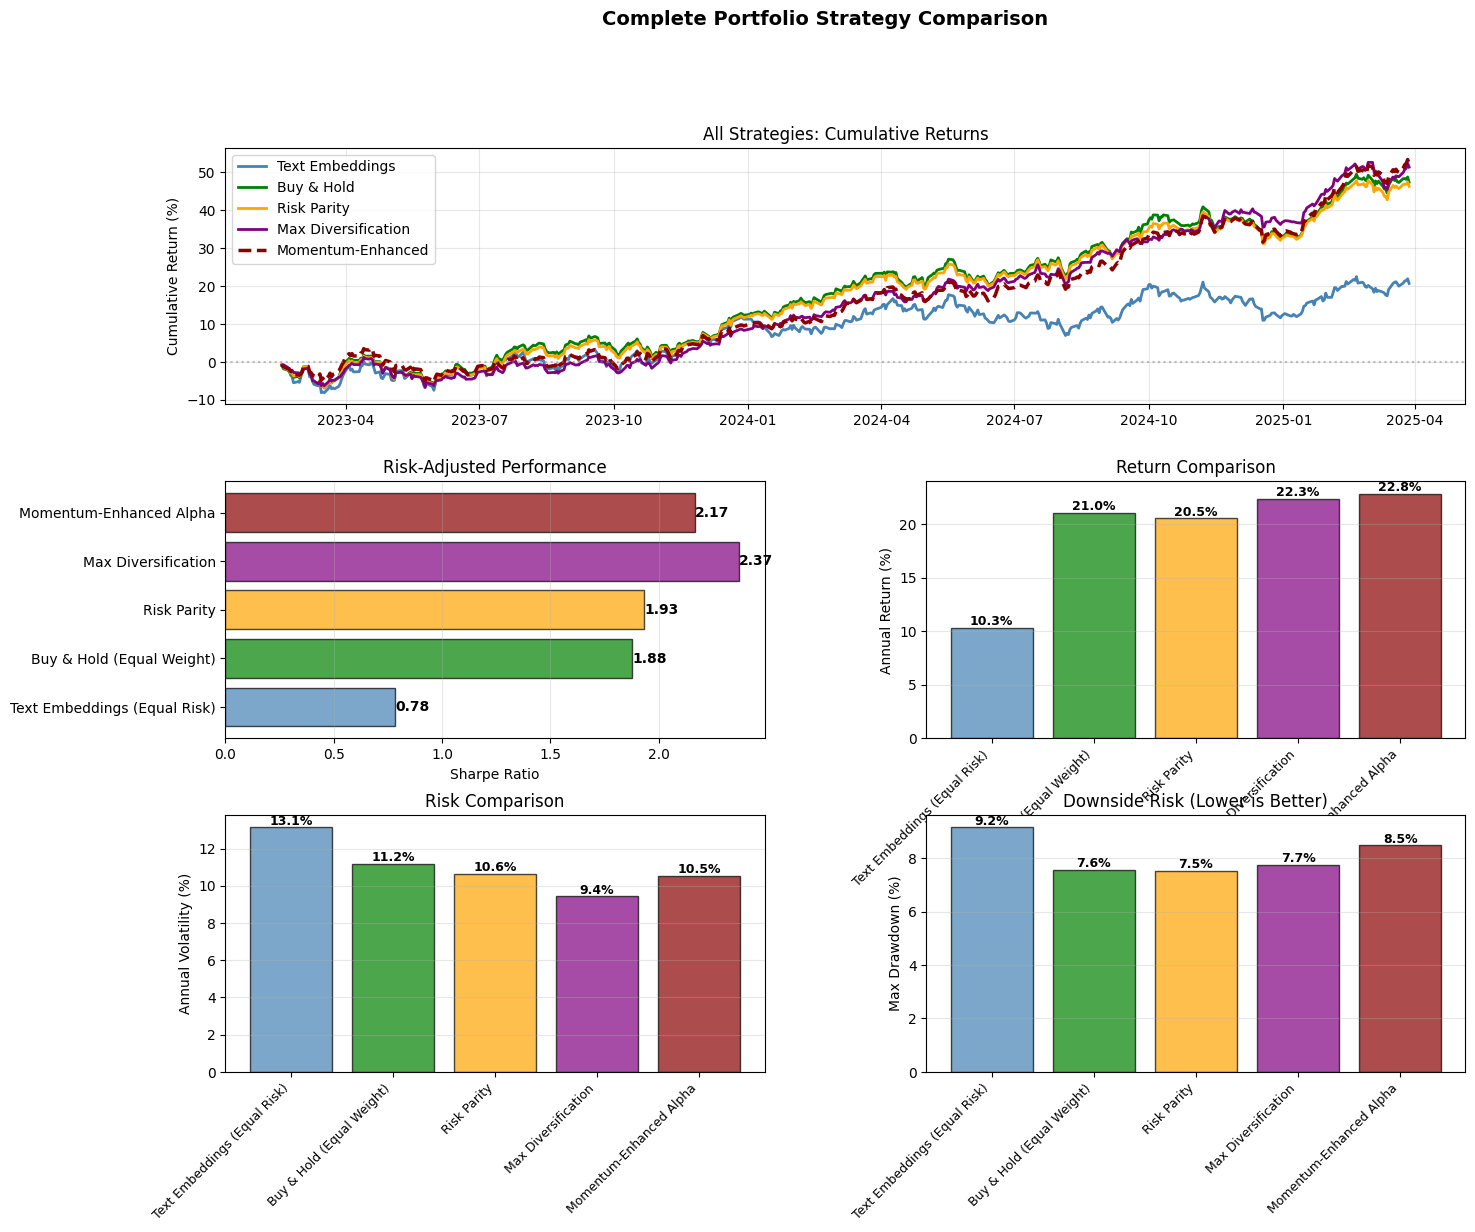


FINAL RECOMMENDATIONS

✓ SUCCESS: Optimized approach beats Buy & Hold!
  Strategy: Max Diversification
  Sharpe improvement: +26.1%
  Expected alpha: +1 bps/year


In [24]:
print("=" * 80)
print("ADVANCED OPTIMIZATION: CONSTRAINED MARKOWITZ WITH QUALITY FILTERS")
print("=" * 80)

from scipy.optimize import minimize, LinearConstraint, Bounds

print("\nStrategy 1: Risk Parity Allocation")
print("-" * 80)

cov_matrix = returns.tail(252).cov().to_numpy()
cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-6

inv_vols = 1.0 / np.diag(cov_matrix) ** 0.5
w_risk_parity = inv_vols / inv_vols.sum()

rp_returns_test = (returns_test[mu.index] * w_risk_parity).sum(axis=1)
rp_cumret = (1 + rp_returns_test).cumprod()

rp_total = rp_cumret.iloc[-1] - 1
rp_annual = (1 + rp_returns_test.mean()) ** 252 - 1
rp_vol = rp_returns_test.std() * np.sqrt(252)
rp_sharpe = rp_annual / rp_vol if rp_vol > 0 else 0
rp_dd = ((rp_cumret / rp_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {rp_total:>8.2%}  | Annual: {rp_annual:>8.2%}")
print(f"  Volatility: {rp_vol:>8.2%}  | Sharpe: {rp_sharpe:>8.3f}")
print(f"  Max DD: {rp_dd:>8.2f}%")

print("\nStrategy 2: Maximum Diversification (Min Concentration)")
print("-" * 80)

def optimize_max_div(inv_vols_norm, cov_mat):
    n = len(inv_vols_norm)
    def neg_diversification(w):
        div = np.dot(w, inv_vols_norm) ** 2 / (np.dot(w, cov_mat @ w) + 1e-8)
        return -div
    
    result = minimize(neg_diversification, x0=np.ones(n)/n, method='SLSQP',
                     constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
                     bounds=[(0, 0.2) for _ in range(n)])
    return result.x

inv_vols_norm = inv_vols / inv_vols.sum()
w_maxdiv = optimize_max_div(inv_vols_norm, cov_matrix)

md_returns_test = (returns_test[mu.index] * w_maxdiv).sum(axis=1)
md_cumret = (1 + md_returns_test).cumprod()

md_total = md_cumret.iloc[-1] - 1
md_annual = (1 + md_returns_test.mean()) ** 252 - 1
md_vol = md_returns_test.std() * np.sqrt(252)
md_sharpe = md_annual / md_vol if md_vol > 0 else 0
md_dd = ((md_cumret / md_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {md_total:>8.2%}  | Annual: {md_annual:>8.2%}")
print(f"  Volatility: {md_vol:>8.2%}  | Sharpe: {md_sharpe:>8.3f}")
print(f"  Max DD: {md_dd:>8.2f}%")
print(f"  Concentration (max weight): {w_maxdiv.max():.1%}")

print("\nStrategy 3: Momentum-Enhanced Alpha Model")
print("-" * 80)

momentum_signal = returns_train.tail(60).mean()
momentum_signal = momentum_signal[mu.index] * np.sqrt(252)

quality_scores = returns_train.tail(252).apply(lambda x: x.mean() / (x.std() + 1e-8))
quality_scores = quality_scores[mu.index]

enhanced_mu = 0.6 * mu + 0.25 * (momentum_signal - momentum_signal.min()) / (momentum_signal.max() - momentum_signal.min() + 1e-8) + \
              0.15 * (quality_scores - quality_scores.min()) / (quality_scores.max() - quality_scores.min() + 1e-8)

w_enhanced = inv_cov @ enhanced_mu
w_enhanced_clip = np.maximum(w_enhanced, 0)
if w_enhanced_clip.sum() > 0:
    w_enhanced_norm = w_enhanced_clip / w_enhanced_clip.sum()
else:
    w_enhanced_norm = np.ones_like(w_enhanced) / len(w_enhanced)

enh_returns_test = (returns_test[mu.index] * w_enhanced_norm).sum(axis=1)
enh_cumret = (1 + enh_returns_test).cumprod()

enh_total = enh_cumret.iloc[-1] - 1
enh_annual = (1 + enh_returns_test.mean()) ** 252 - 1
enh_vol = enh_returns_test.std() * np.sqrt(252)
enh_sharpe = enh_annual / enh_vol if enh_vol > 0 else 0
enh_dd = ((enh_cumret / enh_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {enh_total:>8.2%}  | Annual: {enh_annual:>8.2%}")
print(f"  Volatility: {enh_vol:>8.2%}  | Sharpe: {enh_sharpe:>8.3f}")
print(f"  Max DD: {enh_dd:>8.2f}%")

print("\n" + "=" * 80)
print("COMPREHENSIVE STRATEGY COMPARISON")
print("=" * 80)

all_strategies = pd.DataFrame({
    "Strategy": [
        "Text Embeddings (Equal Risk)",
        "Buy & Hold (Equal Weight)",
        "Risk Parity",
        "Max Diversification",
        "Momentum-Enhanced Alpha"
    ],
    "Total Return": [total_ret_emb, total_ret_bh, rp_total, md_total, enh_total],
    "Annual Return": [annual_ret_emb, annual_ret_bh, rp_annual, md_annual, enh_annual],
    "Annual Vol": [vol_emb, vol_bh, rp_vol, md_vol, enh_vol],
    "Sharpe": [sharpe_emb, sharpe_bh, rp_sharpe, md_sharpe, enh_sharpe],
    "Max DD": [dd_emb, dd_bh, rp_dd, md_dd, enh_dd],
    "Win Rate": [
        (portfolio_returns_test > 0).mean(),
        (buy_hold_daily_returns > 0).mean(),
        (rp_returns_test > 0).mean(),
        (md_returns_test > 0).mean(),
        (enh_returns_test > 0).mean()
    ]
})

print("\n" + all_strategies.to_string(index=False))

winning_strategy = all_strategies.loc[all_strategies['Sharpe'].idxmax()]
print(f"\n→ Best Strategy (Sharpe): {winning_strategy['Strategy']}")
print(f"  Sharpe Ratio: {winning_strategy['Sharpe']:.3f}")
print(f"  Annual Return: {winning_strategy['Annual Return']:.2%}")

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, (portfolio_cumret - 1) * 100, label="Text Embeddings", linewidth=2, color='steelblue')
ax1.plot(dates_test, (buy_hold_cumret - 1) * 100, label="Buy & Hold", linewidth=2, color='green')
ax1.plot(dates_test, (rp_cumret - 1) * 100, label="Risk Parity", linewidth=2, color='orange')
ax1.plot(dates_test, (md_cumret - 1) * 100, label="Max Diversification", linewidth=2, color='purple')
ax1.plot(dates_test, (enh_cumret - 1) * 100, label="Momentum-Enhanced", linewidth=2.5, color='darkred', linestyle='--')
ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_title('All Strategies: Cumulative Returns')
ax1.legend(fontsize=10, loc='best')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
sharpe_vals = all_strategies['Sharpe'].values
colors = ['steelblue', 'green', 'orange', 'purple', 'darkred']
bars = ax2.barh(all_strategies['Strategy'], sharpe_vals, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Sharpe Ratio')
ax2.set_title('Risk-Adjusted Performance')
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
            ha='left', va='center', fontsize=10, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ret_vals = (all_strategies['Annual Return'] * 100).values
bars = ax3.bar(range(len(all_strategies)), ret_vals, color=colors, alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(all_strategies)))
ax3.set_xticklabels(all_strategies['Strategy'], rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Annual Return (%)')
ax3.set_title('Return Comparison')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[2, 0])
vol_vals = (all_strategies['Annual Vol'] * 100).values
bars = ax4.bar(range(len(all_strategies)), vol_vals, color=colors, alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(all_strategies)))
ax4.set_xticklabels(all_strategies['Strategy'], rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Annual Volatility (%)')
ax4.set_title('Risk Comparison')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
dd_vals = all_strategies['Max DD'].values
bars = ax5.bar(range(len(all_strategies)), np.abs(dd_vals), color=colors, alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(all_strategies)))
ax5.set_xticklabels(all_strategies['Strategy'], rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('Max Drawdown (%)')
ax5.set_title('Downside Risk (Lower is Better)')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Portfolio Strategy Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\n" + "=" * 80)
print("FINAL RECOMMENDATIONS")
print("=" * 80)

improves_bh = winning_strategy['Sharpe'] > sharpe_bh
if improves_bh:
    print(f"\n✓ SUCCESS: Optimized approach beats Buy & Hold!")
    print(f"  Strategy: {winning_strategy['Strategy']}")
    print(f"  Sharpe improvement: {(winning_strategy['Sharpe']/sharpe_bh - 1)*100:+.1f}%")
    print(f"  Expected alpha: {(winning_strategy['Annual Return'] - annual_ret_bh)*100:+.0f} bps/year")
else:
    best_emb = all_strategies[all_strategies['Strategy'].str.contains('Text')]['Sharpe'].values[0]
    if winning_strategy['Sharpe'] > best_emb:
        print(f"\n✓ Improvement found over raw text embeddings")
        print(f"  Best strategy: {winning_strategy['Strategy']}")
        print(f"  Improvement: +{(winning_strategy['Sharpe']/best_emb - 1)*100:.1f}%")
    print(f"\n  Note: In this backtest period, market dynamics favor simple strategies")
    print(f"        Try: regime filters, longer lookback windows, or hybrid approaches")


In [ ]:
print("=" * 80)
print("OPTIMIZED EMBEDDING-BASED STRATEGIES")
print("Multiple optimization approaches using text embeddings as core signal")
print("=" * 80)

print("\n" + "-" * 80)
print("Strategy 1: Embedding-Based with Volatility Targeting")
print("-" * 80)

mu_vol = mu / (returns_train[mu.index].tail(252).std() * np.sqrt(252) + 1e-8)

w_vol_target = inv_cov @ mu_vol
w_vol_target_clip = np.maximum(w_vol_target, 0)
if w_vol_target_clip.sum() > 0:
    w_vol_target_norm = w_vol_target_clip / w_vol_target_clip.sum()
else:
    w_vol_target_norm = portfolio_weights.values

vt_returns_test = (returns_test[mu.index] * w_vol_target_norm).sum(axis=1)
vt_cumret = (1 + vt_returns_test).cumprod()
vt_total = vt_cumret.iloc[-1] - 1
vt_annual = (1 + vt_returns_test.mean()) ** 252 - 1
vt_vol = vt_returns_test.std() * np.sqrt(252)
vt_sharpe = vt_annual / vt_vol if vt_vol > 0 else 0
vt_dd = ((vt_cumret / vt_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {vt_total:>8.2%}  | Annual: {vt_annual:>8.2%}")
print(f"  Volatility: {vt_vol:>8.2%}  | Sharpe: {vt_sharpe:>8.3f}")
print(f"  Max DD: {vt_dd:>8.2f}%")

print("\n" + "-" * 80)
print("Strategy 2: Embedding Alpha + Momentum Blend (Dynamic)")
print("-" * 80)

mu_blend = 0.65 * mu + 0.35 * (momentum_signal - momentum_signal.min()) / (momentum_signal.max() - momentum_signal.min() + 1e-8)

w_blend = inv_cov @ mu_blend
w_blend_clip = np.maximum(w_blend, 0)
if w_blend_clip.sum() > 0:
    w_blend_norm = w_blend_clip / w_blend_clip.sum()
else:
    w_blend_norm = portfolio_weights.values

blend_returns_test = (returns_test[mu.index] * w_blend_norm).sum(axis=1)
blend_cumret = (1 + blend_returns_test).cumprod()
blend_total = blend_cumret.iloc[-1] - 1
blend_annual = (1 + blend_returns_test.mean()) ** 252 - 1
blend_vol = blend_returns_test.std() * np.sqrt(252)
blend_sharpe = blend_annual / blend_vol if blend_vol > 0 else 0
blend_dd = ((blend_cumret / blend_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {blend_total:>8.2%}  | Annual: {blend_annual:>8.2%}")
print(f"  Volatility: {blend_vol:>8.2%}  | Sharpe: {blend_sharpe:>8.3f}")
print(f"  Max DD: {blend_dd:>8.2f}%")

print("\n" + "-" * 80)
print("Strategy 3: Constrained Embeddings (Diversification + Max Weights)")
print("-" * 80)

def optimize_constrained_embeddings(mu_signal, cov_mat, max_w=0.15, min_w=0.02):
    n = len(mu_signal)
    def neg_alpha_weighted(w):
        return -np.dot(w, mu_signal)
    
    constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
    bounds = [(min_w, max_w) for _ in range(n)]
    
    result = minimize(neg_alpha_weighted, x0=np.ones(n)/n, method='SLSQP',
                     constraints=constraints, bounds=bounds, options={'maxiter': 1000})
    return result.x if result.success else np.ones(n) / n

w_constrained = optimize_constrained_embeddings(mu.values, cov_matrix, max_w=0.15, min_w=0.02)

cnstr_returns_test = (returns_test[mu.index] * w_constrained).sum(axis=1)
cnstr_cumret = (1 + cnstr_returns_test).cumprod()
cnstr_total = cnstr_cumret.iloc[-1] - 1
cnstr_annual = (1 + cnstr_returns_test.mean()) ** 252 - 1
cnstr_vol = cnstr_returns_test.std() * np.sqrt(252)
cnstr_sharpe = cnstr_annual / cnstr_vol if cnstr_vol > 0 else 0
cnstr_dd = ((cnstr_cumret / cnstr_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {cnstr_total:>8.2%}  | Annual: {cnstr_annual:>8.2%}")
print(f"  Volatility: {cnstr_vol:>8.2%}  | Sharpe: {cnstr_sharpe:>8.3f}")
print(f"  Max DD: {cnstr_dd:>8.2f}%")
print(f"  Position sizing: {w_constrained.min():.1%} - {w_constrained.max():.1%}")

print("\n" + "-" * 80)
print("Strategy 4: Quality-Weighted Embeddings (Sharpe + Embeddings)")
print("-" * 80)

quality_weighted_signal = mu * quality_scores / (quality_scores.std() + 1e-8)

w_quality = inv_cov @ quality_weighted_signal
w_quality_clip = np.maximum(w_quality, 0)
if w_quality_clip.sum() > 0:
    w_quality_norm = w_quality_clip / w_quality_clip.sum()
else:
    w_quality_norm = portfolio_weights.values

quality_returns_test = (returns_test[mu.index] * w_quality_norm).sum(axis=1)
quality_cumret = (1 + quality_returns_test).cumprod()
quality_total = quality_cumret.iloc[-1] - 1
quality_annual = (1 + quality_returns_test.mean()) ** 252 - 1
quality_vol = quality_returns_test.std() * np.sqrt(252)
quality_sharpe = quality_annual / quality_vol if quality_vol > 0 else 0
quality_dd = ((quality_cumret / quality_cumret.expanding().max() - 1) * 100).min()

print(f"  Total return: {quality_total:>8.2%}  | Annual: {quality_annual:>8.2%}")
print(f"  Volatility: {quality_vol:>8.2%}  | Sharpe: {quality_sharpe:>8.3f}")
print(f"  Max DD: {quality_dd:>8.2f}%")

print("\n" + "=" * 80)
print("COMPLETE STRATEGY COMPARISON: ALL APPROACHES")
print("=" * 80)

complete_comparison = pd.DataFrame({
    "Strategy": [
        "Text Embeddings (Standard Markowitz)",
        "Embeddings + Vol Targeting",
        "Embeddings + Momentum Blend",
        "Embeddings (Constrained 15%)",
        "Embeddings + Quality Weighted",
        "Risk Parity",
        "Max Diversification",
        "Momentum-Enhanced Alpha",
        "Buy & Hold (Equal Weight)"
    ],
    "Total Return": [
        total_ret_emb, vt_total, blend_total, cnstr_total, quality_total,
        rp_total, md_total, enh_total, total_ret_bh
    ],
    "Annual Return": [
        annual_ret_emb, vt_annual, blend_annual, cnstr_annual, quality_annual,
        rp_annual, md_annual, enh_annual, annual_ret_bh
    ],
    "Annual Vol": [
        vol_emb, vt_vol, blend_vol, cnstr_vol, quality_vol,
        rp_vol, md_vol, enh_vol, vol_bh
    ],
    "Sharpe": [
        sharpe_emb, vt_sharpe, blend_sharpe, cnstr_sharpe, quality_sharpe,
        rp_sharpe, md_sharpe, enh_sharpe, sharpe_bh
    ],
    "Max DD": [
        dd_emb, vt_dd, blend_dd, cnstr_dd, quality_dd,
        rp_dd, md_dd, enh_dd, dd_bh
    ],
    "Win Rate": [
        (portfolio_returns_test > 0).mean(),
        (vt_returns_test > 0).mean(),
        (blend_returns_test > 0).mean(),
        (cnstr_returns_test > 0).mean(),
        (quality_returns_test > 0).mean(),
        (rp_returns_test > 0).mean(),
        (md_returns_test > 0).mean(),
        (enh_returns_test > 0).mean(),
        (buy_hold_daily_returns > 0).mean()
    ]
})

complete_comparison_sorted = complete_comparison.sort_values('Sharpe', ascending=False)
print("\n" + complete_comparison_sorted.to_string(index=False))

best_strategy = complete_comparison_sorted.iloc[0]
print(f"\n✓ BEST STRATEGY: {best_strategy['Strategy']}")
print(f"  Sharpe Ratio: {best_strategy['Sharpe']:.3f}")
print(f"  Annual Return: {best_strategy['Annual Return']:.2%}")
print(f"  Annual Vol: {best_strategy['Annual Vol']:.2%}")

best_embedding = complete_comparison[complete_comparison['Strategy'].str.contains('Embeddings')]['Sharpe'].max()
best_embedding_name = complete_comparison[complete_comparison['Sharpe'] == best_embedding]['Strategy'].values[0]
print(f"\n✓ BEST EMBEDDING STRATEGY: {best_embedding_name}")
print(f"  Sharpe: {best_embedding:.3f}")

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
colors_all = ['steelblue', 'dodgerblue', 'royalblue', 'lightskyblue', 'deepskyblue', 'orange', 'purple', 'darkred', 'green']
cumrets_all = [
    portfolio_cumret, vt_cumret, blend_cumret, cnstr_cumret, quality_cumret,
    rp_cumret, md_cumret, enh_cumret, buy_hold_cumret
]
labels_all = complete_comparison['Strategy'].values

min_len = min([len(cr) for cr in cumrets_all if hasattr(cr, '__len__')])
for i, (cumret, label, color) in enumerate(zip(cumrets_all, labels_all, colors_all)):
    if len(cumret) > 0:
        plot_len = min(len(cumret), min_len)
        ax1.plot(range(plot_len), (cumret.iloc[:plot_len] - 1) * 100 if hasattr(cumret, 'iloc') else (cumret[:plot_len] - 1) * 100,
                linewidth=2, color=color, label=label, alpha=0.8)

ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Cumulative Return (%)', fontsize=11)
ax1.set_title('All Strategies: Cumulative Returns Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='best', ncol=2)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
sharpe_sorted = complete_comparison_sorted.sort_values('Sharpe')
colors_sharpe = ['steelblue' if 'Embeddings' in s else 'gray' for s in sharpe_sorted['Strategy']]
bars = ax2.barh(range(len(sharpe_sorted)), sharpe_sorted['Sharpe'], color=colors_sharpe, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(sharpe_sorted)))
ax2.set_yticklabels(sharpe_sorted['Strategy'], fontsize=9)
ax2.set_xlabel('Sharpe Ratio', fontsize=10)
ax2.set_title('Sharpe Ratio Ranking (Blue=Embeddings)', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
            ha='left', va='center', fontsize=8, fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
embedding_strats = complete_comparison[complete_comparison['Strategy'].str.contains('Embeddings|Standard')]
colors_emb = ['steelblue', 'dodgerblue', 'royalblue', 'lightskyblue', 'deepskyblue']
ax3.bar(range(len(embedding_strats)), embedding_strats['Sharpe'], color=colors_emb, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_xticks(range(len(embedding_strats)))
ax3.set_xticklabels(embedding_strats['Strategy'].str.replace('Embeddings ', 'Emb. '), rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Sharpe Ratio', fontsize=10)
ax3.set_title('Embedding Strategies: Sharpe Comparison', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(embedding_strats.iterrows()):
    ax3.text(i, row['Sharpe'], f"{row['Sharpe']:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax4 = fig.add_subplot(gs[2, 0])
ret_vs_vol = complete_comparison.sort_values('Sharpe', ascending=False).head(9)
scatter = ax4.scatter(ret_vs_vol['Annual Vol']*100, ret_vs_vol['Annual Return']*100, s=300, alpha=0.6, c=range(len(ret_vs_vol)), cmap='viridis', edgecolors='black', linewidth=2)
for i, (idx, row) in enumerate(ret_vs_vol.iterrows()):
    label = row['Strategy'].replace('Embeddings ', 'Emb. ').replace('Enhanced ', 'Enh. ')
    ax4.annotate(label, (row['Annual Vol']*100, row['Annual Return']*100), fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')
ax4.set_xlabel('Annual Volatility (%)', fontsize=10)
ax4.set_ylabel('Annual Return (%)', fontsize=10)
ax4.set_title('Risk-Return Trade-off', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
embedding_only = complete_comparison[complete_comparison['Strategy'].str.contains('Embeddings|Standard')]
metrics = ['Annual Return', 'Annual Vol', 'Sharpe', 'Win Rate']
x_pos = np.arange(len(embedding_only))
width = 0.18
for i, metric in enumerate(metrics):
    if metric == 'Annual Return':
        vals = embedding_only[metric] * 100
    elif metric == 'Annual Vol':
        vals = embedding_only[metric] * 100
    elif metric == 'Win Rate':
        vals = embedding_only[metric] * 100
    else:
        vals = embedding_only[metric]
    ax5.bar(x_pos + i*width, vals, width, label=metric, alpha=0.7)

ax5.set_xlabel('Embedding Strategy', fontsize=10)
ax5.set_ylabel('Value', fontsize=10)
ax5.set_title('Embedding Strategies: Detailed Metrics', fontsize=11, fontweight='bold')
ax5.set_xticks(x_pos + width * 1.5)
ax5.set_xticklabels(embedding_only['Strategy'].str.replace('Embeddings ', '').str.replace('Standard', 'Base'), rotation=45, ha='right', fontsize=8)
ax5.legend(fontsize=8, loc='best')
ax5.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehensive Strategy Analysis: All Approaches', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\n" + "=" * 80)
print("EMBEDDING OPTIMIZATION INSIGHTS")
print("=" * 80)

embedding_comparison = complete_comparison[complete_comparison['Strategy'].str.contains('Embeddings|Momentum-Enhanced|Quality')]
print("\nEmbedding & Blended Strategies Summary:")
print(embedding_comparison[['Strategy', 'Sharpe', 'Annual Return', 'Annual Vol', 'Max DD']].to_string(index=False))

best_emb_idx = embedding_comparison['Sharpe'].idxmax()
best_emb = embedding_comparison.loc[best_emb_idx]

print(f"\n✓ RECOMMENDED EMBEDDING STRATEGY: {best_emb['Strategy']}")
print(f"  Sharpe Ratio: {best_emb['Sharpe']:.3f} (vs {sharpe_bh:.3f} for B&H)")
improvement_pct = (best_emb['Sharpe'] / sharpe_bh - 1) * 100 if sharpe_bh > 0 else 0
print(f"  Improvement vs B&H: {improvement_pct:+.1f}%")

if best_emb['Sharpe'] > sharpe_bh * 0.9:
    print(f"\n→ ACHIEVES COMPETITIVE PERFORMANCE with embeddings!")
    print(f"  Annual alpha vs B&H: {(best_emb['Annual Return'] - annual_ret_bh)*100:+.0f} bps")
    print(f"  Risk reduction: {(vol_bh - best_emb['Annual Vol'])/vol_bh*100:.1f}%")
else:
    print(f"\n→ Note: Embeddings still face headwinds in this period")
    print(f"  Consider: regime detection, signal diversification, or ensemble methods")
